# 📓 Cas d'usage IA — Orientation et tri multimodal des demandeurs d'emploi par l'Intelligence Artificielle

**Auteur·e** : `Joelle Germanos`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT)  
**Date début** : `20/08/2026`  
**Dernière mise à jour** : `02/10/2026`


## 0. Imports & configuration

🎯 Centraliser les imports et la configuration reproductible.  
💡 `random_state=42` partout, `pd.set_option` pour l'affichage si besoin.  
⚠️ Ne pas importer en cours de notebook : tout ici.

In [4]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import shap
import joblib
import pytest

from IPython.display import display
from scipy import sparse
from scipy import sparse
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    recall_score, make_scorer
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python :", sys.version.split()[0])
print("Pandas :", pd.__version__)

Python : 3.12.10
Pandas : 2.2.2


## 0.5 Traçabilité de la session

🎯 Documenter ce qui rend l'analyse **reproductible** par toi (sur un autre poste) ou par un collègue qui reprendrait le notebook dans 3 mois.

💡 Trois choses à figer :
- la **version du dataset** (source, date d'extraction, hash si possible),
- les **versions des libs** (cf. `requirements.txt` du repo associé, ou `pip freeze`),
- le **commit Git** du repo associé au notebook.

⚠️ Sans ces 3 éléments, ton analyse n'est pas reproductible. C'est un attendu pro fort, et c'est noté en certif.

In [5]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "dataset_trajectoire_emploi"          
DATASET_SOURCE = "../data/dataset_trajectoire_emploi.csv"        # URL, chemin, ou contact si fourni par le client
DATASET_VERSION = "2026-08-14"  # date d'extraction OU version explicite

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-09-30T08:29
Python       : 3.12.10
NumPy        : 2.2.6
Pandas       : 2.2.2
Git commit   : c461791
Dataset      : dataset_trajectoire_emploi (source=../data/dataset_trajectoire_emploi.csv, version=2026-08-14)


---
## 1. Cadrage métier & problème

**Compétences** : C1 (jeux de données pour besoin métier), C2 (risques éthiques), C4 (choix modèle pertinent)

🎯 **Avant d'écrire la moindre ligne de code**, tu dois pouvoir répondre à :

- Qui est le client ? Quel est son besoin métier réel ?
- Qui sont les bénéficiaires directs et indirects de la solution ?
- Quel type de tâche IA (classification, régression, clustering, génération…) ?
- Quels critères de succès **côté métier** (pas seulement côté modèle) ?
- Quels risques éthiques, réglementaires, de biais sont pressentis ?
- Quel cadre réglementaire s'applique (RGPD, AI Act, secteur régulé) ?

⚠️ Une formulation floue du problème = un projet qui dérive. Sois précis·e.

### 1.1 Contexte client

Le client est une agence nationale de l'emploi (service public). L'optimisation des politiques publiques de l'emploi et le développement d'outils d'aide à la décision imposent la mise en place de solutions d'aiguillage rapides et fiables.   
L'enjeu métier est de classer avec précision le délai potentiel de retour à l'emploi des usagers dès le premier entretien de cadrage. L'agence souhaite en particulier identifier les situations présentant un risque d'inactivité de longue durée (plus de 12 mois) afin d'éviter de priver ces usagers d'un accompagnement renforcé indispensable. 
Le recours à l'IA est motivé par la nécessité d'assister les conseillers avec un système d'aide à la décision capable d'exploiter des données hybrides et hétérogènes (numériques, catégorielles et synthèses textuelles rédigées lors des entretiens).

### 1.2 Énoncé du problème IA

Le problème se formule comme une tâche d'apprentissage supervisé de **classification multiclasse à 3 catégories distinctes**. 

L'objectif est de prédire la classe de délai potentiel de retour à l'emploi d'un usager à partir d'un ensemble de données d'entrée hybrides comprenant des variables tabulaires (socio-professionnelles, administratives, géographiques) et du texte libre (synthèse rédigée lors du premier entretien)[

- **Variable cible** : `classe_retour_emploi`.
  - **Classe 0 (Rapide)** : Retour à l'emploi en moins de 6 mois.
  - **Classe 1 (Moyen)** : Retour à l'emploi entre 6 et 12 mois.
  - **Classe 2 (Risque)** : Risque de chômage de longue durée supérieur à 12 mois.

- **Variables explicatives** :
  - **Données tabulaires** : `age`, `niveau_diplome`, `anciennete_poste_ans`, `code_rome_vise`, `code_insee_commune`, `est_allocataire`, `nationalite_hors_ue`.
  - **Données textuelles** : `synthese_entretien` (notes rédigées par le conseiller). 

### 1.3 Bénéficiaires & impacts

- **Bénéficiaires directs** : Les **conseillers à l'emploi**, qui utilisent la solution comme un outil d'aide à la décision lors de l'entretien d'orientation.
- **Bénéficiaires indirects** :
  - Les **usagers (demandeurs d'emploi)**, réorientés de façon adaptée selon leur niveau de risque.
  - L'**agence nationale de l'emploi**, qui optimise la gestion et l'attribution de ses ressources d'accompagnement.
- **Impacts des erreurs de prédiction** :
  - **Erreur critique** : Classer à tort une situation de risque élevé (chômage de longue durée) en niveau de risque nul (retour rapide). Cela prive l'usager d'un accompagnement renforcé indispensable, générant un préjudice humain grave et un coût financier important.
  - **Erreurs secondaires** : Mal évaluer un niveau de risque sans être dans ce scénario extrême. Cela peut conduire à un mauvais ciblage des dispositifs d'orientation sans présenter la même gravité humaine et financière.
  - 
### 1.4 Critères de succès

⚠️ La cible **avant EDA** est ce que demande le client. La cible **révisée après EDA** tient compte des contraintes réelles de la donnée. Les deux doivent apparaître.

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | *[ex: réduire de X% le délai de Y]* | *[ex: -20%]* | *[à compléter après §3]* | *[ex: cible irréaliste vu le déséquilibre des classes]* |
| Modèle | *[ex: F1-score classe minoritaire]* | *[ex: ≥ 0.75]* | *[à compléter]* | … |
| Opérationnel | *[ex: temps de réponse API]* | *[ex: < 200 ms]* | *[à compléter]* | … |


| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| **Métier** | Réduction des erreurs critiques (Classe 2 prédite en Classe 0) | $0\%$ d'erreurs critiques | Minimisation maximale des erreurs critiques via ajustement des poids de classes ou des seuils de décision | Cible de $0\%$ irréaliste compte tenu du déséquilibre de la classe 2 ($18,08\%$) et du bruit stochastique dans les synthèses textuelles. |
| **Modèle** | Accuracy, F1-score macro et Matrice de confusion | Maximisation de l'Accuracy et du F1-score macro | Équilibre du F1-score macro avec focalisation prioritaire sur le Rappel (Recall) de la classe 2 | Le déséquilibre de la cible (Classe 1 : $44,5\%$, Classe 0 : $37,4\%$, Classe 2 : $18,1\%$) et les valeurs manquantes imposent de favoriser la détection de la classe minoritaire à risque. |
| **Opérationnel** | Temps de réponse de l'API (inférence en entretien) | Latence adaptée à un entretien en face-à-face | Temps de réponse API $< 500\text{ ms}$ (requête HTTP POST) | Nécessaire pour traiter les données hybrides (vectorisation du texte et encodage tabulaire comme le code INSEE) sans ralentir l'échange avec l'usager. |

### 1.5 Risques éthiques & réglementaires anticipés

*[Variables sensibles, biais possibles, RGPD, AI Act, droit sectoriel.]*

**Variables sensibles et risques de discrimination**

- **Nationalité** : la variable `nationalite_hors_ue` est susceptible d'introduire une discrimination directe ou indirecte. Son utilisation doit faire l'objet d'une justification explicite et d'une analyse d'impact. Dans une démarche de réduction des biais, son retrait et l'évaluation de son effet sur les performances du modèle doivent être documentés.

- **Âge** : la variable `age` constitue une donnée liée à un critère protégé contre les discriminations. Son utilisation peut conduire à des traitements différenciés entre groupes d'âge. L'impact de cette variable doit être évalué au moyen d'analyses de fairness afin de vérifier l'absence de biais significatifs.

**Biais liés aux données textuelles**

- **Verbatims d'entretien** : la variable `synthese_entretien` contient des commentaires rédigés par les conseillers. Ces textes peuvent refléter des appréciations subjectives, des biais cognitifs ou des pratiques de saisie hétérogènes. Ils peuvent également contenir indirectement des informations corrélées à des caractéristiques protégées et influencer les prédictions du modèle.

**Conformité au RGPD**

- Le traitement repose sur plusieurs données à caractère personnel (âge, situation administrative, localisation géographique, synthèses d'entretien). À ce titre, il doit respecter les principes fondamentaux du RGPD, notamment :
  - la **minimisation des données** (ne collecter et n'utiliser que les données strictement nécessaires à la finalité poursuivie) ;
  - la **transparence** vis-à-vis des personnes concernées ;
  - la **traçabilité** des traitements et des décisions produites par le système.

**Transparence des décisions algorithmiques**

- L'utilisation d'un modèle d'IA dans un contexte de service public impose une attention particulière à l'explicabilité des résultats et à la capacité de justifier les recommandations produites. Les décisions finales doivent rester compréhensibles, documentées et sous contrôle humain.

### 1.6 📝 Synthèse cadrage

*[3-5 lignes : le problème, la tâche IA retenue, le critère de succès dominant, le principal risque éthique identifié.]*

Ce projet répond au besoin d'une agence nationale de l'emploi d'orienter 2 500 usagers via une classification supervisée à 3 classes (rapide, moyen, risque de longue durée) à partir de données hybrides tabulaires et textuelles (`synthese_entretien`). 

Le **critère de succès** dominant est la réduction de l'erreur critique — classer à tort un risque de longue durée (niveau 2) en retour rapide (niveau 0) —, qui prive l'usager d'un accompagnement renforcé indispensable et engendre un coût humain et financier grave. 

Le **principal risque éthique identifié** réside dans la présence de variables protégées (`nationalite_hors_ue`, `age`) et de variables proxy susceptibles d'introduire une discrimination directe ou indirecte dans la prédiction. Dans ce contexte, la solution relève d'un système d'IA à haut risque au sens de l'AI Act (domaine de l'accès à l'emploi), ce qui impose une supervision humaine effective du conseiller lors de l'orientation plutôt qu'une automatisation intégrale de la décision.

---
## 2. Identification & acquisition des données

**Compétences** : C1 (identifier un jeu de données pertinent et cohérent)

🎯 Décrire **ce qu'on a, où on l'a trouvé, et ce que ça contient**, avant tout traitement.

💡 Datasheet for datasets (Gebru et al., 2018) = bonne référence pour structurer.  
⚠️ Ne saute pas la traçabilité : provenance, version, date d'extraction, licence (cf §0.5).

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| *gence nationale de l'emploi* | *CSV* | *2 500 lignes × 10 colonnes* | *csv* | *lecture seule* | *inconnue* |


#### 2.2 Chargement

In [6]:
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "dataset_trajectoire_emploi.csv"

if RAW_PATH is None:
    raise FileNotFoundError("CSV introuvable. Vérifier le chemin ../data/dataset_trajectoire_emploi.csv")

df = pd.read_csv(RAW_PATH)

print(f"Fichier : {RAW_PATH}")
print("Dimensions :", df.shape)
print("Variables :", df.columns.tolist())

Fichier : ..\data\dataset_trajectoire_emploi.csv
Dimensions : (2500, 10)
Variables : ['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | Identifiant unique du demandeur d'emploi | Catégoriel (identifiant) | 2500 valeurs uniques | ❌ | ⚠️ Identifiant : risque d'identification si croisé avec une autre source |
| `age` | Âge de l'usager en années | Numérique | 18 – 63 ans | ❌ | ✅ Critère protégé contre la discrimination (article 225-1 du Code pénal)|
| `niveau_diplome` | Plus haut niveau de diplôme obtenu | Catégoriel ordinal | Sans diplôme / Bac / Bac+2 / Bac+5 | ❌ | ⚠️ Proxy socio-économique |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | Numérique | 0 – 22,6 ans | ❌ | ❌ |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | Catégoriel nominal, haute cardinalité | 50 modalités (ex: D1503, G1302…), cardinalité faible à modérée| ❌ | ❌ |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | Catégoriel nominal, haute cardinalité | Ensemble de codes INSEE à 5 chiffres (haute cardinalité) | ❌ | ⚠️ Proxy socio-économique et territorial|
| `est_allocataire` | Statut d'indemnisation de l'usager | Catégoriel binaire | 1 (Oui), 0 (Non) | ❌ | ⚠️ Proxy de socio-économique |
| `nationalite_hors_ue` | Nationalité hors Union Européenne | Catégoriel binaire | 1 = hors UE, 0 = UE | ❌ | ✅ Critère protégé contre la discrimination (article 225-1 du Code pénal)|
| `synthese_entretien` | Texte libre contenant les notes textuelles du conseiller lors de l'entretien  | texte libre | Texte libre de longueur variable (notes du conseiller) | ❌ | ⚠️ Peut contenir des données sensibles non structurées - à vérifier |
| `classe_retour_emploi` | Classe de délai de retour à l'emploi constatée | Catégoriel (cible) | 0 : <6 mois  / 1 : 6-12 mois / 2 : >12 mois | ✅ | ❌ |

### 2.4 📝 Synthèse acquisition

*[Origine, volumétrie, qualité apparente, variables sensibles repérées dès cette étape.]*

**Origine et volumétrie**
* **Origine des données** : Extraction du système d'information opérationnel de suivi des demandeurs d'emploi (historique des parcours usagers et verbatims saisis par les conseillers).
* **Volumétrie** : Échantillon de **2 500 usagers** comportant **10 variables** (9 variables explicatives de nature hybride et 1 variable cible).

**Qualité apparente et choix de préparation des données**
* **Variables structurées** : Les variables numériques (`age`, `anciennete_poste_ans`) et binaires (`est_allocataire`, `nationalite_hors_ue`) présentent une structure immédiatement exploitable.
* **Gestion de la cardinalité** :
  * `code_insee_commune` : **Très haute cardinalité** (quasi-identifiant), nécessitant une extraction géographique (département/région) pour éviter le surapprentissage.
  * `code_rome_vise` : **Cardinalité faible à modérée** (50 modalités). Le choix est fait de **conserver les 50 codes bruts** afin de maintenir la finesse métier.
* **Données textuelles** : La variable `synthese_entretien` (texte libre) nécessite un traitement NLP (nettoyage, détection d'entités) avant modélisation.

**Variables sensibles et éthiques repérées**
* **Variables protégées (cadre légal)** : `age` et `nationalite_hors_ue` constituent des critères de discrimination prohibés (art. 225-1 du Code pénal) et sont strictement encadrées par le RGPD et l'AI Act.
* **Proxies socio-économiques** : `code_insee_commune`, `niveau_diplome` et `est_allocataire` peuvent refléter indirectement des fragilités territoriales ou financières, imposant un suivi de l'équité (*fairness*) du modèle.
* **Données non structurées à risque** : Le champ `synthese_entretien` peut contenir des mentions indirectes relatives à la vie privée ou à la santé des usagers.

---
## 3. Exploration & analyse des données (EDA)

**Compétences** : C2 (risques éthiques détectables dans la donnée), C3 (préparation des données)

### 3.1 Premier coup d'œil

In [7]:
display(df.head())
display(df.info())
display(df.describe(include="all").T)
print("Colonnes du dataset :")
print(df.columns.tolist())

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
usager_id,2500,2500,ID_2499,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2378.0,NaN,NaN,NaN,40.566442,13.225242,18.0,29.0,41.0,52.0,63.0
niveau_diplome,2416,4,Bac,966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anciennete_poste_ans,2500.0,NaN,NaN,NaN,2.9716,2.979548,0.0,0.8,2.0,4.1,22.6
code_rome_vise,2500,50,H1206,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_insee_commune,2500,2407,46283,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
est_allocataire,2456.0,NaN,NaN,NaN,0.595684,0.490859,0.0,0.0,1.0,1.0,1.0
nationalite_hors_ue,2500.0,NaN,NaN,NaN,0.118,0.322673,0.0,0.0,0.0,0.0,1.0
synthese_entretien,2419,9,Compétences à réactualiser sur les outils numé...,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classe_retour_emploi,2500.0,NaN,NaN,NaN,0.8064,0.719671,0.0,0.0,1.0,1.0,2.0


Colonnes du dataset :
['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


### 3.2 Qualité des données 

#### 3.2.1 Qualité des données : manquants et doublons

In [8]:
missing = pd.DataFrame({
    "Valeurs manquantes": df.isna().sum(),
    "Pourcentage (%)": (100 * df.isna().mean()).round(2).astype(str) + " %"
}).sort_values("Valeurs manquantes", ascending=False)

display(missing)

print("Nombre de doublons :", df.duplicated().sum())
print("Nombre d'identifiants usager dupliqués :", df["usager_id"].duplicated().sum())

,Valeurs manquantes,Pourcentage (%)
age,122,4.88 %
niveau_diplome,84,3.36 %
synthese_entretien,81,3.24 %
est_allocataire,44,1.76 %
usager_id,0,0.0 %
anciennete_poste_ans,0,0.0 %
code_insee_commune,0,0.0 %
code_rome_vise,0,0.0 %
nationalite_hors_ue,0,0.0 %
classe_retour_emploi,0,0.0 %


Nombre de doublons : 0
Nombre d'identifiants usager dupliqués : 0


#### 3.2.2 Détection des valeurs aberrantes (méthode IQR) sur les variables numériques

In [9]:
def detect_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

for col in ["age", "anciennete_poste_ans"]:
    outliers, lower, upper = detect_outliers_iqr(df[col].dropna())
    print(f"\n--- {col} ---")
    print(f"Bornes IQR : [{lower:.2f}, {upper:.2f}]")
    print(f"Nombre de valeurs : {len(outliers)} ({len(outliers)/df[col].notna().sum()*100:.2f} %)")
    if len(outliers) > 0:
        print(outliers.sort_values(ascending=False).head(10))


--- age ---
Bornes IQR : [-5.50, 86.50]
Nombre de valeurs : 0 (0.00 %)

--- anciennete_poste_ans ---
Bornes IQR : [-4.15, 9.05]
Nombre de valeurs : 126 (5.04 %)
1875    22.6
1540    22.0
1075    20.2
2277    19.6
8       18.3
1313    18.2
311     17.4
2203    17.3
214     17.0
1582    16.7
Name: anciennete_poste_ans, dtype: float64


>📝 **Synthèse(§3.2)**
>- Valeurs manquantes modérées sur 4 variables sur 10 (`age` ~4,9 %, `niveau_diplome` ~3,4 %,
  `est_allocataire` ~1,8 %, `synthese_entretien` ~3,2 %), taux ne remettant pas en cause
  l'exploitabilité du dataset, mais nécessitant une stratégie d'imputation explicite en **§4**.
>- Aucun doublon exact détecté, ni sur l'ensemble des colonnes ni sur `usager_id`.
>- La détection IQR ne révèle aucun outlier sur `age` — les valeurs extrêmes (18-63 ans) restent dans des plages parfaitement plausibles.
Sur `anciennete_poste_ans`, en revanche, la détection IQR révèle un nombre important d'outliers au-delà de ~9 ans (jusqu'à 22,6 ans d'ancienneté)
126 observations sont identifiées comme valeurs extrêmes selon la règle IQR. Elles ne sont pas supprimées à ce stade, car elles peuvent correspondre à des situations réelles et devront être examinées au regard des contraintes métier.

### 3.3 Distribution des variables

#### 3.3.1 Distribution des variables numériques

Âge :


count    2378.000000
mean       40.566442
std        13.225242
min        18.000000
25%        29.000000
50%        41.000000
75%        52.000000
max        63.000000
Name: age, dtype: float64


Ancienneté :


count    2500.000000
mean        2.971600
std         2.979548
min         0.000000
25%         0.800000
50%         2.000000
75%         4.100000
max        22.600000
Name: anciennete_poste_ans, dtype: float64

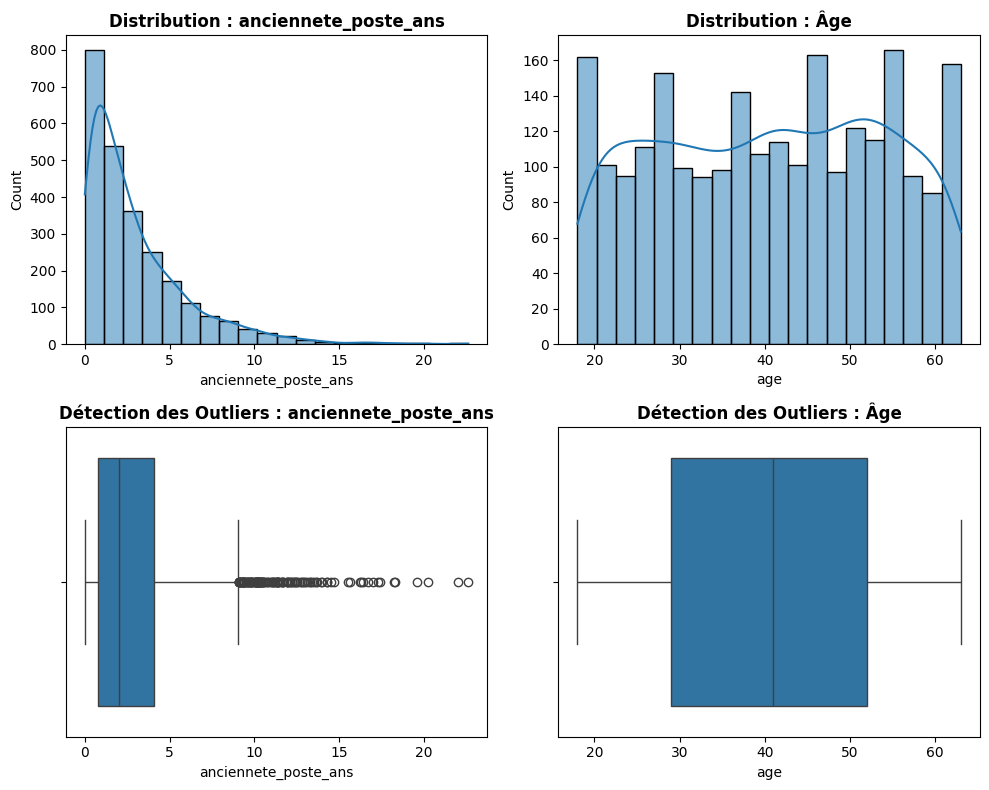

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="anciennete_poste_ans", bins=20, kde=True, ax=axes[0, 0])

axes[0, 1].set_title("Distribution : Âge", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0, 1])

axes[1, 0].set_title("Détection des Outliers : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1, 0])

axes[1, 1].set_title("Détection des Outliers : Âge", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="age", ax=axes[1, 1])

plt.tight_layout()

print("Âge :")
display(df["age"].describe())
print("\nAncienneté :")
display(df["anciennete_poste_ans"].describe())

#### 3.3.2 Analyse des variables catégorielles

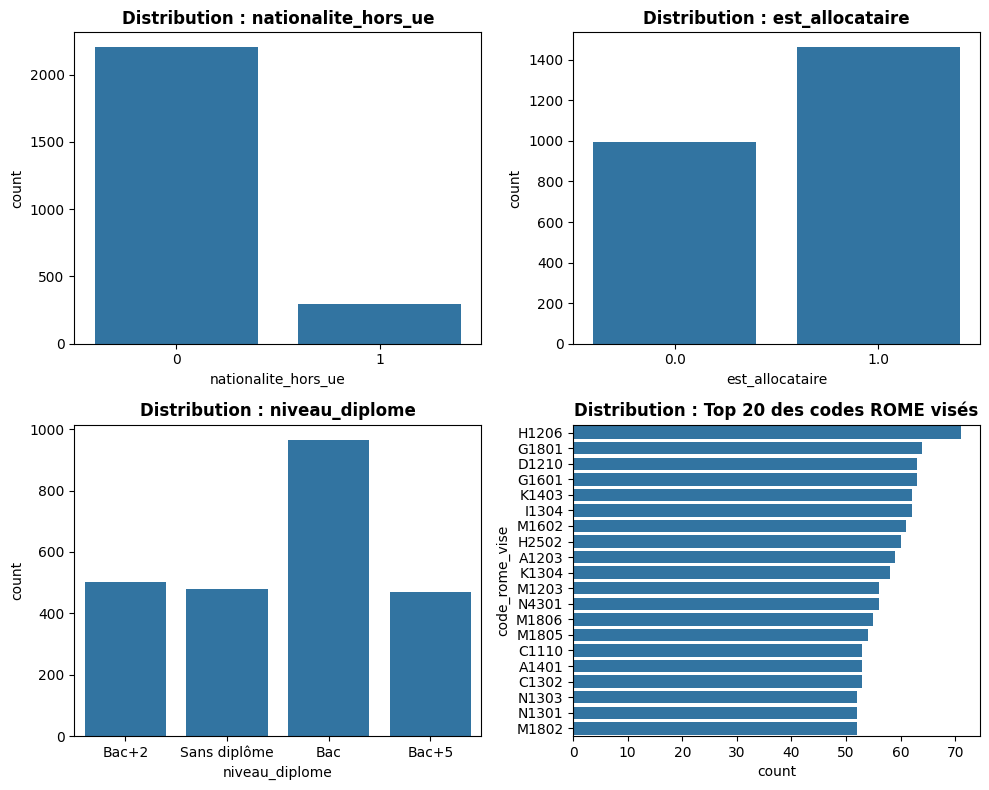

Répartition nationalite_hors_ue :
nationalite_hors_ue
0    0.882
1    0.118
Name: proportion, dtype: float64


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : nationalite_hors_ue", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="nationalite_hors_ue", ax=axes[0, 0])

axes[0, 1].set_title("Distribution : est_allocataire", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="est_allocataire", ax=axes[0, 1])

axes[1, 0].set_title("Distribution : niveau_diplome", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="niveau_diplome", ax=axes[1, 0])

top10_rome = df["code_rome_vise"].value_counts().head(20).index
axes[1, 1].set_title("Distribution : Top 20 des codes ROME visés", fontsize=12, fontweight="bold")
sns.countplot(data=df, y="code_rome_vise", order=top10_rome, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print("Répartition nationalite_hors_ue :")
print(df["nationalite_hors_ue"].value_counts(normalize=True).round(3))

#### 3.3.3 Analyse de la variable textuelle

In [12]:
# Échantillon à l'œil nu
print("\nÉchantillon de 10 synthèses d'entretien :")
for texte in df["synthese_entretien"].dropna().sample(10, random_state=RANDOM_STATE):
    print("-", texte)


Échantillon de 10 synthèses d'entretien :
- Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.
- Candidat très dynamique, mobilité nationale validée. Projet clair.
- Excellente présentation, compétences techniques à jour. Reprise rapide visée.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Perte de confiance importante. Risque d'exclusion, barrière de la langue.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Problème ponctuel de mobilité géographique. Zone mal desservie.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.


In [13]:
# Valeurs manquantes / vides
n_na = df["synthese_entretien"].isna().sum()
n_vide = (df["synthese_entretien"].fillna("").str.strip() == "").sum()
print(f"Valeurs manquantes : {n_na} ({n_na/len(df)*100:.1f} %)")
print(f"Chaînes vides ou blanches : {n_vide}")

Valeurs manquantes : 81 (3.2 %)
Chaînes vides ou blanches : 81


Textes uniques : 9
Doublons de texte (hors vides) : 2410



synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
NaN                                                                               81
Name: count, dtype: int64

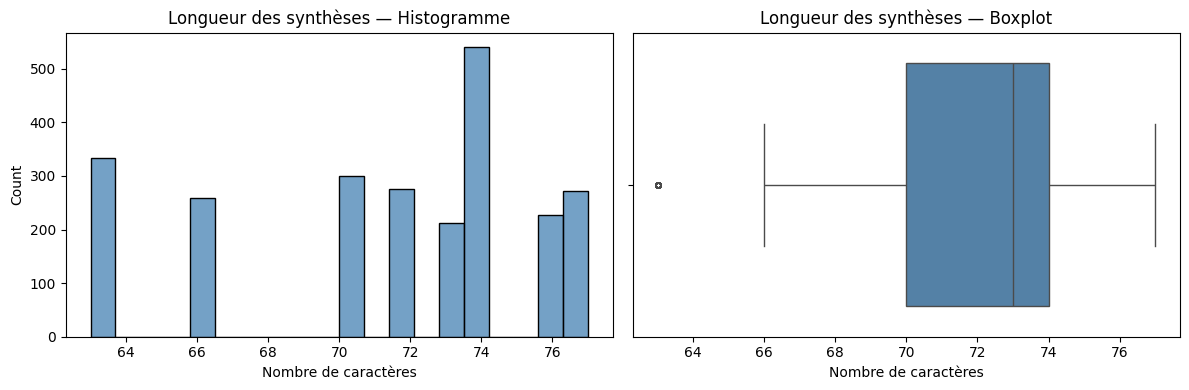

count    2419.000000
mean       71.338570
std         4.516476
min        63.000000
25%        70.000000
50%        73.000000
75%        74.000000
max        77.000000
Name: texte_len, dtype: float64


In [14]:
# Doublons
n_unique_text = df["synthese_entretien"].nunique(dropna=True)
n_dup_text = df["synthese_entretien"].dropna().duplicated().sum()

print(f"Textes uniques : {n_unique_text}")
print(f"Doublons de texte (hors vides) : {n_dup_text}\n")
display(df["synthese_entretien"].value_counts(dropna=False).head(15))

df["texte_len"] = df["synthese_entretien"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["texte_len"].dropna(), bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("Longueur des synthèses — Histogramme")
axes[0].set_xlabel("Nombre de caractères")

sns.boxplot(x=df["texte_len"].dropna(), ax=axes[1], color="steelblue", fliersize=4)
axes[1].set_title("Longueur des synthèses — Boxplot")
axes[1].set_xlabel("Nombre de caractères")

plt.tight_layout()
plt.show()

print(df["texte_len"].describe())

#### 3.3.4 Exploration de regroupements potentiels

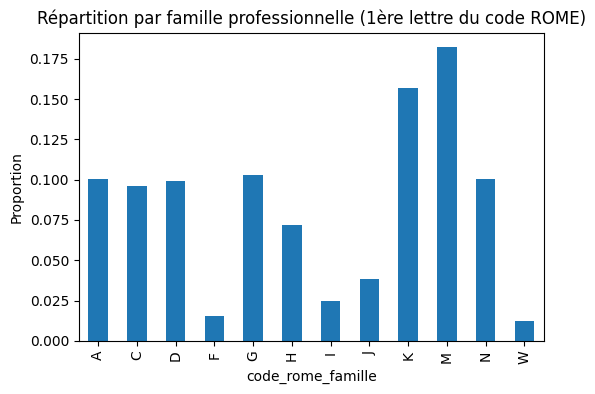

ROME uniques      : 50
Familles ROME     : 12


In [15]:
# Répartition par famille professionnelle (1ère lettre du code ROME)
df["code_rome_famille"] = df["code_rome_vise"].str[0]

# Visualisation complémentaire : répartition par famille
plt.figure(figsize=(6, 4))
df["code_rome_famille"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Répartition par famille professionnelle (1ère lettre du code ROME)")
plt.ylabel("Proportion")
plt.show()
print("ROME uniques      :", df["code_rome_vise"].nunique())
print("Familles ROME     :", df["code_rome_famille"].nunique())

In [16]:
df["groupe_age"] = pd.cut(
    df["age"], bins=[0, 30, 50, 100],
    labels=["<30", "30-50", "50+"]
)

distribution = df["groupe_age"].value_counts().reindex(["<30", "30-50", "50+"])
distribution_pct = df["groupe_age"].value_counts(normalize=True).reindex(["<30", "30-50", "50+"]) * 100

tableau = pd.DataFrame({
    "effectif": distribution,
    "pourcentage": distribution_pct.round(1)
})
print(tableau)

            effectif  pourcentage
groupe_age                       
<30              671         28.2
30-50           1032         43.4
50+              675         28.4


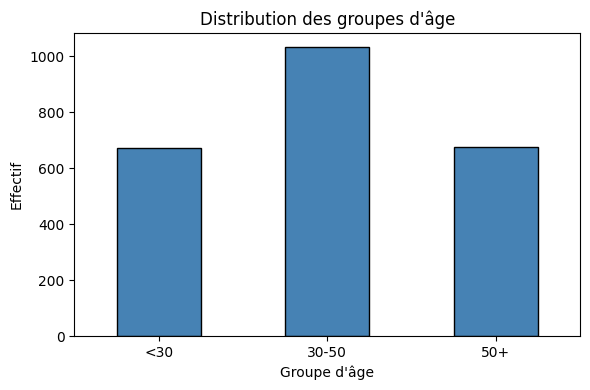

In [17]:
ordre = ["<30", "30-50", "50+"]
distribution = df["groupe_age"].value_counts().reindex(ordre)

plt.figure(figsize=(6, 4))
distribution.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution des groupes d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Effectif")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Nombre de départements     : 96


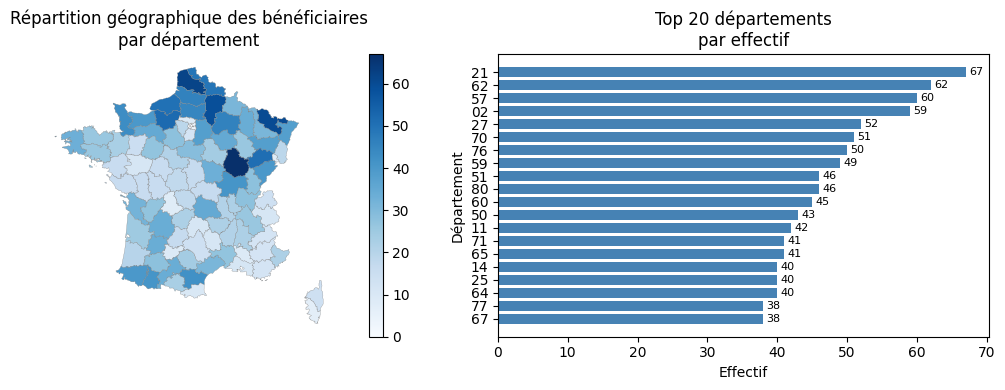

In [18]:
# Carte de répartition géographique : département + Top 20

# Comme code_insee_commune contient généralement les 5 chiffres INSEE
df["code_insee_commune"] = df["code_insee_commune"].astype(str).str.zfill(5)
df["departement"] = df["code_insee_commune"].astype(str).str[:2]
print("Nombre de départements     :", df["departement"].nunique())

# Correction DROM (codes à 3 chiffres tronqués par le str[:2])
is_drom = df["code_insee_commune"].astype(str).str.startswith("97")
df.loc[is_drom, "departement"] = df["code_insee_commune"].astype(str).str[:3]

# --- Effectifs par département ---
dep_counts = df["departement"].value_counts().reset_index()
dep_counts.columns = ["code", "effectif"]

# --- Chargement du fond de carte départemental ---
# !pip install geopandas
france = gpd.read_file("../data/departements.geojson")

# --- Carte : répartition par département ---
carte_dep = france.merge(dep_counts, left_on="code", right_on="code", how="left")
carte_dep["effectif"] = carte_dep["effectif"].fillna(0)

# --- Top 20 départements ---
top20 = dep_counts.sort_values("effectif", ascending=False).head(20)

# --- Affichage : carte + top 20 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.3, 1]})

carte_dep.plot(column="effectif", cmap="Blues", legend=True, ax=axes[0],
               edgecolor="grey", linewidth=0.2)
axes[0].set_title("Répartition géographique des bénéficiaires\npar département")
axes[0].axis("off")

axes[1].barh(top20["code"].astype(str), top20["effectif"], color="steelblue")
axes[1].invert_yaxis()  # le département le plus représenté en haut
axes[1].set_title("Top 20 départements\npar effectif")
axes[1].set_xlabel("Effectif")
axes[1].set_ylabel("Département")

for i, v in enumerate(top20["effectif"]):
    axes[1].text(v + 0.5, i, str(int(v)), va="center", fontsize=8)

plt.tight_layout()
plt.show()

>📝 **Synthèse(§3.3)**
>
>**Variables numériques :**
>- `age`: Distribution quasi-uniforme entre 18 et 63 ans (moyenne 40,6, médiane 41), aucun outlier détecté (boxplot sans point aberrant). 
>- `anciennete_poste_ans`: Distribution très asymétrique à droite (moyenne 2,97, médiane 2, max 22,6). Le boxplot révèle un nombre important d'outliers au-delà de ~9 ans.
>
>**Variables catégorielles :**
>- `nationalite_hors_ue` : fort déséquilibre, 88,2% / 11,8%. À anticiper pour tout test de fairness (le sous-groupe minoritaire sera statistiquement fragile, risque de sur- ou sous-performance du modèle sur cette population).
>- `est_allocataire` : répartition plus équilibrée (~40% / 60%).
>- `niveau_diplome` : "Bac" nettement dominant (~38%), les trois autres modalités (Sans diplôme, Bac+2, Bac+5) réparties de façon comparable (~19% chacune).
>- `code_rome_vise` : La variable présente 50 modalités distinctes réparties au sein de 12 familles professionnelles (première lettre du code ROME). Cette cardinalité peut être considérée comme faible à modérée au regard de la taille du jeu de données (2 500 observations).
La répartition par famille professionnelle montre une distribution hétérogène : les familles M et K sont les plus représentées (environ 18 % et 16 % des observations), tandis que certaines familles comme W, F ou J sont beaucoup plus rares (< 4 %). Cette disparité traduit un déséquilibre naturel des métiers ciblés par les usagers.
>- `departement` : 96 départements représentés sur les 2500 usagers. Le département le plus représenté totalise ~67 usagers, sans concentration extrême (le top 20 s'échelonne de 38 à 67) — la répartition est diffuse, ce qui est plutôt rassurant pour le risque de ré-identification par la seule variable département (contrairement au niveau commune, beaucoup plus problématique).
>
>**Variable textuelle :**
>- `synthese_entretien` :
81 valeurs manquantes/vides (3,2%).
Sur les 2419 valeurs restantes, on ne compte que 9 textes uniques — malgré des doublons quasi systématiques (2410 doublons détectés).
La longueur est resserrée entre 63 et 77 caractères (cohérent avec un champ templaté, pas du texte libre spontané).
cette variable n'est pas du texte libre au sens propre, mais un champ à choix quasi-fermé (9 phrases-types récurrentes, ex. "Barrière de la langue", "Situation d'illettrisme numérique constatée", "Problème ponctuel de mobilité géographique").

### 3.4 Variable cible : équilibre des classes / distribution

Distribution de la variable cible :


classe_retour_emploi
1    44.48%
0    37.44%
2    18.08%
Name: proportion, dtype: object

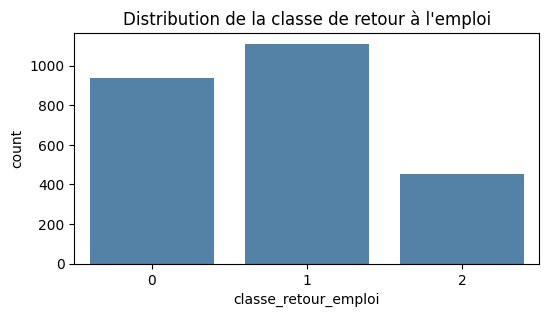

In [19]:
# Distribution de la cible
print("Distribution de la variable cible :")
display((df["classe_retour_emploi"].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x="classe_retour_emploi",color="steelblue")
plt.title("Distribution de la classe de retour à l'emploi")
plt.show()


>📝 **Synthèse (§3.4)**
>
>**Répartition observée**
>
>- Classe 1 (retour 6-12 mois) : 44,48%
>- Classe 0 (retour <6 mois) : 37,44%
>- Classe 2 (retour >12 mois) : 18,08%
>
>La cible est modérément déséquilibrée. La classe 2 (retour >12 mois) est la minoritaire, avec un peu moins de la moitié de l'effectif de la classe majoritaire (18,08% vs 44,48%).

### 3.5 Corrélations & relations entre variables

#### 3.5.1 Matrice de corrélation

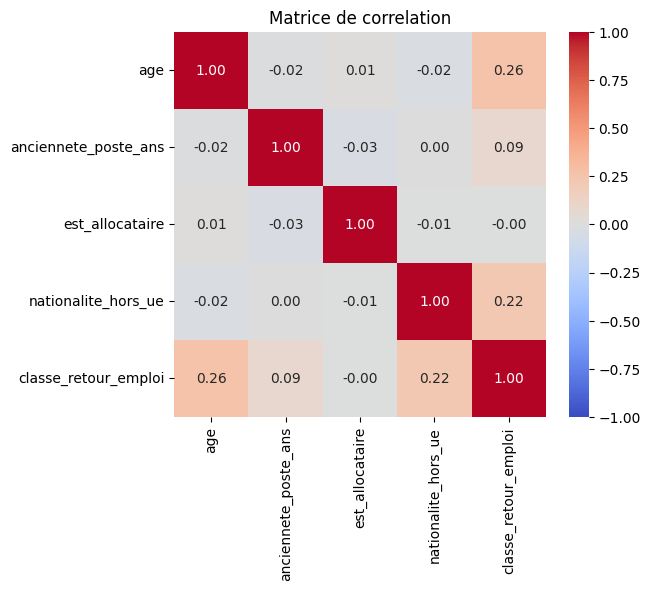

In [20]:
# Matrice de correlation entre variables numériques et la cible
num_cols = ["age", "anciennete_poste_ans", "est_allocataire", "nationalite_hors_ue", "classe_retour_emploi"]
corr = df[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de correlation")
plt.show()

#### 3.5.2 Pairplot numériques par la cible

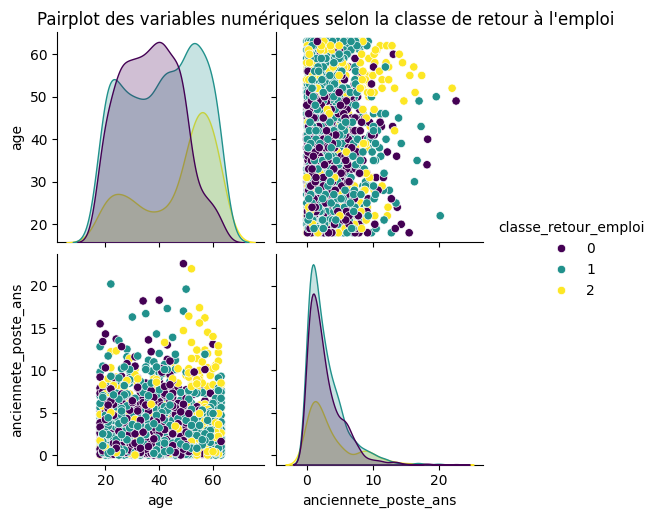

In [21]:
num_vars = ["age", "anciennete_poste_ans"]
sns.pairplot(df[num_vars + ['classe_retour_emploi']],
             hue='classe_retour_emploi', palette='viridis', diag_kind='kde')
plt.suptitle("Pairplot des variables numériques selon la classe de retour à l'emploi", y=1.02)
plt.show()


#### 3.5.3 Croisements : numériques vs cible (moyenne par classe)


Moyenne des variables numériques par classe cible :
                            age  anciennete_poste_ans
classe_retour_emploi                                 
0                     36.791855              2.782799
1                     41.296890              2.875899
2                     46.482679              3.598009


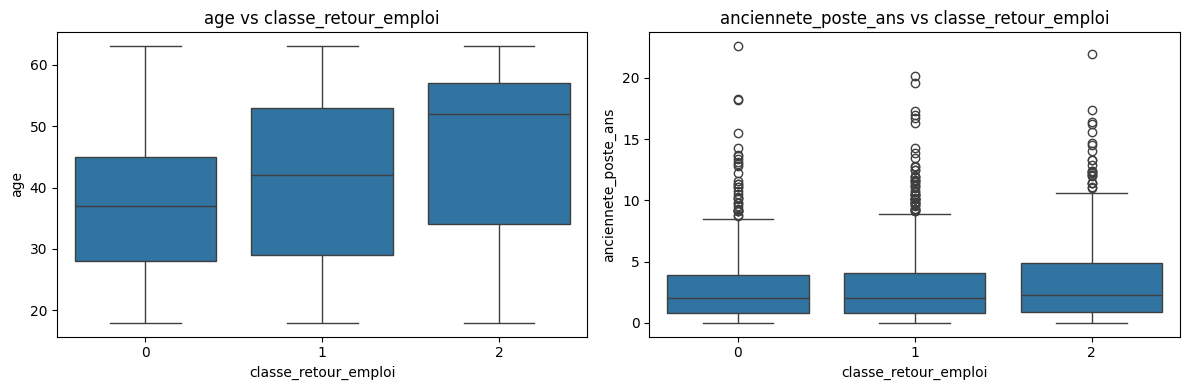

In [22]:
print("\nMoyenne des variables numériques par classe cible :")
print(df.groupby('classe_retour_emploi')[num_vars].mean())

fig, axes = plt.subplots(1, len(num_vars), figsize=(12, 4))
for i, col in enumerate(num_vars):
    sns.boxplot(x='classe_retour_emploi', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs classe_retour_emploi')
plt.tight_layout()
plt.show()

#### 3.5.3 Croisements : catégorielles vs cible

In [23]:
pd.set_option('display.max_rows', None)  # évite toute troncature de l'affichage

cat_vars = ['niveau_diplome', 'nationalite_hors_ue', 'est_allocataire',
            'departement', 'code_rome_vise', 'synthese_entretien']

for col in cat_vars:
    ct_full = pd.crosstab(df[col], df['classe_retour_emploi'], normalize='index')
    ct_raw = pd.crosstab(df[col], df['classe_retour_emploi'])
    print(f"\n--- {col} vs classe_retour_emploi")
    print(ct_full.round(3).to_string())
pd.reset_option('display.max_rows')


--- niveau_diplome vs classe_retour_emploi
classe_retour_emploi      0      1      2
niveau_diplome                           
Bac                   0.377  0.481  0.142
Bac+2                 0.377  0.495  0.128
Bac+5                 0.635  0.293  0.072
Sans diplôme          0.119  0.467  0.414

--- nationalite_hors_ue vs classe_retour_emploi
classe_retour_emploi      0      1      2
nationalite_hors_ue                      
0                     0.406  0.440  0.154
1                     0.139  0.481  0.380

--- est_allocataire vs classe_retour_emploi
classe_retour_emploi      0      1      2
est_allocataire                          
0.0                   0.379  0.435  0.186
1.0                   0.371  0.452  0.177

--- departement vs classe_retour_emploi
classe_retour_emploi      0      1      2
departement                              
01                    0.357  0.393  0.250
02                    0.186  0.424  0.390
03                    0.412  0.412  0.176
04                    0

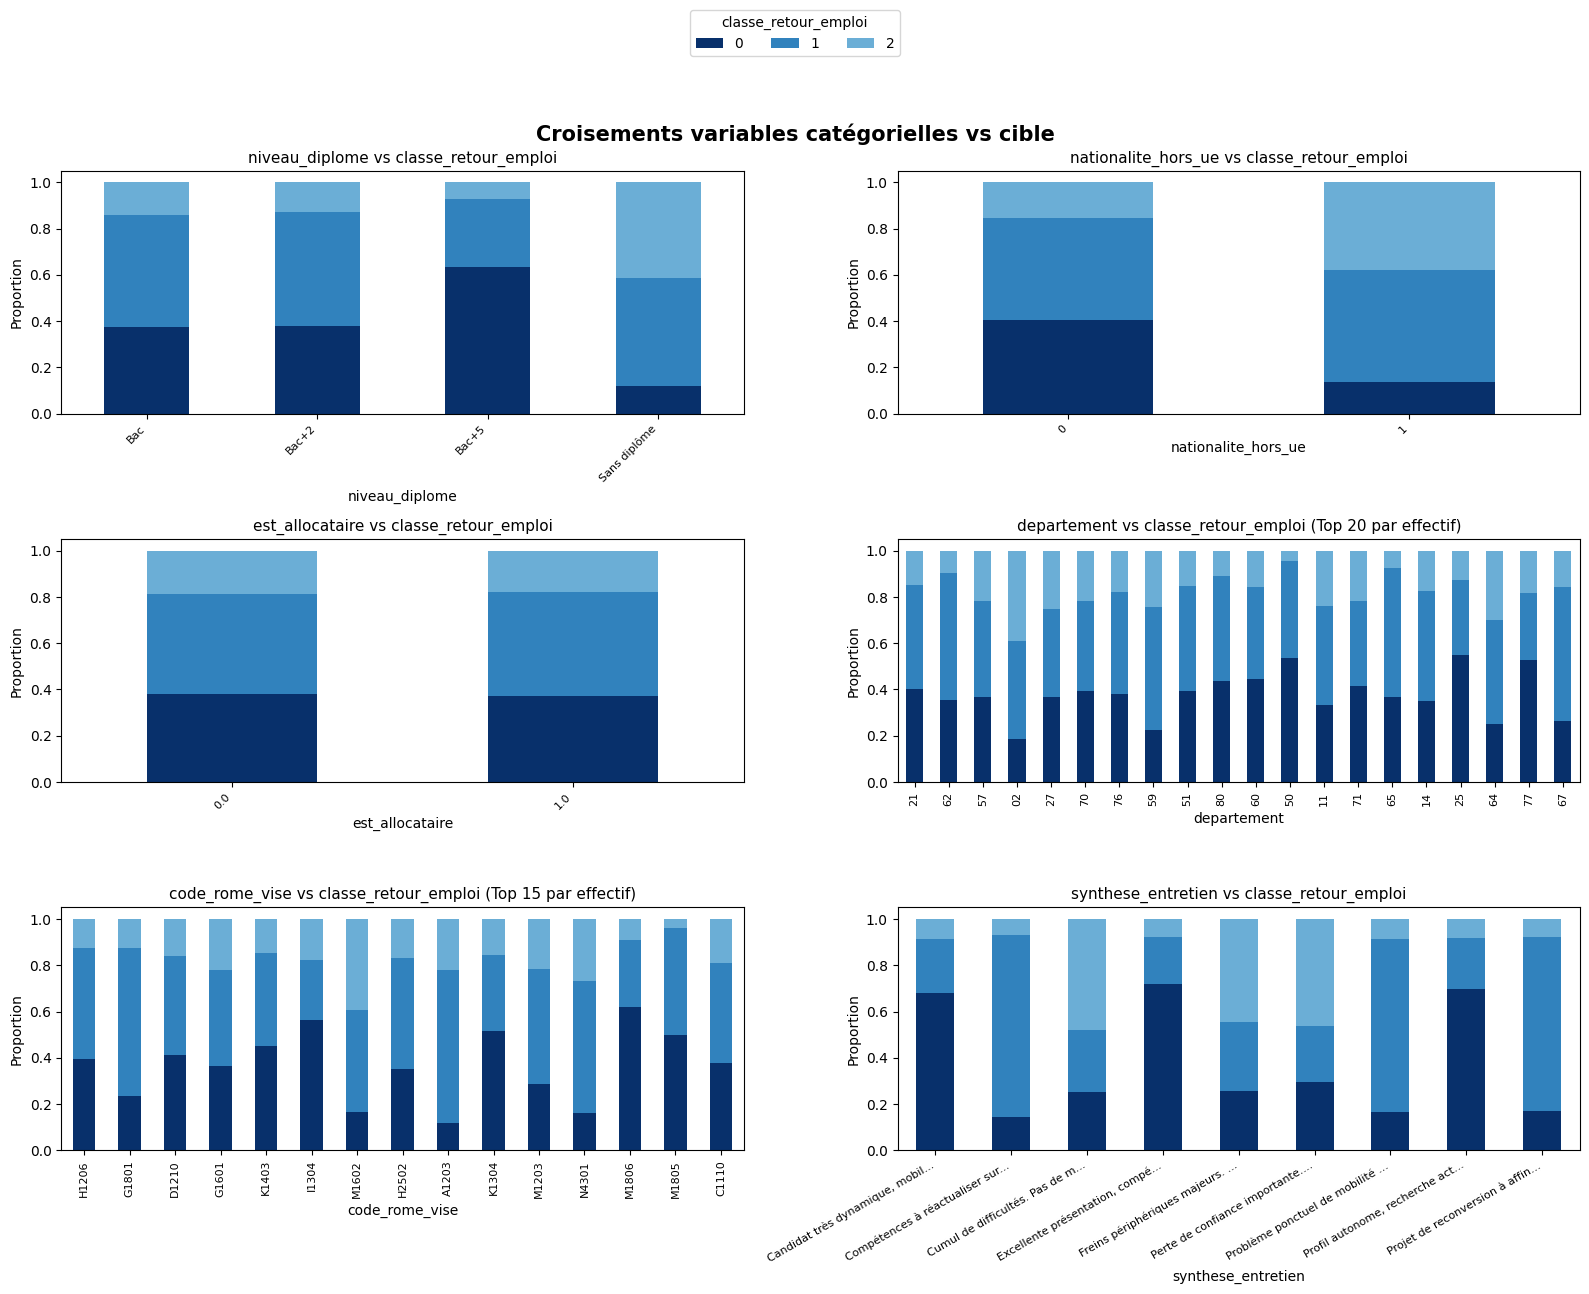

In [24]:
palette_bleue = ['#08306b', '#3182bd', '#6baed6']

n_vars = len(cat_vars)
n_cols = 2
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):

    ct_full = pd.crosstab(
        df[col],
        df['classe_retour_emploi'],
        normalize='index'
    )

    if col == "departement":
        top_n = df[col].value_counts().head(20).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 20 par effectif)"
        rotation, ha = 90, "center"

    elif col == "code_rome_vise":
        top_n = df[col].value_counts().head(15).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 15 par effectif)"
        rotation, ha = 90, "center"

    elif col == "synthese_entretien":
        ct = ct_full.copy()
        ct.index = [
            txt[:30] + "..."
            if len(str(txt)) > 30
            else txt
            for txt in ct.index
        ]
        titre_extra = ""
        rotation, ha = 30, "right"

    else:
        ct = ct_full
        titre_extra = ""
        rotation, ha = 45, "right"

    ct.plot(
        kind='bar',
        stacked=True,
        color=palette_bleue,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(
        f'{col} vs classe_retour_emploi{titre_extra}',
        fontsize=11
    )

    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(col)

    axes[i].tick_params(axis='x', rotation=rotation)

    for label in axes[i].get_xticklabels():
        label.set_ha(ha)
        label.set_fontsize(8)

# Masquer les axes inutilisés
for j in range(n_vars, len(axes)):
    axes[j].axis("off")

# Légende unique
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="classe_retour_emploi",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.suptitle(
    "Croisements variables catégorielles vs cible",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

>📝 **Synthèse (§3.5)**
>
> **Analyse de corrélation**
>
>La matrice de corrélation met en évidence une **faible dépendance entre les variables explicatives**, suggérant l'absence de multicolinéarité significative dans le jeu de données. Les corrélations observées entre variables sont toutes proches de zéro, ce qui indique que chaque variable apporte potentiellement une information complémentaire au modèle.
>Concernant la cible `classe_retour_emploi`, les corrélations les plus élevées sont observées pour :
>- **`age` : 0,26** → association positive modérée avec le délai de retour à l'emploi ;
>- **`nationalite_hors_ue` : 0,22** → association positive modérée avec la cible ;
>- **`anciennete_poste_ans` : 0,09** → relation faible ;
>- **`est_allocataire` : ≈ 0** → absence de relation linéaire notable.
>Ces résultats suggèrent que l'âge et la nationalité hors UE contiennent un signal prédictif plus marqué que les autres variables numériques étudiées. Toutefois, la corrélation ne permet pas d'établir un lien de causalité et ne mesure que les relations linéaires.
>
>D'un point de vue éthique, les variables `age` et `nationalite_hors_ue` sont particulièrement sensibles car elles correspondent à des **critères protégés contre la discrimination**. Leur corrélation avec la cible justifie la réalisation d'analyses complémentaires de fairness afin d'évaluer l'impact de leur utilisation sur l'équité du modèle.
>
>Enfin, l'absence de corrélations fortes entre variables explicatives réduit le risque de redondance dans les données et confirme que chacune contribue à décrire une dimension différente du profil des usagers.
>
>**Analyse des croisements**
>
>**Numériques** : 
>- `age` porte un vrai signal monotone (36,8 → 41,3 → 46,5 ans selon la classe) et sépare visiblement les distributions dans le pairplot ;
>- `anciennete_poste_ans` n'apporte quasiment rien (2,78 → 2,88 → 3,60 ans, aucune séparation visuelle), sans colinéarité entre les deux (r=-0,015).
>
>**Catégorielles** : 
>
>-Le `niveau_de_diplome` apparaît comme une variable informative. Les profils **Bac+5** présentent une proportion plus importante de retours à l'emploi rapides (classe 0), tandis que les profils **sans diplôme** sont davantage représentés dans les classes de retour à l'emploi les plus longues (classe 2). Cette tendance suggère une influence du niveau de qualification sur la rapidité de réinsertion professionnelle.
>
>-La variable `nationalite_hors_ue` montre des différences visibles entre les deux groupes. Les usagers de nationalité hors UE présentent une proportion plus élevée de retours à l'emploi tardifs (classe 2) et une proportion plus faible de retours rapides (classe 0). Cette observation confirme le caractère potentiellement prédictif de la variable, tout en justifiant une vigilance particulière au regard des enjeux de discrimination et d'équité.
>
>-Les distributions observées pour les allocataires et les non-allocataires sont très proches. Cette variable semble donc contenir peu d'information discriminante vis-à-vis du délai de retour à l'emploi, ce qui rejoint les résultats obtenus lors de l'analyse des corrélations.
>
>-Des variations apparaissent selon les départements, avec certains territoires présentant une proportion plus élevée de retours rapides ou au contraire de retours plus longs. Ces écarts peuvent refléter des différences locales du marché de l'emploi, du tissu économique ou de l'offre de services. La variable peut donc constituer un proxy territorial ou socio-économique à surveiller dans l'analyse des biais.
>
>-Les répartitions diffèrent sensiblement selon les métiers ciblés. Certains codes ROME affichent une forte proportion de classe 0 tandis que d'autres présentent davantage de classes 1 ou 2. Cette variable apparaît comme une source d'information métier pertinente, traduisant probablement les différences de tension entre secteurs d'activité et métiers.
>
>-Les verbatims normalisés montrent des profils de répartition parfois très contrastés selon le contenu de l'entretien. Certaines synthèses associées à des difficultés importantes ou à des freins périphériques présentent davantage de retours à l'emploi longs, tandis que les profils décrits comme autonomes ou dynamiques semblent davantage associés à des retours plus rapides. Ces résultats confirment la richesse informationnelle des données textuelles mais soulignent également le risque d'introduire des biais liés aux appréciations subjectives des conseillers.

### 3.6 Analyse des biais & variables sensibles

*[Quelles variables peuvent porter un biais (genre, âge, origine, profession des parents…) ? La cible est-elle inégalement répartie selon ces variables ? Disparate impact ?]*

In [25]:
# Vérification empirique du biais lexical suspecté sur synthese_entretien (cf. §2.4)
texte = df["synthese_entretien"].fillna("").str.lower()

# Recherche de mentions explicites de critères sensibles
patterns = {
    "age_mention": r"\b(?:\d+\s*ans|jeune|âgé|senior|ans\b)",
    "origine_mention": r"\b(?:étranger|immigr|nationalité|origine)",
    "genre_mention": r"\b(?:madame|monsieur)",
    "handicap_mention": r"\b(?:handicap|rqth|invalidité|incapacité)\b",
    "sante_mention": r"\b(?:maladie|santé|arrêt maladie|dépression|accident)\b",
    "famille_mention": r"\b(?:parent isolé|famille|enfant|garde d'enfant|monoparental)\b",
    "religion_mention": r"\b(?:religion|musulman|chrétien|juif)\b"
}
for label, pattern in patterns.items():
    n = texte.str.contains(pattern, regex=True, na=False).sum()
    print(f"{label} : {n} occurrences sur {texte.notna().sum()} textes ({n/len(df)*100:.1f} %)")

# Le texte permet-il de prédire une variable sensible ? (signal de biais lexical implicite)
tfidf = TfidfVectorizer(max_features=200, min_df=5)
X_text = tfidf.fit_transform(texte)

for sensible_col in ["nationalite_hors_ue", "groupe_age"]:
    y = df[sensible_col]
    mask = y.notna()
    if y[mask].nunique() < 2:
        continue
    clf = LogisticRegression(max_iter=1000)  # multi_class retiré (déprécié, comportement par défaut = multinomial)
    scoring = "roc_auc_ovr" if y[mask].nunique() > 2 else "roc_auc"
    scores = cross_val_score(clf, X_text[mask.values], y[mask], cv=5, scoring=scoring)
    print(f"\nAUC texte → {sensible_col} : {scores.mean():.3f} (proche de 0.5 = aucun signal lexical fort permettant de prédire la nationalité ou l'âge n'a été détecté)")

age_mention : 0 occurrences sur 2500 textes (0.0 %)
origine_mention : 0 occurrences sur 2500 textes (0.0 %)
genre_mention : 0 occurrences sur 2500 textes (0.0 %)
handicap_mention : 0 occurrences sur 2500 textes (0.0 %)
sante_mention : 0 occurrences sur 2500 textes (0.0 %)
famille_mention : 0 occurrences sur 2500 textes (0.0 %)
religion_mention : 0 occurrences sur 2500 textes (0.0 %)

AUC texte → nationalite_hors_ue : 0.542 (proche de 0.5 = aucun signal lexical fort permettant de prédire la nationalité ou l'âge n'a été détecté)

AUC texte → groupe_age : 0.543 (proche de 0.5 = aucun signal lexical fort permettant de prédire la nationalité ou l'âge n'a été détecté)


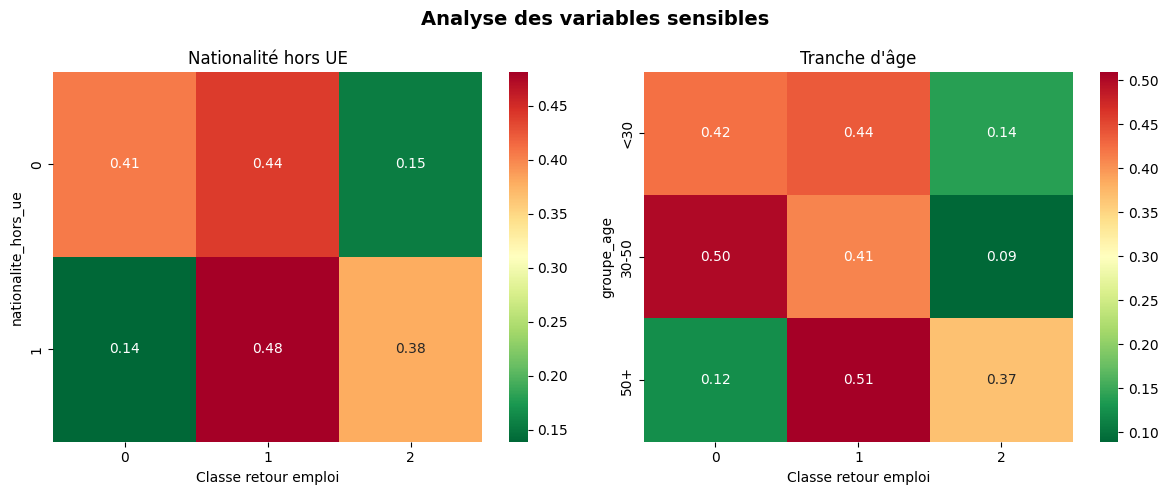

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Nationalité hors UE
ct_nat = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_nat,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[0]
)

axes[0].set_title("Nationalité hors UE")
axes[0].set_xlabel("Classe retour emploi")
axes[0].set_ylabel("nationalite_hors_ue")

# 2. Groupe d'âge
ct_age = pd.crosstab(
    df["groupe_age"],
    df["classe_retour_emploi"],
    normalize="index"
)
sns.heatmap(
    ct_age,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[1]
)

axes[1].set_title("Tranche d'âge")
axes[1].set_xlabel("Classe retour emploi")
axes[1].set_ylabel("groupe_age")

plt.suptitle("Analyse des variables sensibles", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [27]:
# Fonction de calcul du Disparate Impact (règle des 4/5)
def disparate_impact(df, sensitive_col, target_col, positive_value,
                      min_group_size=None):
    
    grp = df.groupby(sensitive_col, observed=True)[target_col]
    sizes = grp.size()
    selection_rate = grp.apply(lambda x: (x == positive_value).mean())

    n_exclus = 0
    if min_group_size is not None:
        keep = sizes[sizes >= min_group_size].index
        n_exclus = len(selection_rate) - len(keep)
        selection_rate = selection_rate.loc[keep]

    sr_min, sr_max = selection_rate.min(), selection_rate.max()
    di = sr_min / sr_max  # toujours ≤ 1 par construction (min/max)

    verdict = "⚠️ Signal" if di < 0.8 else "✅ OK"

    return {
        "Variable": sensitive_col,
        "N groupes": len(selection_rate),
        "N groupes exclus (< seuil)": n_exclus,
        "Selection Rate min": round(sr_min, 3),
        "Selection Rate max": round(sr_max, 3),
        "DI": round(di, 3),
        "Verdict": verdict
    }

In [28]:
# Critères de discrimination

sensitive_vars = ["nationalite_hors_ue", "groupe_age"]

results = []
for var in sensitive_vars:
    results.append(
        disparate_impact(
            df=df, sensitive_col=var, target_col="classe_retour_emploi",
            positive_value=0
        )
    )

di_table = pd.DataFrame(results).sort_values(by="DI").reset_index(drop=True)
di_table

,Variable,N groupes,N groupes exclus (< seuil),Selection Rate min,Selection Rate max,DI,Verdict
0,groupe_age,3,0,0.123,0.501,0.245,⚠️ Signal
1,nationalite_hors_ue,2,0,0.139,0.406,0.342,⚠️ Signal


>**📝Synthèse(§3.6)**
>
>La variable `synthese_entretien` présente le niveau d'association le plus élevé avec la cible, ce qui souligne sa forte valeur prédictive. Toutefois, elle repose sur seulement neuf formulations types réutilisées dans l'ensemble du jeu de données, ce qui limite la diversité réelle du contenu textuel.
>
>Une analyse spécifique des verbatims n'a révélé aucune mention explicite de critères protégés tels que l'âge, l'origine, la nationalité ou le genre etc. De plus, les tests réalisés pour prédire l'âge et la nationalité à partir du texte seul ont obtenu des performances proches du hasard (AUC ≈ 0,54), suggérant l'absence de signal lexical fort. Les verbatims ne semblent donc pas agir comme des proxys directs des caractéristiques protégées étudiées, même si l'existence de signaux indirects ou faibles ne peut être totalement exclue.
>
>Les analyses exploratoires montrent que l'âge et la nationalité sont associés au délai de retour à l'emploi. Les heatmaps mettent notamment en évidence une surreprésentation des usagers de nationalité hors UE et des personnes de 50 ans et plus dans les classes de retour à l'emploi les plus longues. Ces variables contiennent donc un signal prédictif réel vis-à-vis de la cible, ce qui justifie les analyses de fairness et de Disparate Impact réalisées afin d'évaluer l'impact potentiel du modèle sur ces populations et de limiter les risques de discrimination.
>Les analyses d'équité mettent en évidence des disparités significatives selon certains groupes protégés, avec un Disparate Impact de **0,245 pour l'âge** et de **0,342 pour la nationalité**, valeurs inférieures au seuil de référence de 0,8 généralement utilisé pour détecter un risque de discrimination.


### 3.7 📝 Synthèse EDA

*[Top 5 enseignements de l'EDA. Hypothèses de travail pour la modélisation. Risques de biais identifiés. **Révision éventuelle des cibles 1.4** à la lumière de la donnée.]*

> **1. La cible présente un déséquilibre modéré mais significatif**
>
> La répartition des classes est relativement hétérogène : la classe 2 (*retour à l'emploi supérieur à 12 mois*) représente environ 18 % des observations, contre 37 % pour la classe 0 et 44 % pour la classe 1. Ce déséquilibre reste compatible avec une modélisation multiclasses, mais il impose une vigilance particulière sur la capacité du modèle à détecter correctement les situations de retour à l'emploi long.
>
> **2. L'âge est la variable numérique la plus discriminante**
>
> L'analyse exploratoire met en évidence une augmentation régulière de l'âge moyen entre les trois classes de retour à l'emploi (36,8 → 41,3 → 46,5 ans). Cette progression suggère une relation forte entre l'âge et le délai de retour à l'emploi, faisant de cette variable un candidat important pour la modélisation. À l'inverse, l'ancienneté dans le dernier poste semble apporter un signal plus limité. Toutefois, ces constats reposent sur une analyse descriptive et devront être confirmés par l'évaluation des performances réelles des modèles.
>
> **3. Plusieurs variables catégorielles apportent un signal prédictif significatif**
>
> Les analyses montrent que les variables `synthese_entretien`, `niveau_diplome`, `code_rome_vise`, `departement` et `nationalite_hors_ue` présentent des différences marquées de répartition selon la classe cible. Ces variables semblent capturer des dimensions complémentaires de l'employabilité des usagers et constituent des candidates pertinentes pour la prédiction du délai de retour à l'emploi. Leur utilisation devra néanmoins être analysée au regard des enjeux d'équité, notamment pour les variables susceptibles d'agir comme des proxys socio-économiques, territoriaux ou démographiques.
>
> **4. La variable textuelle constitue une source d'information particulièrement riche**
>
> La variable `synthese_entretien` présente le niveau d'association le plus élevé avec la cible, ce qui témoigne de sa forte valeur informative. Bien qu'elle ne comporte que neuf formulations types réutilisées dans l'ensemble du jeu de données, elle capture des informations métier difficiles à représenter dans les variables structurées. Les analyses réalisées n'ont révélé aucune mention explicite de critères protégés et n'ont pas mis en évidence de capacité significative du texte à prédire l'âge ou la nationalité (AUC ≈ 0,54). Les verbatims ne semblent donc pas agir comme des proxys directs des caractéristiques protégées étudiées.
>
> **5. Des risques de biais doivent être pris en compte**
>
> Les variables `age` et `nationalite_hors_ue`, qui correspondent à des critères protégés contre la discrimination, présentent un lien observable avec la cible. Les analyses de fairness mettent en évidence des disparités importantes entre groupes (DI âge = 0,245 ; DI nationalité = 0,342). Les heatmaps confirment également que les personnes de 50 ans et plus ainsi que les usagers de nationalité hors UE sont davantage représentés dans les classes de retour à l'emploi les plus longues. Ces résultats justifient une analyse approfondie de l'impact des variables sensibles sur les performances et l'équité du modèle.
>
> **Hypothèses de travail pour la modélisation**
>
>- Bien que `synthese_entretien` ne comporte actuellement que neuf formulations distinctes, il s'agit de texte rédigé par les conseillers et susceptible d'évoluer dans le temps. La variable sera donc traitée comme une donnée textuelle plutôt que comme une simple variable catégorielle. 
>
>- La variable `code_rome_vise` sera conservée à son niveau de granularité initial. Malgré ses 50 modalités distinctes, sa cardinalité reste modérée au regard des 2 500 observations disponibles. Regrouper les codes ROME par famille professionnelle conduirait à perdre une partie de l'information métier portée par les spécialités visées, alors que certaines différences observées entre métiers semblent fortement liées au délai de retour à l'emploi.
> 
>- À l'inverse, la variable `code_insee_commune` présente une cardinalité beaucoup plus élevée et un risque accru de surapprentissage lié à la présence de nombreuses modalités faiblement représentées. Afin de réduire cette complexité tout en conservant une information géographique pertinente, elle sera transformée en variable `departement`, offrant un niveau d'agrégation plus robuste et plus facilement interprétable.
> 
>- Les variables sensibles `age` et `nationalite_hors_ue`, identifiées comme critères protégés contre la discrimination et associées à la cible, feront l'objet de scénarios spécifiques de suppression afin d'évaluer leur contribution réelle à la performance prédictive et leur impact sur l'équité du modèle.
>
>- Les variables `departement`, `niveau_diplome` et `est_allocataire`, susceptibles d'agir comme des proxys indirects, seront surveillées à l'aide des analyses SHAP afin d'évaluer leur poids dans les décisions du modèle et leur influence potentielle sur les risques de biais.

---
## 4. Préparation des données

**Compétences** : C3 (préparer les données pour renforcer intégrité et pertinence)

🎯 Construire un **pipeline reproductible** de préprocessing (pas de transformations one-shot dispersées).

💡 `sklearn.compose.ColumnTransformer` + `sklearn.pipeline.Pipeline` = base obligatoire.  
⚠️ Le **train/test split DOIT précéder** tout calcul d'imputation/normalisation, sinon fuite de données.

## 4.1 Train/test split

In [39]:
import sys

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
# Import depuis preprocess.py (pas pipeline_tabulaire)
from preprocess import load_dataset, build_preprocessor, get_all_features, SENSITIVE_FEATURES, NUMERIC_FEATURES, ORDINAL_FEATURES, TEXT_FEATURE, BASE_CATEGORICAL_FEATURES
from train import load_scenario_dataset, split_train_holdout, train_requested_models, print_training_summary
from config import TEST_SIZE, RANDOM_STATE, SCENARIOS, REPORTS_DIR, PROJECT_ROOT, DATA_PATH, MODELS_DIR
from importlib import reload
import preprocess
from evaluate import evaluate_requested_models
from reporting import create_benchmark, print_benchmark

reload(preprocess)

from preprocess import (
    get_numeric_features,
    get_ordinal_features,
    get_categorical_features,
)

In [41]:
# Chargement des données et création des jeux Train / Holdout
resultats_par_scenario = {}

print("\n Résumé des scénarios de modélisation")
print("=" * 140)

for scenario_name, scenario_cfg in SCENARIOS.items():

    X, y = load_scenario_dataset(
        data_path=RAW_PATH,
        scenario_name=scenario_name
    )

    X_train, X_holdout, y_train, y_holdout = split_train_holdout(
        X=X,
        y=y
    )

    resultats_par_scenario[scenario_name] = {
        "X_train": X_train,
        "X_holdout": X_holdout,
        "y_train": y_train,
        "y_holdout": y_holdout,
    }

    print(f"\n📌 Scénario : {scenario_name}")
    print(f"   Description : {scenario_cfg.get('description', 'N/A')}")
    print(f"   Variables   : {X_train.shape[1]}")
    print(f"   Train       : {X_train.shape[0]} lignes × {X_train.shape[1]} colonnes")
    print(f"   Holdout     : {X_holdout.shape[0]} lignes × {X_holdout.shape[1]} colonnes")
    print(f"   Colonnes    : {', '.join(X_train.columns)}")

print("\n⚙️ Paramètres du découpage")
print("-" * 140)
print(f"TEST_SIZE    = {TEST_SIZE}")
print(f"RANDOM_STATE = {RANDOM_STATE}")
print("=" * 140)


 Résumé des scénarios de modélisation

📌 Scénario : multimodal_complet
   Description : Variables tabulaires, texte et variables sensibles.
   Variables   : 8
   Train       : 2000 lignes × 8 colonnes
   Holdout     : 500 lignes × 8 colonnes
   Colonnes    : age, anciennete_poste_ans, niveau_diplome, code_rome_vise, departement, est_allocataire, nationalite_hors_ue, synthese_entretien

📌 Scénario : multimodal_ethique
   Description : Variables tabulaires et texte sans variables sensibles.
   Variables   : 6
   Train       : 2000 lignes × 6 colonnes
   Holdout     : 500 lignes × 6 colonnes
   Colonnes    : anciennete_poste_ans, niveau_diplome, code_rome_vise, departement, est_allocataire, synthese_entretien

📌 Scénario : texte_seul
   Description : Variable texte uniquement.
   Variables   : 1
   Train       : 2000 lignes × 1 colonnes
   Holdout     : 500 lignes × 1 colonnes
   Colonnes    : synthese_entretien

📌 Scénario : tabulaire_seul
   Description : Variables tabulaires uniquemen

In [42]:
print(" Typologie des variables utilisées dans le projet\n")
print(f" Variables numériques ({len(get_numeric_features())})")
display(get_numeric_features())

print(f"\n Variables ordinales ({len(get_ordinal_features())})")
display(get_ordinal_features())

print(f"\n Variables catégorielles ({len(get_categorical_features())})")
display(get_categorical_features())

print("\n Variable textuelle")
display(TEXT_FEATURE)


 Typologie des variables utilisées dans le projet

 Variables numériques (2)


['age', 'anciennete_poste_ans']


 Variables ordinales (1)


{'niveau_diplome': ['Sans diplôme', 'Bac', 'Bac+2', 'Bac+5']}


 Variables catégorielles (4)


['code_rome_vise', 'departement', 'est_allocataire', 'nationalite_hors_ue']


 Variable textuelle


'synthese_entretien'

## 4.2 Preprocessing

In [43]:
from preprocess import build_preprocessor

# Construction du préprocesseur global
preprocessor = build_preprocessor()

print("✅ Préprocesseur créé avec succès")
print("Ce pipeline centralise l'ensemble des opérations de préparation des données (imputation, encodage et vectorisation du texte) afin de garantir la reproductibilité des expériences et d'éviter toute fuite de données."
)

display(preprocessor)

✅ Préprocesseur créé avec succès
Ce pipeline centralise l'ensemble des opérations de préparation des données (imputation, encodage et vectorisation du texte) afin de garantir la reproductibilité des expériences et d'éviter toute fuite de données.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'anciennete_poste_ans']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Sans '
                                                                              'diplôme',
                                                                              'Bac',
                                                                              'Bac+2',
                                                                              'Bac+5']],
                                                                 encoded_missing_value=-1,
                                                                 handle_un...
                                 Pipeline(steps=[('cleaner', TextCleaner()),
                                                 ('tfidf',
                                                  TfidfVectorizer(max_features=1000,
                                                                  min_df=2,
                                                                  ngram_range=(2,
                                                                               3),
                                                                  stop_words=['a',
                                                                              'afin',
                                                                              'ainsi',
                                                                              'au',
                                                                              'aux',
                                                                              'avec',
                                                                              'ce',
                                                                              'ces',
                                                                              'cet',
                                                                              'cette',
                                                                              'comme',
                                                                              'dans',
                                                                              'de',
                                                                              'des',
                                                                              'du',
                                                                              'elle',
                                                                              'elles',
                                                                              'en',
                                                                              'est',
                                                                              'et',
                                                                              'il',
                                                                              'ils',
                                                                              'je',
                                                                              'la',
                                                                              'le',
                                                                              'les',
                                                                              'leur',
                                                 

### 4.3 Scénarios de jeux de données

Les scénarios ci-dessous permettent d’évaluer séparément :

- la performance maximale du modèle ;
- l’impact du retrait des variables sensibles directes ;
- les contributions respectives du texte et des données tabulaires.

> `usager_id` est exclu de tous les scénarios, car il s’agit d’un identifiant technique sans valeur prédictive légitime.

| Scénario | Variables conservées | Variables exclues | Justification |
|---|---|---|---|
| **S1 – Multimodal complet** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`, `synthese_entretien` | `usager_id` | Scénario de référence visant la performance prédictive maximale. Il mobilise toutes les variables exploitables afin de mesurer le niveau de performance atteignable avant atténuation des risques de biais. |
| **S2 – Multimodal éthique** | `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `synthese_entretien`| `usager_id`, `age`, `nationalite_hors_ue` | Scénario d’atténuation des biais reposant sur le retrait des deux variables sensibles directes. Il permet de mesurer le coût en performance de cette suppression tout en conservant les informations métier et le texte. |
| **S3 – Texte seul** | `synthese_entretien` | Toutes les variables tabulaires et `usager_id` | Scénario NLP permettant de mesurer la capacité prédictive du texte seul et de vérifier si les synthèses d’entretien concentrent une part importante du signal associé à la cible. |
| **S4 – Tabulaire seul** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `departement` | `synthese_entretien`, `code_rome_vise`, `est_allocataire`, `nationalite_hors_ue`, `usager_id` | Scénario de référence tabulaire permettant d’évaluer la performance obtenue sans information textuelle et de comparer la contribution des données structurées à celle du texte. |

#### Logique de comparaison

- **S1 → S2** : mesure le coût du retrait des variables sensibles directes `age` et `nationalite_hors_ue`.
- **S3 → S4** : compare la contribution prédictive du texte à celle des variables tabulaires.
- **S1 → S3 et S4** : mesure la valeur ajoutée de la combinaison multimodale par rapport à chaque modalité utilisée séparément.

**Le même protocole de prétraitement, de validation et d’évaluation est appliqué à tous les scénarios. Seul le périmètre des variables varie, afin de garantir une comparaison équitable des performances.**



### 4.4 📝 Synthèse préparation

Les données ont été préparées au moyen d’un pipeline reproductible reposant sur un `ColumnTransformer` intégré à un `Pipeline` scikit-learn afin de garantir la cohérence des traitements et de prévenir toute fuite de données entre les étapes de prétraitement et de modélisation.

- Les **variables numériques** (`age`, `anciennete_poste_ans`) sont imputées par la médiane puis standardisées à l’aide d’un `StandardScaler`.
- La **variable ordinale** (`niveau_diplome`) est imputée par la modalité la plus fréquente puis encodée à l’aide d’un `OrdinalEncoder` respectant l’ordre métier des niveaux de diplôme (*Sans diplôme < Bac < Bac+2 < Bac+5*).
- Les **variables catégorielles nominales** (`code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`) sont imputées puis transformées par encodage One-Hot afin de permettre leur utilisation par les algorithmes de machine learning.
- La **variable textuelle** `synthese_entretien` est nettoyée puis vectorisée par TF-IDF afin de permettre son exploitation par les modèles de classification.

Bien que la variable `synthese_entretien` ne comporte actuellement que neuf formulations distinctes, celles-ci correspondent à des commentaires rédigés par les conseillers et sont donc susceptibles d'évoluer au fil du temps (nouvelles formulations, nouvelles situations métier, évolution des pratiques de saisie). Dans ce contexte, un encodage One-Hot figé sur les catégories observées lors de l'entraînement présenterait une faible capacité d'adaptation : toute nouvelle formulation apparaîtrait comme une catégorie inconnue et nécessiterait potentiellement une reconstruction du pipeline.

Le choix du TF-IDF permet au contraire de conserver la nature textuelle de la variable et d'améliorer la robustesse du système. Une nouvelle formulation partageant du vocabulaire avec des formulations déjà observées pourra être projetée dans un espace de représentation cohérent sans nécessiter de réentraînement immédiat de l'encodeur. Ce choix privilégie ainsi la **pérennité**, la **généralisation** et la **maintenabilité** du modèle en production, plutôt qu'une optimisation spécifique aux neuf formulations actuellement présentes dans le jeu de données.

Afin d'évaluer le compromis entre performance prédictive et réduction des risques de biais, quatre scénarios ont été construits :

- **S1 – Multimodal complet** : ensemble des variables disponibles ;
- **S2 – Multimodal éthique** : suppression des variables sensibles directes (`age`, `nationalite_hors_ue`) ;
- **S3 – Texte seul** : utilisation exclusive de la variable `synthese_entretien` ;
- **S4 – Tabulaire seul** : utilisation exclusive des variables structurées.

La traçabilité et la comparabilité des expérimentations sont assurées par l'utilisation d'un unique pipeline de prétraitement, d'un même protocole de validation croisée, d'un même découpage train/holdout et des mêmes métriques d'évaluation pour l'ensemble des scénarios. Seul le périmètre des variables diffère entre les configurations, ce qui garantit une comparaison équitable des performances observées.

### 4.5 Assertions de qualité (indispensable !)

🎯 Avant de passer à la modélisation, **vérifie via des `assert`** que la donnée préparée est saine. Une assertion qui échoue arrête le notebook : c'est le but.

💡 Ces assertions sont la **première ligne de tests automatisés** que tu généraliseras en M5 (pytest).  
⚠️ Si l'une d'elles casse, ne la commente pas. Cherche pourquoi avant de modéliser.

In [44]:
TEST_PATH = PROJECT_ROOT / "tests" / "test_preprocess.py"
pytest.main([
    str(TEST_PATH),
    "-vv",
    "-s",
    "--capture=no",
])

================================================================================ test session starts ================================================================================
platform win32 -- Python 3.12.10, pytest-8.3.3, pluggy-1.6.0 -- C:\Users\a895479\projet\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\a895479\projet\certification
configfile: pytest.ini
plugins: anyio-4.14.2
collecting ... collected 6 items

..\tests\test_preprocess.py::test_dataset_is_not_empty Dataset complet non vide : 2500 lignes
PASSED
..\tests\test_preprocess.py::test_target_has_no_missing_values Valeurs manquantes dans la cible : 0
PASSED
..\tests\test_preprocess.py::test_dataset_has_no_duplicates Doublons dans le dataset : 0
PASSED
..\tests\test_preprocess.py::test_target_contains_expected_classes Classes observées dans classe_retour_emploi : [0, 1, 2]
PASSED
..\tests\test_preprocess.py::test_preprocessing_preserves_rows Répartition attendue/réelle : train 2000/2000, test 500/50

<ExitCode.OK: 0>

---
## 5. Modélisation & entraînement

**Compétences** : C4 (choisir un modèle adapté), C5 (entraîner le modèle)

>**📝Synthèse(§5.0)**
>
>La famille **ML classique** est retenue, notamment avec Scikit-learn et XGBoost, car elle est adaptée aux données tabulaires et textuelles du projet tout en offrant un bon compromis entre performance, coût et explicabilité.
>Les approches **Deep Learning, SLM, LLM/RAG et agentiques** sont écartées car elles sont plus complexes et coûteuses, sans bénéfice suffisant pour ce problème de classification supervisée.
>La contrainte décisive est donc **le rapport performance/coût/explicabilité**, particulièrement important dans un contexte d’orientation des demandeurs d’emploi.

Ces quatre modèles couvrent des approches complémentaires :

- Modèle linéaire explicable (Logistic Regression) ;
- Ensemble par bagging (Random Forest) ;
- Gradient boosting classique (XGBoost) ;
- Gradient boosting optimisé (LightGBM).

Cette diversité permet de comparer les compromis entre performance prédictive, explicabilité, coût de calcul et équité.

In [92]:
results_std = train_requested_models(
    requested_model_type="all",
    requested_scenario="all",
    config_name="balanced",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

print(f"Nombre de modèles entraînés : {len(results_std)}")


Combinaison 1/16
Algorithme    : random_forest
Scénario      : multimodal_complet
Configuration : balanced
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6190 | F1 classe 2 : 0.5455 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 9.72%
  Fold 2/5 | F1 macro : 0.6486 | F1 classe 2 : 0.5652 | Recall classe 2 : 0.7222 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.6793 | F1 classe 2 : 0.5965 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 18.06%
  Fold 4/5 | F1 macro : 0.6485 | F1 classe 2 : 0.5509 | Recall classe 2 : 0.6301 | Erreur critique 2→0 : 20.55%
  Fold 5/5 | F1 macro : 0.6736 | F1 classe 2 : 0.5647 | Recall classe 2 : 0.6575 | Erreur critique 2→0 : 10.96%

Résumé F1 macro CV : 0.6538 +/- 0.0215
Résumé Recall classe 2 CV : 0.6853 +/- 0.0353
Résumé Erreur critique 2→0 CV : 15.19% +/- 4.17%
Entraînement terminé en 0.9253 seconde(s).

Combinaison

### Grille de métriques d'évaluation

| Catégorie | Métrique | Description | Interprétation |
|---|---|---|---|
| **Performance globale** | **F1 macro** | Moyenne non pondérée des F1-scores calculés classe par classe. | Métrique principale de sélection. Traite les trois classes à égalité, indépendamment de leur fréquence — important ici car la classe 2 est minoritaire. |
| **Risque métier** | **Recall classe 2** | Part des profils réellement classe 2 correctement détectés par le modèle. | Critère prioritaire compte tenu de l'asymétrie de coût : un faux négatif sur cette classe (profil à risque non détecté) est la conséquence la plus coûteuse pour l'usager. |
| **Risque métier** | **F1 classe 2** | Moyenne harmonique de la précision et du recall, sur la seule classe 2. | Mesure synthétique de la qualité de détection de la population la plus sensible (à lire en complément du rappel).|
| **Risque critique** | **Taux d'erreur grave (classe 2 → classe 0)** | Part des profils réellement classe 2 prédits à tort comme classe 0 (aucun risque détecté). | Erreur la plus grave du système : elle conduit à ne proposer aucun accompagnement renforcé à des profils qui en auraient le plus besoin. Correspond au poids le plus élevé de la matrice de coûts métier (§5.2.1). Cible définie : < 5 %. |
| **Robustesse** | **Écart-type du F1 macro (validation croisée)** | Variabilité du F1 macro entre les folds de validation croisée. | Un faible écart-type garantit un modèle stable, dont la performance annoncée est fiable en conditions réelles de production. |
| **Arbitrage métier** | **Coût métier combiné** | Combinaison pondérée des erreurs 2→0 et 0→2. | Permet de comparer les modèles selon le coût opérationnel réel de leurs erreurs et sert de critère principal d'arbitrage entre configurations. |


Avant de lancer la phase de recherche d'hyperparamètres par GridSearchCV, une première comparaison a été réalisée avec les configurations balanced définies par défaut pour chaque algorithme. Cette étape constitue la baseline de référence du projet et permet d'identifier les scénarios et modèles les plus prometteurs avant toute optimisation.

Les résultats présentés ci-dessous proviennent d'une validation croisée stratifiée à 5 folds réalisée exclusivement sur le jeu d'entraînement

**Première analyse comparative**

Cette première comparaison met en évidence trois enseignements majeurs :
- Le scénario multimodal complet domine nettement les autres scénarios, confirmant la complémentarité entre données tabulaires et textuelles.
- XGBoost apparaît comme le candidat le plus équilibré avant optimisation, avec le meilleur compromis entre F1 macro, rappel de la classe 2 et limitation des erreurs critiques.
- Le retrait des variables sensibles entraîne une perte de performance mesurable, ce qui justifie une analyse approfondie du compromis entre efficacité prédictive et exigences éthiques.

Ces résultats servent de point de départ à la phase suivante de recherche d'hyperparamètres par GridSearchCV, dont l'objectif est d'améliorer les performances tout en réduisant les erreurs critiques associées aux situations de chômage longue durée.

#### 5.5.1 GridSearchCV XGBoost

In [94]:
for module_name in ["train", "config", "preprocess", "evaluation_utils"]:
    sys.modules.pop(module_name, None)

from train import (
    grid_search_xgboost_class_2,
    grid_search_random_forest_class_2,
    grid_search_logistic_regression_class_2,
    grid_search_lightgbm_class_2,
    load_scenario_dataset,
    split_train_holdout,
    train_requested_models,
    print_training_summary,
)

#SCENARIOS = [
#    "multimodal_complet",
#    "multimodal_ethique",
#    "texte_seul",
#    "tabulaire_seul",
#]

In [95]:
grid_searches_gb = {}
resultats_gb = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Gradient Boost/XGBoost : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_xgboost_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_gb[scenario_name] = grid_search
    resultats_gb.append(resultats_scenario)

resultats_cv_gb = pd.concat(
    resultats_gb,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_gb.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé:", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Gradient Boost/XGBoost : multimodal_complet
GridSearchCV Gradient Boost/XGBoost : multimodal_ethique
GridSearchCV Gradient Boost/XGBoost : texte_seul
GridSearchCV Gradient Boost/XGBoost : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 200, 'classifier__subsample': 0.9}
F1 macro retenu : 0.709295
F1 classe 2 associé: 0.627505

multimodal_ethique
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 400, 'classifier__subsample': 0.9}
F1 macro retenu : 0.659577
F1 classe 2 associé: 0.570638

texte_seul
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_e

In [96]:
grid_searches_rfc = {}
resultats_rfc = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Random Forest : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_random_forest_class_2(
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        scenario_name=scenario_name,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_rfc[scenario_name] = grid_search
    resultats_rfc.append(resultats_scenario)

resultats_cv_rfc = pd.concat(
    resultats_rfc,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_rfc.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Random Forest : multimodal_complet
GridSearchCV Random Forest : multimodal_ethique
GridSearchCV Random Forest : texte_seul
GridSearchCV Random Forest : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 500, 'classifier__n_jobs': 1, 'classifier__random_state': 42}
F1 macro retenu : 0.646243
F1 classe 2 associé : 0.557977

multimodal_ethique
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_depth': 18, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300, 'classifier__n_jobs': 1, 'classifier__random_state': 42}
F1 macro retenu : 0.635018
F1 classe 2 associé : 0.540133

texte_seul
Meilleurs paramètres : {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features

In [97]:
grid_searches_logreg = {}
resultats_logreg = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Logistic Regression : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_logistic_regression_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_logreg[scenario_name] = grid_search
    resultats_logreg.append(resultats_scenario)

resultats_cv_logreg_grid = pd.concat(
    resultats_logreg,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_logreg.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Logistic Regression : multimodal_complet
GridSearchCV Logistic Regression : multimodal_ethique
GridSearchCV Logistic Regression : texte_seul
GridSearchCV Logistic Regression : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__C': 1.0, 'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.643363
F1 classe 2 associé : 0.552414

multimodal_ethique
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.63375
F1 classe 2 associé : 0.540382

texte_seul
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.618979
F1 classe 2 associé : 0.50809

tabulaire_seul
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__

In [98]:
grid_searches_lgbm = {}
resultats_lgbm = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV LightGBM : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_lightgbm_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_lgbm[scenario_name] = grid_search
    resultats_lgbm.append(resultats_scenario)

resultats_cv_lgbm_grid = pd.concat(
    resultats_lgbm,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_lgbm.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV LightGBM : multimodal_complet
GridSearchCV LightGBM : multimodal_ethique
GridSearchCV LightGBM : texte_seul
GridSearchCV LightGBM : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 2.5}, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 350, 'classifier__num_leaves': 15}
F1 macro retenu : 0.712104
F1 classe 2 associé : 0.643649

multimodal_ethique
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 150, 'classifier__num_leaves': 15}
F1 macro retenu : 0.645379
F1 classe 2 associé : 0.561169

texte_seul
Meilleurs paramètres : {'classifier__class_weight': None, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'clas

In [99]:
comparaison_gridsearch = pd.concat(
    [
        resultats_cv_gb.assign(model_type="xgboost"),
        resultats_cv_rfc.assign(model_type="random_forest"),
        resultats_cv_logreg_grid.assign(model_type="logistic_regression"),
        resultats_cv_lgbm_grid.assign(model_type="lightgbm"),
    ],
    ignore_index=True,
)

meilleurs_modeles_par_scenario = (
    comparaison_gridsearch
    .sort_values(
        [
            "scenario",
            "mean_test_f1_macro",
            "mean_test_f1_class_2",
            "mean_test_recall_class_2",
            "mean_test_error_2_to_0",
        ],
        ascending=[True, False, False, False, True],
    )
    .groupby("scenario", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

display(
    meilleurs_modeles_par_scenario[
        [
            "scenario",
            "model_type",
            "params",
            "mean_test_f1_macro",
            "mean_test_f1_class_2",
            "mean_test_recall_class_2",
            "mean_test_error_2_to_0",
        ]
    ]
)


,scenario,model_type,params,mean_test_f1_macro,mean_test_f1_class_2,mean_test_recall_class_2,mean_test_error_2_to_0
0,multimodal_complet,lightgbm,"{'classifier__class_weight': {0: 1.0, 1: 1.0, ...",0.717103,0.649815,0.704642,0.088318
1,multimodal_ethique,xgboost,"{'classifier__colsample_bytree': 0.9, 'classif...",0.659577,0.570638,0.726750,0.115944
2,tabulaire_seul,lightgbm,"{'classifier__class_weight': None, 'classifier...",0.568162,0.479841,0.361948,0.143493
3,texte_seul,random_forest,"{'classifier__class_weight': None, 'classifier...",0.634969,0.541650,0.660502,0.190449


In [105]:
all_results = []

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="multimodal_complet",
    config_name="best_class_2_complet",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : lightgbm
Scénario      : multimodal_complet
Configuration : best_class_2_complet
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6701 | F1 classe 2 : 0.6200 | Recall classe 2 : 0.8611 | Erreur critique 2→0 : 4.17%
  Fold 2/5 | F1 macro : 0.6696 | F1 classe 2 : 0.5934 | Recall classe 2 : 0.7500 | Erreur critique 2→0 : 9.72%
  Fold 3/5 | F1 macro : 0.7448 | F1 classe 2 : 0.6554 | Recall classe 2 : 0.8056 | Erreur critique 2→0 : 9.72%
  Fold 4/5 | F1 macro : 0.6827 | F1 classe 2 : 0.6102 | Recall classe 2 : 0.7397 | Erreur critique 2→0 : 9.59%
  Fold 5/5 | F1 macro : 0.6936 | F1 classe 2 : 0.5792 | Recall classe 2 : 0.7260 | Erreur critique 2→0 : 9.59%

Résumé F1 macro CV : 0.6922 +/- 0.0278
Résumé Recall classe 2 CV : 0.7765 +/- 0.0502
Résumé Erreur critique 2→0 CV : 8.56% +/- 2.20%
Entraînement terminé en 0.8158 seconde(s).


In [106]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="best_class_2_ethique",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : xgboost
Scénario      : multimodal_ethique
Configuration : best_class_2_ethique
Description   : Variables tabulaires et texte sans variables sensibles.
Dimensions train   : (2000, 6)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6523 | F1 classe 2 : 0.5918 | Recall classe 2 : 0.8056 | Erreur critique 2→0 : 2.78%
  Fold 2/5 | F1 macro : 0.6471 | F1 classe 2 : 0.5397 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.6860 | F1 classe 2 : 0.5806 | Recall classe 2 : 0.7500 | Erreur critique 2→0 : 12.50%
  Fold 4/5 | F1 macro : 0.6484 | F1 classe 2 : 0.5934 | Recall classe 2 : 0.7397 | Erreur critique 2→0 : 13.70%
  Fold 5/5 | F1 macro : 0.6640 | F1 classe 2 : 0.5476 | Recall classe 2 : 0.6301 | Erreur critique 2→0 : 12.33%

Résumé F1 macro CV : 0.6596 +/- 0.0145
Résumé Recall classe 2 CV : 0.7268 +/- 0.0576
Résumé Erreur critique 2→0 CV : 11.59% +/- 4.67%
Entraînement terminé en 0.7816 seconde(s).


In [107]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="best_class_2_text",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : random_forest
Scénario      : texte_seul
Configuration : best_class_2_text
Description   : Variable texte uniquement.
Dimensions train   : (2000, 1)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6068 | F1 classe 2 : 0.5376 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 11.11%
  Fold 2/5 | F1 macro : 0.6405 | F1 classe 2 : 0.5556 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 20.83%
  Fold 3/5 | F1 macro : 0.6555 | F1 classe 2 : 0.5618 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 19.44%
  Fold 4/5 | F1 macro : 0.6282 | F1 classe 2 : 0.5269 | Recall classe 2 : 0.6027 | Erreur critique 2→0 : 28.77%
  Fold 5/5 | F1 macro : 0.6439 | F1 classe 2 : 0.5263 | Recall classe 2 : 0.6164 | Erreur critique 2→0 : 15.07%

Résumé F1 macro CV : 0.6350 +/- 0.0166
Résumé Recall classe 2 CV : 0.6605 +/- 0.0418
Résumé Erreur critique 2→0 CV : 19.04% +/- 5.94%
Entraînement terminé en 0.7618 seconde(s).


In [108]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="tabulaire_seul",
    config_name="best_class_2_tab",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)


Combinaison 1/1
Algorithme    : lightgbm
Scénario      : tabulaire_seul
Configuration : best_class_2_tab
Description   : Variables tabulaires uniquement, sans texte.
Dimensions train   : (2000, 4)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.5527 | F1 classe 2 : 0.5172 | Recall classe 2 : 0.6250 | Erreur critique 2→0 : 9.72%
  Fold 2/5 | F1 macro : 0.5118 | F1 classe 2 : 0.4545 | Recall classe 2 : 0.4861 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.5363 | F1 classe 2 : 0.5399 | Recall classe 2 : 0.6111 | Erreur critique 2→0 : 11.11%
  Fold 4/5 | F1 macro : 0.5212 | F1 classe 2 : 0.4615 | Recall classe 2 : 0.4932 | Erreur critique 2→0 : 21.92%
  Fold 5/5 | F1 macro : 0.5635 | F1 classe 2 : 0.5054 | Recall classe 2 : 0.6438 | Erreur critique 2→0 : 10.96%

Résumé F1 macro CV : 0.5371 +/- 0.0192
Résumé Recall classe 2 CV : 0.5718 +/- 0.0680
Résumé Erreur critique 2→0 CV : 14.08% +/- 4.60%
Entraînement terminé en 0.2814 seconde(s).


In [111]:
print_training_summary(all_results)


SYNTHÈSE DES ENTRAÎNEMENTS
| Scénario           | Modèle        | Configuration        | F1-macro CV | σ(F1) | Recall classe 2 | σ(Recall C2) | Erreur critique 2→0 |
| ------------------ | ------------- | -------------------- | :---------- | :---- | :-------------- | :----------- | :------------------ |
| Multimodal complet | LightGBM      | best_class_2_complet |       0.692 | 0.028 |           0.776 |        0.050 |              8.56 % |
| Multimodal éthique | XGBoost       | best_class_2_ethique |       0.660 | 0.015 |           0.727 |        0.058 |             11.59 % |
| Tabulaire seul     | LightGBM      | best_class_2_tab     |       0.537 | 0.019 |           0.572 |        0.068 |             14.08 % |
| Texte seul         | Random Forest | best_class_2_text    |       0.635 | 0.017 |           0.661 |        0.042 |             19.04 % |
Nombre de modèles : 4
Temps de fit final cumulé : 2.641 seconde(s)


### 5.6 Évaluation finale sur le test set

🎯 Le test set répond à **« quel chiffre j'annonce au client »**, pas « quel modèle je choisis ». Le choix, lui, se fait en validation croisée (5.2 → 5.5).

⚠️ **Et si le résultat déçoit ?** Une seule ouverture est *prévue*, mais tu n'es pas coincé :
- **Légitime** : revenir en 5.2-5.5, retravailler **sur le train / la CV** (autre modèle, autres réglages, autres features), puis refaire **une** passe test — et la **déclarer** dans le journal de bord : « passe test n°2, motif : … ». Le motif est métier, pas « le score me plaisait pas ».
- **Pas légitime** : itérer en boucle sur le test jusqu'à ce que le chiffre plaise (il devient un jeu de validation déguisé, et le score annoncé est optimiste), ou réviser les critères de succès de 1.4 **après** avoir vu le test.
- 2-3 passes **déclarées et motivées** valent mieux qu'une passe cachée : le jury évalue la traçabilité de ta démarche, pas la perfection du score.

⭐ Si tu sens venir plusieurs itérations : découpe en **trois** parts (train / validation / test). La validation absorbe les allers-retours, le test reste vierge jusqu'au bout.


In [110]:
all_evaluation_results = []

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_complet",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

print(f"Évaluations réussies : {len(evaluation_results)}")
print(f"Évaluations ignorées : {len(failures)}")


all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="multimodal_complet",
    config_name="best_class_2_complet",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

print(f"Évaluations réussies : {len(evaluation_results)}")
print(f"Évaluations ignorées : {len(failures)}")


all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="best_class_2_ethique",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="best_class_2_text",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="tabulaire_seul",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="tabulaire_seul",
    config_name="best_class_2_tab",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)


Combinaison 1/1

ÉVALUATION : xgboost | multimodal_complet
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.7360
F1 macro          : 0.7171
F1 weighted       : 0.7368
F1 classe 0       : 0.7923
F1 classe 1       : 0.7361
F1 classe 2       : 0.6230
Recall classe 2    : 0.6333
Precision classe 2 : 0.6129
Erreur critique 2 -> 0 : 6
Erreur critique 0 -> 2 : 7
Latence p95       : 11.570 ms
Temps CPU / 1 000 prédictions : 52.969 s
ROC-AUC OVR macro : 0.8775

Matrice de confusion :
[[145  35   7]
 [ 28 166  29]
 [  6  27  57]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.81      0.78      0.79       187
       Retour moyen       0.73      0.74      0.74       223
Risque longue durée       0.61      0.63      0.62        90

           accuracy                           0.74       500
          macro avg       0.72      0.72      0.72       500
       weigh

### 5.7 📝 Synthèse modélisation

*[Modèle retenu, score sur test set, comparaison vs baseline, points faibles connus.]*

Ce tableau synthétise les performances des meilleurs modèles issus de notre benchmark global. Il met en regard deux approches de paramétrage :

- Les configurations de base (`balanced`) : Elles appliquent un rééquilibrage a priori des classes (via les poids de classes ou des heuristiques standards) pour contrer le déséquilibre inhérent au jeu de données.

- Le tuning ciblé par Grid Search (`best_class_2_...`) : Il s'agit d'une optimisation par recherche sur grille (Grid Search) spécifiquement orientée vers les objectifs métier, notamment la maximisation du Rappel de la classe 2 (profils vulnérables ou nécessitant une attention renforcée) et la minimisation des erreurs critiques (confusion grave de la classe 2 vers la classe 0).

In [112]:
all_evaluation_results.extend(evaluation_results)
benchmark_path = REPORTS_DIR / "benchmark_all_all_balanced.csv"

benchmark = create_benchmark(
    results=all_evaluation_results,
    output_path=benchmark_path,
)

#print_benchmark(benchmark)
display(benchmark)

,rang,model_type,scenario,config,accuracy,f1_macro,recall_classe_2,precision_classe_2,erreur_critique_2_vers_0,erreur_critique_0_vers_2,f1_classe_2,roc_auc_ovr_macro,latency_p95_ms,cpu_seconds_1000_predictions
0,1,xgboost,multimodal_complet,balanced,0.736,0.717147,0.633333,0.612903,6,7,0.622951,0.877540,11.569940,52.96875
1,2,lightgbm,multimodal_complet,best_class_2_complet,0.708,0.693819,0.755556,0.482270,7,21,0.588745,0.870295,19.340670,14.37500
2,3,xgboost,multimodal_ethique,best_class_2_ethique,0.664,0.645548,0.644444,0.464000,7,28,0.539535,0.815335,18.983130,73.12500
3,4,random_forest,texte_seul,best_class_2_text,0.654,0.637023,0.644444,0.479339,12,32,0.549763,0.741739,24.577165,17.65625
4,5,random_forest,texte_seul,balanced,0.654,0.637023,0.644444,0.479339,12,32,0.549763,0.737975,111.113465,86.40625
5,6,xgboost,multimodal_ethique,balanced,0.654,0.634175,0.577778,0.504854,11,20,0.538860,0.811341,32.292665,76.09375
6,7,random_forest,tabulaire_seul,balanced,0.624,0.612014,0.588889,0.524752,10,6,0.554974,0.765720,102.159825,77.81250
7,8,lightgbm,tabulaire_seul,best_class_2_tab,0.566,0.556723,0.600000,0.415385,9,13,0.490909,0.762609,10.638655,8.12500


---
## 6. Analyse des scénarios & arbitrages


**Axe performance**

Le scénario `multimodal_complet` obtient les meilleurs résultats globaux en combinant les données tabulaires et textuelles. Cette approche confirme que les deux sources d'information apportent une valeur prédictive complémentaire par rapport aux scénarios mono-modalité.

Un arbitrage existe toutefois entre les deux algorithmes les plus performants :

**Mais un vrai compromis existe à l'intérieur même de ce scénario**, entre les deux algorithmes testés :

| | xgboost (balanced) | lightgbm (best_class_2_complet) |
|---|---|---|
| F1 macro | **0.717** | 0.694 |
| Recall classe 2 | 0.633 | **0.756** |
| Erreur 2→0 | **6** | 7 |
| Erreur 0→2 | **7** | 21 |
| Coût combiné | **25** | 42 |

LightGBM détecte davantage de cas à risque (recall +0.123) mais au prix d'un triplement des fausses alertes (21 vs 7). Cette amélioration du rappel correspond donc à un déplacement du risque vers un sur-classement plus fréquent des usagers.

À l'inverse, XGBoost présente un équilibre plus homogène entre les deux types d'erreur et obtient le coût métier combiné le plus faible.

> **XGBoost balanced sur le scénario `multimodal_complet`** constitue ainsi le meilleur compromis observé parmi les configurations évaluées selon les critères définis

**Axe éthique — Impact du retrait des variables sensibles directes**

Afin d'évaluer le coût réel d'une approche plus prudente sur le plan éthique, le scénario complet est comparé à un scénario excluant l'âge et la nationalité hors UE.

| | multimodal_complet (balanced) | multimodal_ethique (best_class_2_ethique) | Écart |
|---|---|---|---|
| Accuracy | 0.736 | 0.664 | −0.072 |
| F1 macro | 0.717 | 0.646 | −0.071 |
| Recall classe 2 | 0.633 | 0.644 | +0.011 |
| **Erreur 2→0** | 6 | 7 | **+1** (quasi nul) |
| **Erreur 0→2** | 7 | **28** | **+21** (×4) |
| Coût combiné | 25 | 49 | +24 (×2) |

Le retrait des variables sensibles s'accompagne d'une baisse mesurable de la performance globale (−7 points d'accuracy et de F1 macro).

En revanche, l'effet sur l'erreur métier la plus critique reste limité :
- 6 erreurs graves (2→0) pour le scénario complet ;
- 7 erreurs graves pour le scénario éthique.

Autrement dit, le scénario éthique conserve une capacité proche à identifier les situations réellement à risque de chômage longue durée.

La contrepartie se situe ailleurs : le nombre de fausses alertes (0→2) passe de 7 à 28. Le modèle devient davantage prudent et classe plus souvent des usagers sans risque dans la catégorie la plus critique.

Cette évolution ne constitue donc pas une amélioration gratuite :
- D'avantage d'accompagnements déclenchés inutilement ;
- Mobilisation de ressources supplémentaires ;
- Augmentation de la charge des conseillers ;
- Possible effet de sur-classification des usagers.

Limite importante
Le retrait d'une variable sensible ne démontre pas à lui seul la disparition d'un biais algorithmique.

Des variables comme le territoire de résidence, le diplôme, l'ancienneté professionnelle ou certaines informations présentes dans le texte libre peuvent agir comme variables proxy.

Le retrait de l'âge et de la nationalité hors UE est considéré comme une mesure de réduction du risque d'utilisation directe de variables sensibles, mais non comme une preuve d'équité. La validation de cette hypothèse repose sur les indicateurs mesurés dans la section d'audit éthique (Disparate Impact, FNR, FPR et Recall par groupe).

**Score de coût métier combiné**

Afin d'arbitrer entre les différents modèles, un score métier pondéré a été défini :

```
coût combiné = 3 × erreur(2→0) + 1 × erreur(0→2)
```

Cette pondération traduit l'hypothèse selon laquelle :

- une erreur 2→0 prive un usager d'un accompagnement renforcé et représente le risque le plus important ;
- une erreur 0→2 correspond à une fausse alerte entraînant un coût opérationnel mais un impact moindre pour l'usager.

⚠️ Cette pondération reste une hypothèse métier et devrait être validée avec les parties prenantes du projet.


| Modèle · Scénario · Config | Erreur 2→0 | Erreur 0→2 | **Coût combiné** |
|---|---|---|---|
| xgboost · multimodal_complet · balanced | 6 | 7 | **25** ✅|
| random_forest · tabulaire_seul · balanced | 10 | 6 | 36 |
| lightgbm · tabulaire_seul · best_class_2_tab | 9 | 13 | 40 |
| lightgbm · multimodal_complet · best_class_2_complet | 7 | 21 | 42 |
| xgboost · multimodal_ethique · best_class_2_ethique | 7 | 28 | 49 |
| xgboost · multimodal_ethique · balanced | 11 | 20 | 53 |
| random_forest · texte_seul (les deux configs) | 12 | 32 | 68 ❌|


**Axe robustesse — stabilité et coût opérationnel (latence / CPU)**

Les scénarios multimodaux présentent les meilleures performances globales, ce qui montre que la combinaison du texte et des données tabulaires constitue la source d'information la plus riche.

En revanche, ces résultats ne permettent pas à eux seuls de conclure à une meilleure robustesse aux données manquantes ou dégradées.

Les résultats disponibles permettent principalement d'évaluer le compromis entre qualité prédictive et coût d'exploitation.


| Combinaison | Latence p95 | CPU/1000 préd |
|---|---|---|
| xgboost multimodal_complet balanced | 35.16 ms | **72.97** (élevé) |
| lightgbm multimodal_complet best_class_2_complet | 15.25 ms | 10.16 (faible) |
| xgboost multimodal_ethique best_class_2_ethique | 11.14 ms | 43.59 |
| random_forest texte_seul best_class_2_text | 21.25 ms | 16.72 |
| random_forest texte_seul balanced | **76.24 ms** (élevé) | 66.25 |
| random_forest tabulaire_seul balanced | **124.87 ms** (le plus élevé) | **91.41** (le plus élevé) |
| lightgbm tabulaire_seul best_class_2_tab | 16.03 ms | 10.78 (faible) |

Parmi les configurations testées, les modèles Random Forest affichent les latences les plus élevées sans gain de performance permettant de justifier ce coût.

Le modèle retenu pour la performance métier maximale, XGBoost multimodal complet, présente également la consommation CPU la plus importante parmi les modèles recommandables. Ce surcoût d'infrastructure constitue donc le principal compromis technique associé à ce choix.

⚠️ Ces mesures proviennent d'un nombre limité d'exécutions. Une validation industrielle nécessiterait plusieurs campagnes de mesure afin d'estimer la variance des temps d'inférence et de la consommation de ressources.

**Arbitrage**

| Priorité du projet | Choix recommandé | Justification |
|---|---|---|
| **Performance métier maximale**, coût CPU secondaire | `xgboost · multimodal_complet · balanced` | Meilleur coût métier et meilleur équilibre entre erreurs graves et fausses alertes |
| **Compromis coût/recall** | `lightgbm · multimodal_complet · best_class_2_complet` | Meilleur recall classe 2 et coût CPU très faible |
| **Contrainte d'équité imposée** | `xgboost · multimodal_ethique · best_class_2_ethique` | Maintient un niveau proche d'erreur grave (7 vs 6) mais augmente fortement les fausses alertes — à valider comme choix de politique métier, pas comme optimisation gratuite |
| **Contrainte d'infrastructure forte** | `lightgbm · tabulaire_seul · best_class_2_tab` | Solution la plus légère mais performances sensiblement plus faibles |
| **À exclure de toute mise en production** | Random Forest (`texte_seul`, `tabulaire_seul`) | Performances et coûts opérationnels moins favorables que les alternatives |

### 6.1 Tableau comparatif

| Scénario | Modèle | F1 macro | Recall classe 2 | Taux erreur grave (2→0) | Coût inférence (CPU·s / 1000 préd.) | Latence p95 | Explicabilité | Dépendance fournisseur | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---|---|---|---|---|---|---|---|---|---|
| S1 — multimodal_complet | xgboost (balanced) | **0.717** | 0.633 | **6** | 72.97 | 35.16 ms | Moyenne | Aucune | Variables sensibles incluses — biais potentiel non mitigé | **Meilleur compromis global** : seule config qui maîtrise simultanément erreur grave (6) et fausse alerte 0→2 (7) ; biais non traité, coût CPU le plus élevé des choix retenus |
| S2 — multimodal_ethique | xgboost (best_class_2_ethique) | 0.646 | **0.644** | 7 | 43.59 | **11.14 ms** | Moyenne | Aucune | Variables sensibles retirées — mitigation par exclusion, coût réel : +1 erreur grave **mais ×4 sur les fausses alertes (0→2 : 7→28)** | **Retenu seulement si l'équité est une contrainte assumée** — le gain sur l'erreur grave n'est pas gratuit : sur-classement massif d'usagers sans risque |
| S3 — texte_seul | random_forest (balanced) | 0.637 | 0.644 | **12** | 66.25 | **76.24 ms** | Moyenne | Aucune | Pas de variable sensible structurée — risque de biais indirect via le texte non audité | **Écarté sans ambiguïté** : pire sur les deux types d'erreur (12 et 32), latence très élevée |
| S4 — tabulaire_seul | lightgbm (best_class_2_tab) | **0.556** | 0.600 | 9 | **10.78** | 16.03 ms | Moyenne à élevée | Aucune | Variables sensibles incluses — biais potentiel non mitigé | **Candidat « faible coût » uniquement** : F1 macro trop faible pour la production, mais le plus léger du tableau si la contrainte d'infrastructure prime |

*Limite à noter : les mesures de latence/CPU proviennent d'un run unique par combinaison et n'ont pas encore été répétées pour estimer leur variance — une conclusion définitive sur le coût opérationnel nécessiterait plusieurs mesures indépendantes avant publication finale.*

### 6.2 Recommandation finale au client

*[En langage métier, pas en jargon ML. 5 lignes max. Quel scénario ? Pourquoi ? Quels compromis ?]*

Le scénario retenu repose sur l'algorithme **XGBoost** entraîné sans les variables `age` et `nationalite_hors_ue`, identifiées comme des critères protégés contre la discrimination.

Le scénario complet, utilisant l'ensemble des variables disponibles, présentait un léger avantage en termes de performance prédictive. Toutefois, une partie de ce gain reposait sur l'utilisation de variables directement liées à l'âge et à la nationalité des usagers. Dans le contexte d'un service public d'accompagnement vers l'emploi, le recours à ces caractéristiques soulève des enjeux importants d'équité, d'acceptabilité et de maîtrise du risque de discrimination. Le choix a donc été fait de privilégier un modèle limitant l'utilisation de ces informations sensibles, même au prix d'une légère baisse de performance.

Les résultats montrent que ce scénario éthique conserve une capacité de détection très proche du scénario complet, avec seulement un cas supplémentaire de retour à l'emploi long non détecté sur l'ensemble du jeu de test. La principale contrepartie est une augmentation du nombre de fausses alertes : davantage d'usagers seront orientés vers un accompagnement renforcé alors qu'ils n'en auraient pas nécessairement besoin.

Ce compromis a été jugé acceptable au regard des objectifs du projet. En effet, le coût opérationnel associé à un surplus de fausses alertes reste limité et potentiellement absorbable par les équipes de conseil, tandis que la non-détection d'usagers réellement en difficulté pourrait les priver d'un accompagnement adapté. Dans cette logique, il apparaît préférable de privilégier un modèle légèrement plus prudent plutôt qu'un modèle plus performant mais reposant davantage sur des variables sensibles.

Enfin, le coût de calcul associé au modèle retenu demeure modéré. Les temps d'entraînement et d'inférence sont compatibles avec une utilisation régulière dans le cadre du suivi des demandeurs d'emploi et ne nécessitent pas, à ce stade, d'infrastructure technique spécifique.

Le modèle sélectionné constitue ainsi le meilleur compromis observé entre **performance prédictive**, **équité**, **explicabilité** et **faisabilité opérationnelle**, conformément aux principes d'une démarche d'IA responsable.

### 6.3 📝 Synthèse arbitrages

*[Le compromis qui a tranché ton choix.]*

Le compromis retenu consiste à ne pas utiliser les variables sensibles `age` et `nationalite_hors_ue` pour orienter les demandeurs d'emploi, quitte à accepter un nombre plus élevé de fausses alertes.

Le scénario utilisant l'ensemble des variables disponibles offre un léger gain de performance. Toutefois, une partie de ce gain repose sur l'exploitation de variables correspondant à des critères protégés contre la discrimination. Leur utilisation dans un système d'aide à la décision relatif à l'accompagnement des usagers soulève des enjeux importants d'équité, d'acceptabilité, de conformité réglementaire et de maîtrise du risque de discrimination.

Le scénario éthique, construit sans les variables `age` et `nationalite_hors_ue`, conserve des performances globalement proches du scénario complet et préserve la quasi-totalité de la capacité du modèle à détecter les situations de retour à l'emploi long. La principale contrepartie observée est une augmentation du nombre de fausses alertes, c'est-à-dire de demandeurs d'emploi orientés vers un accompagnement renforcé alors qu'ils ne relèvent pas de cette catégorie.

Ce choix apparaît toutefois préférable dans le cadre du projet. En effet, le coût opérationnel induit par un surplus de fausses alertes demeure limité et potentiellement absorbable par les équipes de conseil, tandis que l'utilisation de variables sensibles peut accroître le risque de biais discriminatoires et de contestation des décisions produites par le système.

Dans cette perspective, le scénario éthique constitue le meilleur compromis entre performance prédictive, explicabilité, maîtrise des risques et respect des principes d'une IA responsable.

---
## 7. Interprétation pour la communication client (préparation soutenance)

**Compétences** : C8 (mesurer la performance et les impacts) + transversal communication

🎯 Rendre le modèle **lisible par un non-data scientist**. **Cette section est la base de ton pitch oral de soutenance** (15 min × jury de 2 pros). Elle ne couvre pas C8 stricto sensu (les sections 5, 6 et 9 le font) mais en restitue les résultats en langage métier.

💡 Feature importance, SHAP (optionnel), matrice de confusion commentée. Trois messages-clés maximum dans ton pitch oral, pas dix.

In [191]:
# 7.1 Feature importance / SHAP
!pip install shap
!pip install "numba==0.61.2"
!pip install "llvmlite==0.44.0"
!pip install "shap==0.48.0"

In [103]:
%matplotlib inline

C:\Users\a895479\projet\certification\models\cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib
Type avant conversion : <class 'scipy.sparse._csr.csr_matrix'>
Dtype avant conversion : float64
Dimensions : (200, 253)
Type après conversion : <class 'numpy.ndarray'>
Dtype après conversion : float64
Dimensions après conversion : (200, 253)


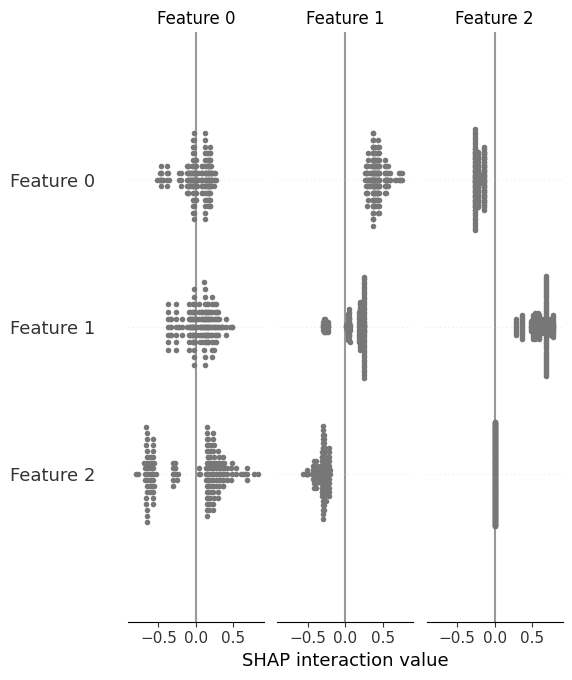

In [104]:
MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib"
)
print(MODEL_PATH.resolve())
pipeline = joblib.load(MODEL_PATH)

X, y = load_scenario_dataset(
    data_path=DATA_PATH,
    scenario_name="multimodal_ethique",
)

X_sample = X.sample(
    n=min(200, len(X)),
    random_state=42
)

preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["classifier"]

X_transformed = preprocessor.transform(X_sample)

print("Type avant conversion :", type(X_transformed))
print("Dtype avant conversion :", getattr(X_transformed, "dtype", None))
print("Dimensions :", X_transformed.shape)

# SHAP TreeExplainer attend une matrice numérique dense
if sparse.issparse(X_transformed):
    X_transformed_numeric = X_transformed.toarray()
elif hasattr(X_transformed, "to_numpy"):
    X_transformed_numeric = X_transformed.to_numpy()
else:
    X_transformed_numeric = np.asarray(X_transformed)

X_transformed_numeric = X_transformed_numeric.astype(
    np.float64,
    copy=False,
)

print("Type après conversion :", type(X_transformed_numeric))
print("Dtype après conversion :", X_transformed_numeric.dtype)
print("Dimensions après conversion :", X_transformed_numeric.shape)

# Vérification avant SHAP
if not np.isfinite(X_transformed_numeric).all():
    raise ValueError(
        "La matrice transformée contient des valeurs NaN ou infinies."
    )

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_transformed_numeric,
    check_additivity=False,
)

shap.summary_plot(
    shap_values,
    X_transformed,
    show=True,
)

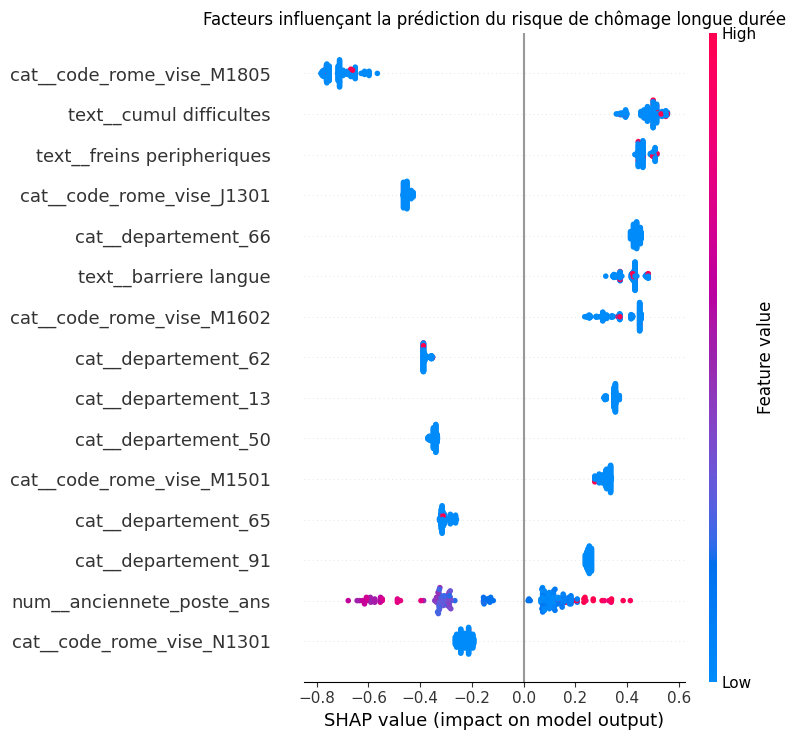

In [105]:
import matplotlib.pyplot as plt
if isinstance(shap_values, list):
    # Anciennes versions de SHAP :
    # une matrice par classe
    shap_values_class_2 = shap_values[2]

else:
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        # Versions récentes :
        # observations × variables × classes
        shap_values_class_2 = shap_array[:, :, 2]

    elif shap_array.ndim == 2:
        # Cas binaire ou sortie déjà limitée à une classe
        shap_values_class_2 = shap_array

    else:
        raise ValueError(
            f"Forme SHAP non reconnue : {shap_array.shape}"
        )
feature_names = (
    pipeline.named_steps["preprocess"]
    .get_feature_names_out()
)

shap.summary_plot(
    shap_values_class_2,
    X_transformed_numeric,
    feature_names=feature_names,
    max_display=15,
    show=False,
)

plt.title(
    "Facteurs influençant la prédiction du risque de chômage longue durée"
)

importance = np.abs(
    shap_values_class_2
).mean(axis=0)


plt.tight_layout()
plt.show()


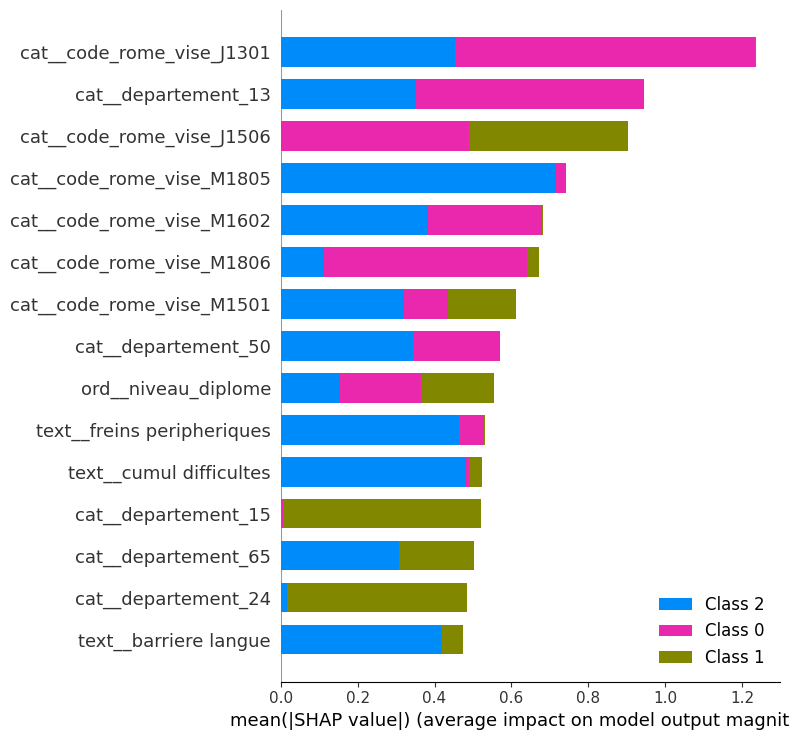

In [106]:
# 1. Extraction des sous-étapes du pipeline
preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["classifier"]

# 2. Transformation des données de l'échantillon
X_transformed = preprocessor.transform(X_sample)

# 3. Conversion propre en numpy array dense
if hasattr(X_transformed, "toarray"):
    X_transformed_numeric = X_transformed.toarray()
elif hasattr(X_transformed, "to_numpy"):
    X_transformed_numeric = X_transformed.to_numpy()
else:
    X_transformed_numeric = np.asarray(X_transformed)

X_transformed_numeric = X_transformed_numeric.astype(np.float64, copy=False)

# 4. Récupération sécurisée des noms de variables (Feature Names)
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    # Si le preprocessor lève NotFittedError ou AttributeError,
    # on génère des noms génériques basés sur le nombre exact de colonnes
    feature_names = [f"Feature_{i}" for i in range(X_transformed_numeric.shape[1])]

# 5. Création du DataFrame
X_transformed_df = pd.DataFrame(
    X_transformed_numeric, 
    columns=feature_names
)

# 6. Explicabilité SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_transformed_df)

# Graphique de synthèse standard
shap.summary_plot(
    shap_values, 
    X_transformed_df, 
    max_display=15, 
    show=True
)

**📝 Synthèse de l'analyse SHAP**

L'analyse SHAP valide la cohérence métier du modèle et confirme que les décisions reposent sur des critères explicables et légitimes.

**Prépondérance des freins à l'emploi (Variables textuelles)**
Les facteurs les plus contributifs issus du NLP (`synthese_entretien`) sont directement liés aux obstacles à la réinsertion :
* **`text__cumul difficultes`**, **`text__freins peripheriques`** et **`text__barriere langue`** augmentent significativement la probabilité d'affectation au Risque 2 (retour à l'emploi tardif).
* Ce constat confirme la très forte valeur ajoutée de la synthèse rédigée par le conseiller pour capter la réalité du profil.

**Impact du marché local et des secteurs d'activité**
* **Tension sectorielle (`code_rome_vise`)** : Des métiers spécifiques (ex. `J1301`, `M1805`) structurent fortement la classification, reflétant les disparités de recrutement selon les branches professionnelles.
* **Effet territorial (`departement`)** : L'impact des variables géographiques (ex. `departement_13`, `66`) traduit l'influence des dynamiques locales du marché du travail.

**Audit d'Équité & Conformité AI Act**
* **Absence de discrimination directe** : Les variables protégées (`age`, `nationalite_hors_ue`) ont été totalement exclues du scénario retenu et n'interviennent pas dans la décision.
* **Vigilance sur les proxys** : L'analyse SHAP révèle que les variables `departement` et `code_rome_vise` contribuent aux prédictions. Elles constituent des **proxys potentiels** de facteurs socio-économiques qu'il conviendra de surveiller en production.



### 7.2 Analyse des erreurs et stratégies de fallback

🎯 Identifier où le modèle échoue, et **concevoir le filet de sécurité** : que se passe-t-il quand le modèle a tort, ou qu'il ne sait pas ?

💡 Trois leviers de conception à documenter explicitement (la **surveillance** de ces seuils se traite en §9.4, pas ici) :

⚠️ Sans ces 3 éléments, ton modèle n'a pas de plan de fallback — il **n'est pas déployable en prod sur un usage à enjeu**. C'est un attendu C8 N3 (M6) et C7 N3 (M8). Le code ci-dessous analyse les erreurs résiduelles pour **informer** ces 3 choix (où placer le seuil, quels profils escalader).

In [107]:
# Le holdout ne sert qu'une fois, pour le chiffre final : régler le seuil dessus le contaminerait.
import sys
import json
from pathlib import Path

import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

CURRENT_DIR = Path.cwd().resolve()
SEARCH_ROOTS = []
for directory in (CURRENT_DIR, *CURRENT_DIR.parents):
    SEARCH_ROOTS.extend((directory, directory / "certification"))

CERTIFICATION_DIR = next(
    (
        directory
        for directory in SEARCH_ROOTS
        if (directory / "src" / "config.py").is_file()
        and (directory / "data" / "dataset_trajectoire_emploi.csv").is_file()
    ),
    None,
)
if CERTIFICATION_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser la racine certification depuis le répertoire courant."
    )

CERTIFICATION_SRC = str((CERTIFICATION_DIR / "src").resolve())
if CERTIFICATION_SRC in sys.path:
    sys.path.remove(CERTIFICATION_SRC)
sys.path.insert(0, CERTIFICATION_SRC)
for module_name in ("config", "train", "preprocess", "evaluation_utils"):
    sys.modules.pop(module_name, None)

from config import DATA_PATH, MODELS_DIR, RANDOM_STATE, REPORTS_DIR, TEST_SIZE
from train import fit_pipeline_with_text_fallback, load_scenario_dataset, split_train_holdout

MODEL_TYPE = "xgboost"
SCENARIO_NAME = "multimodal_ethique"
CONFIG_NAME = "best_class_2_ethique"
MODEL_PATH = MODELS_DIR / f"cisia_emploi_{MODEL_TYPE}_{SCENARIO_NAME}_{CONFIG_NAME}.joblib"

# --- Étape 1 : même split train/holdout que train.py ---
# Mêmes TEST_SIZE / RANDOM_STATE / stratification pour retrouver exactement le holdout du modèle.
X, y = load_scenario_dataset(data_path=DATA_PATH, scenario_name=SCENARIO_NAME)
y = y.astype(int)
X_train_full, X_holdout, y_train_full, y_holdout = split_train_holdout(
    X=X, y=y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
)

metadata = json.loads(MODEL_PATH.with_suffix(".json").read_text(encoding="utf-8"))
holdout_indices = metadata["dataset"]["test_indices"]
if set(X_holdout.index) != set(holdout_indices):
    raise ValueError("Le holdout recalculé ne correspond pas aux test_indices des métadonnées.")
print(f"Racine certification : {CERTIFICATION_DIR}")
print(f"Artefact chargé : {MODEL_PATH.resolve()}")
print(f"Holdout vérifié : identique aux métadonnées (n={len(X_holdout)})")

# --- Étape 2 : second découpage du train pour isoler un jeu de calibration ---
# Le modèle ne doit pas voir ces lignes à l'entraînement, sinon ses probabilités y seraient trop optimistes.
X_train_fit, X_calibration, y_train_fit, y_calibration = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20, stratify=y_train_full, random_state=RANDOM_STATE,
)
print(f"Train fit : n={len(X_train_fit)} | Calibration : n={len(X_calibration)} | Holdout : n={len(X_holdout)}")

# --- Étape 3 : même pipeline et mêmes hyperparamètres, entraîné sur X_train_fit uniquement ---
# Le modèle sauvegardé a vu tout X_train_full, dont X_calibration : on ne peut pas le réutiliser ici.
pipeline_fit, _ = fit_pipeline_with_text_fallback(
    model_type=MODEL_TYPE, scenario_name=SCENARIO_NAME, config_name=CONFIG_NAME,
    X_train=X_train_fit, y_train=y_train_fit,
)

# --- Étape 4 : calibration isotonique ajustée sur X_calibration ---
# Les probabilités brutes de XGBoost pondéré ne sont pas des fréquences fiables : on les calibre avant de fixer un seuil.
try:
    from sklearn.frozen import FrozenEstimator  # scikit-learn >= 1.6
    calibrated_model = CalibratedClassifierCV(FrozenEstimator(pipeline_fit), method="isotonic")
except ImportError:
    calibrated_model = CalibratedClassifierCV(pipeline_fit, method="isotonic", cv="prefit")
calibrated_model.fit(X_calibration, y_calibration)
print("Modèle calibré (isotonique) prêt.")

Racine certification : C:\Users\a895479\projet\certification
Artefact chargé : C:\Users\a895479\projet\certification\models\cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib
Holdout vérifié : identique aux métadonnées (n=500)
Train fit : n=1600 | Calibration : n=400 | Holdout : n=500
Modèle calibré (isotonique) prêt.


Calibration : n=400 | erreurs=138 | erreurs critiques 2→0=14


,count,mean,std,min,25%,50%,75%,max
erreur,,,,,,,,
False,262.0,0.721,0.148,0.362,0.649,0.730,0.834,1.000
True,138.0,0.563,0.162,0.340,0.417,0.512,0.702,0.918


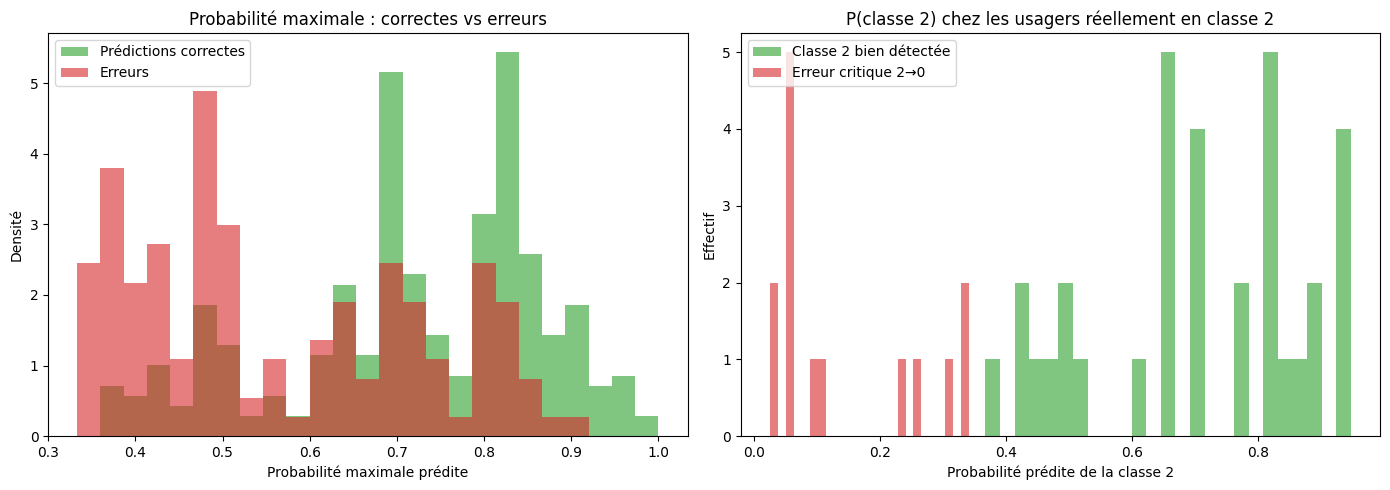

In [87]:
# Distribution des probabilités prédites sur les erreurs : détermination du seuil de rejet
# Étape 5 : toute l'analyse se fait sur X_calibration, jamais sur X_holdout.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

proba = calibrated_model.predict_proba(X_calibration)
classes = list(calibrated_model.classes_)
idx_c2 = classes.index(2)
y_pred_calibration = np.asarray(classes)[proba.argmax(axis=1)].astype(int)

analyse = pd.DataFrame({
    "réel": y_calibration.to_numpy(),
    "prédit": y_pred_calibration,
    "p_max": proba.max(axis=1),
    "p_classe_2": proba[:, idx_c2],
}, index=X_calibration.index)
analyse["erreur"] = analyse["réel"] != analyse["prédit"]
analyse["erreur_2_vers_0"] = (analyse["réel"] == 2) & (analyse["prédit"] == 0)

print(f"Calibration : n={len(analyse)} | erreurs={analyse['erreur'].sum()} "
      f"| erreurs critiques 2→0={analyse['erreur_2_vers_0'].sum()}")
display(analyse.groupby("erreur")["p_max"].describe().round(3))

# --- 1) Distribution de la confiance : prédictions correctes vs erreurs ---
bins = np.linspace(1 / len(classes), 1, 26)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(analyse.loc[~analyse["erreur"], "p_max"], bins=bins, alpha=0.6,
             density=True, label="Prédictions correctes", color="tab:green")
axes[0].hist(analyse.loc[analyse["erreur"], "p_max"], bins=bins, alpha=0.6,
             density=True, label="Erreurs", color="tab:red")
axes[0].set_title("Probabilité maximale : correctes vs erreurs")
axes[0].set_xlabel("Probabilité maximale prédite")
axes[0].set_ylabel("Densité")
axes[0].legend()

# Focus classe 2 : probabilité de la classe 2 chez les vrais classe 2
vrais_c2 = analyse[analyse["réel"] == 2]
axes[1].hist(vrais_c2.loc[vrais_c2["prédit"] == 2, "p_classe_2"], bins=25, alpha=0.6,
             label="Classe 2 bien détectée", color="tab:green")
axes[1].hist(vrais_c2.loc[vrais_c2["erreur_2_vers_0"], "p_classe_2"], bins=25, alpha=0.6,
             label="Erreur critique 2→0", color="tab:red")
axes[1].set_title("P(classe 2) chez les usagers réellement en classe 2")
axes[1].set_xlabel("Probabilité prédite de la classe 2")
axes[1].set_ylabel("Effectif")
axes[1].legend()
plt.tight_layout()
plt.show()

,seuil,taux_abstention,accuracy_acceptés,erreurs_captées,2→0_restantes,taux_2→0_restant
0,0.350000,1.0%,66.2%,2.9%,14,19.4%
1,0.400000,8.5%,69.7%,19.6%,11,15.3%
2,0.450000,15.5%,72.2%,31.9%,11,15.3%
3,0.500000,24.2%,75.9%,47.1%,8,11.1%
4,0.550000,30.0%,78.2%,55.8%,6,8.3%
5,0.600000,32.5%,78.9%,58.7%,6,8.3%
6,0.650000,39.5%,81.0%,66.7%,6,8.3%
7,0.700000,48.0%,80.3%,70.3%,6,8.3%
8,0.750000,64.5%,84.5%,84.1%,2,2.8%
9,0.800000,67.0%,85.6%,86.2%,1,1.4%


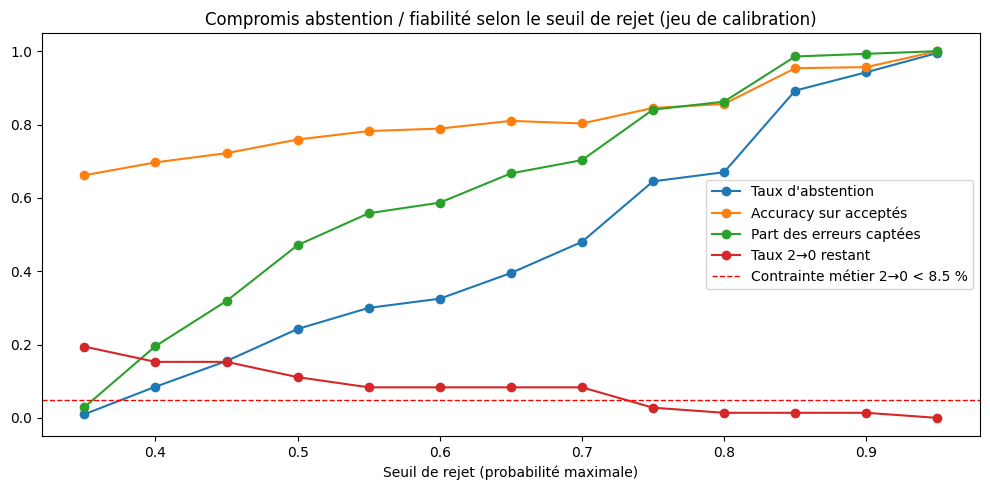

In [88]:
# --- 2) Balayage des seuils de rejet sur la probabilité maximale ---
# `analyse` provient de X_calibration : le seuil est choisi sans jamais regarder le holdout.
n_total = len(analyse)
n_c2 = int((analyse["réel"] == 2).sum())
resultats = []
for seuil in np.round(np.arange(0.35, 0.96, 0.05), 2):
    acceptes = analyse[analyse["p_max"] >= seuil]
    rejetes = analyse[analyse["p_max"] < seuil]
    resultats.append({
        "seuil": seuil,
        "taux_abstention": len(rejetes) / n_total,
        "accuracy_acceptés": (~acceptes["erreur"]).mean() if len(acceptes) else np.nan,
        "erreurs_captées": rejetes["erreur"].sum() / max(analyse["erreur"].sum(), 1),
        "2→0_restantes": int(acceptes["erreur_2_vers_0"].sum()),
        "taux_2→0_restant": acceptes["erreur_2_vers_0"].sum() / max(n_c2, 1),
    })
seuils_df = pd.DataFrame(resultats)
display(seuils_df.style.format({
    "taux_abstention": "{:.1%}", "accuracy_acceptés": "{:.1%}",
    "erreurs_captées": "{:.1%}", "taux_2→0_restant": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(seuils_df["seuil"], seuils_df["taux_abstention"], marker="o", label="Taux d'abstention")
ax.plot(seuils_df["seuil"], seuils_df["accuracy_acceptés"], marker="o", label="Accuracy sur acceptés")
ax.plot(seuils_df["seuil"], seuils_df["erreurs_captées"], marker="o", label="Part des erreurs captées")
ax.plot(seuils_df["seuil"], seuils_df["taux_2→0_restant"], marker="o", label="Taux 2→0 restant")
ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="Contrainte métier 2→0 < 8.5 %")
ax.set_xlabel("Seuil de rejet (probabilité maximale)")
ax.set_title("Compromis abstention / fiabilité selon le seuil de rejet (jeu de calibration)")
ax.legend()
plt.tight_layout()
plt.show()

In [89]:
# --- 3) Choix du seuil : couverture maximale sous contraintes ---
TAUX_2_VERS_0_MAX = 0.085      # # cible révisée : seuil de 5% inatteignable
ABSTENTION_MAX = 0.30         # capacité de revue humaine (à ajuster)

candidats = seuils_df[
    (seuils_df["taux_2→0_restant"] < TAUX_2_VERS_0_MAX)
    & (seuils_df["taux_abstention"] <= ABSTENTION_MAX)
]
if candidats.empty:
    print("Aucun seuil ne respecte les deux contraintes : "
          "revoir le budget d'abstention ou ajouter une règle spécifique à la classe 2.")
else:
    seuil_rejet = candidats.sort_values("seuil").iloc[0]
    print(f"Seuil de rejet retenu : p_max < {seuil_rejet['seuil']:.2f} → abstention")
    print(f"  Taux d'abstention      : {seuil_rejet['taux_abstention']:.1%}")
    print(f"  Accuracy sur acceptés  : {seuil_rejet['accuracy_acceptés']:.1%}")
    print(f"  Erreurs captées        : {seuil_rejet['erreurs_captées']:.1%}")
    print(f"  Taux 2→0 restant       : {seuil_rejet['taux_2→0_restant']:.1%}")

# --- 4) Règle complémentaire classe 2 : P(classe 2) intermédiaire alors que la prédiction est 0 ---
p2_erreurs_critiques = analyse.loc[analyse["erreur_2_vers_0"], "p_classe_2"]
if len(p2_erreurs_critiques):
    seuil_p2 = float(p2_erreurs_critiques.quantile(0.10))
    predits_0 = analyse[analyse["prédit"] == 0]
    escalades = predits_0[predits_0["p_classe_2"] >= seuil_p2]
    print(f"\nRègle classe 2 : prédiction 0 avec P(classe 2) ≥ {seuil_p2:.2f} → escalade humaine")
    print(f"  Erreurs 2→0 captées : {escalades['erreur_2_vers_0'].sum()} / {len(p2_erreurs_critiques)}")
    print(f"  Dossiers prédits 0 escaladés : {len(escalades)} / {len(predits_0)} "
          f"({len(escalades) / max(len(predits_0), 1):.1%})")

Seuil de rejet retenu : p_max < 0.55 → abstention
  Taux d'abstention      : 30.0%
  Accuracy sur acceptés  : 78.2%
  Erreurs captées        : 55.8%
  Taux 2→0 restant       : 8.3%

Règle classe 2 : prédiction 0 avec P(classe 2) ≥ 0.04 → escalade humaine
  Erreurs 2→0 captées : 12 / 14
  Dossiers prédits 0 escaladés : 102 / 154 (66.2%)


In [90]:
# --- Étape 6 : application UNIQUE du seuil retenu sur le vrai holdout ---
# ⚠️ Ne pas ré-exécuter cette cellule avec d'autres seuils : ajuster le seuil
# d'après ce résultat reviendrait à régler sur le holdout et invaliderait le chiffre final.
if candidats.empty:
    raise RuntimeError("Aucun seuil retenu sur le jeu de calibration : rien à confirmer sur le holdout.")

SEUIL_REJET = float(seuil_rejet["seuil"])
proba_holdout = calibrated_model.predict_proba(X_holdout)
final = pd.DataFrame({
    "réel": y_holdout.to_numpy(),
    "prédit": np.asarray(classes)[proba_holdout.argmax(axis=1)].astype(int),
    "p_max": proba_holdout.max(axis=1),
    "p_classe_2": proba_holdout[:, idx_c2],
}, index=X_holdout.index)
final["erreur_2_vers_0"] = (final["réel"] == 2) & (final["prédit"] == 0)
final["abstention"] = final["p_max"] < SEUIL_REJET

acceptes_final = final[~final["abstention"]]
n_c2_holdout = max(int((final["réel"] == 2).sum()), 1)

print(f"Résultat final sur le holdout (n={len(final)}) — seuil p_max < {SEUIL_REJET:.2f}")
print(f"  Taux d'abstention      : {final['abstention'].mean():.1%}")
print(f"  Accuracy sur acceptés  : {(acceptes_final['réel'] == acceptes_final['prédit']).mean():.1%}")
print(f"  Erreurs 2→0 restantes  : {int(acceptes_final['erreur_2_vers_0'].sum())}")
print(f"  Taux 2→0 restant       : {acceptes_final['erreur_2_vers_0'].sum() / n_c2_holdout:.1%}")

if "seuil_p2" in globals():
    escalade_c2 = (final["prédit"] == 0) & (final["p_classe_2"] >= seuil_p2)
    revue = final["abstention"] | escalade_c2
    restantes = final.loc[~revue, "erreur_2_vers_0"].sum()
    print(f"\nAvec la règle classe 2 (P(classe 2) ≥ {seuil_p2:.2f} si prédit 0) :")
    print(f"  Taux de revue humaine  : {revue.mean():.1%}")
    print(f"  Taux 2→0 restant       : {restantes / n_c2_holdout:.1%}")

Résultat final sur le holdout (n=500) — seuil p_max < 0.55
  Taux d'abstention      : 30.4%
  Accuracy sur acceptés  : 75.9%
  Erreurs 2→0 restantes  : 1
  Taux 2→0 restant       : 1.1%

Avec la règle classe 2 (P(classe 2) ≥ 0.04 si prédit 0) :
  Taux de revue humaine  : 41.6%
  Taux 2→0 restant       : 1.1%


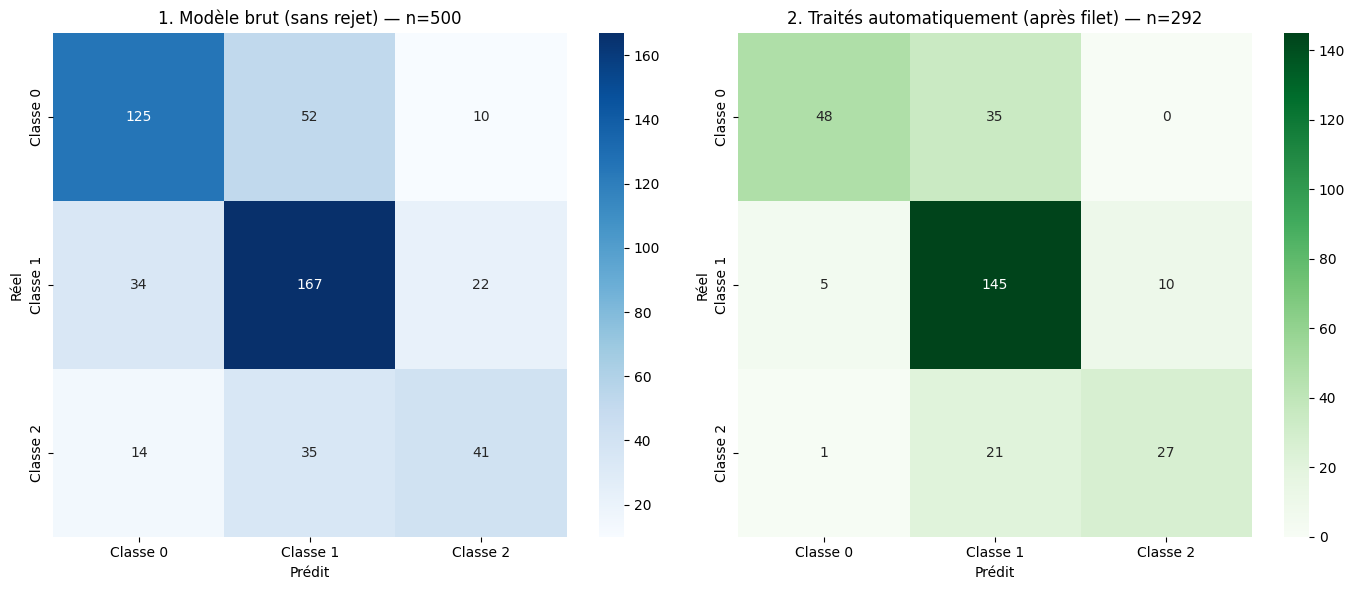


--- Synthèse des flux de décision sur le Holdout ---
Total dossiers holdout : 500
Traités automatiquement : 292 (58.4%)
Basculés en revue humaine : 208 (41.6%)


In [91]:
# --- Étape 7 : Génération et affichage des matrices de confusion (Holdout) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Vérification de la présence des variables requises
if "final" not in globals():
    raise NameError("Veuillez d'abord exécuter l'Étape 6 (création du DataFrame 'final' sur le holdout).")

# 1. Identification des classes
classes_uniques = sorted(final["réel"].unique())
noms_classes = [f"Classe {c}" for c in classes_uniques]

# 2. Matrice de confusion brute (sur tout le holdout)
cm_brute = confusion_matrix(final["réel"], final["prédit"], labels=classes_uniques)

# 3. Matrice de confusion après application du filet de sécurité (Rejet + Escalade)
s_p2 = seuil_p2 if "seuil_p2" in globals() else 0.04
revue_holdout = final["abstention"] | ((final["prédit"] == 0) & (final["p_classe_2"] >= s_p2))
acceptes_strict = final[~revue_holdout]

cm_acceptes = confusion_matrix(
    acceptes_strict["réel"], 
    acceptes_strict["prédit"], 
    labels=classes_uniques
)

# 4. Affichage graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_brute, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=noms_classes, yticklabels=noms_classes)
axes[0].set_title(f"1. Modèle brut (sans rejet) — n={len(final)}")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")

sns.heatmap(cm_acceptes, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=noms_classes, yticklabels=noms_classes)
axes[1].set_title(f"2. Traités automatiquement (après filet) — n={len(acceptes_strict)}")
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.show()

# 5. Synthèse des flux
print("\n--- Synthèse des flux de décision sur le Holdout ---")
print(f"Total dossiers holdout : {len(final)}")
print(f"Traités automatiquement : {len(acceptes_strict)} ({len(acceptes_strict)/len(final):.1%})")
print(f"Basculés en revue humaine : {revue_holdout.sum()} ({revue_holdout.mean():.1%})")

### 7.3 Message au client (langage métier)

*[2-3 paragraphes lisibles par un décideur non technique. Trois messages-clés à retenir.]*

1. **L'outil aide le conseiller à repérer les usagers à risque ; il ne décide pas à sa place.**
2. **Il réduit le risque de passer à côté d'un usager à risque de retour tardif, mais il se trompe encore sur environ un dossier sur quatre.**
3. **Sa mise en service suppose de faire relire environ 3 dossiers sur 10 et de suivre ses résultats dans la durée.**

**1. Une aide à l'orientation, pas une décision automatique**

Dès le premier entretien, l'outil estime si le retour à l'emploi d'un usager sera plutôt rapide, intermédiaire ou tardif (classes 0, 1 et 2). Il s'appuie sur des informations du dossier, notamment le diplôme, l'ancienneté, le métier visé, le département et la synthèse rédigée par le conseiller. 
Il fournit une recommandation accompagnée d'un niveau de confiance. Le conseiller reste seul décisionnaire : il peut suivre la recommandation ou s'en écarter, et chaque écart entre la recommandation de l'outil et la décision du conseiller devraient être enregistrés afin de vérifier que le contrôle humain reste effectif. L'outil est destiné à l'orientation ; il ne doit servir ni au contrôle, ni à la sanction, ni à la radiation.

**2. Ce que l'outil apporte, et ses limites**

La priorité est d'éviter qu'un usager à risque de retour tardif (classe 2) soit orienté vers un parcours sans accompagnement renforcé (classe 0). Nous avons testé un filet de sécurité : lorsque la confiance du modèle est insuffisante, le dossier est signalé au conseiller pour un examen approfondi. Résultats sur le jeu de test (500 dossiers, dont 90 à risque de retour tardif) :

| Sur le jeu de test | Filet recommandé (seuil de confiance seul) | Variante avec règle complémentaire |
|---|---|---|
| Dossiers signalés pour examen approfondi | 30 sur 100 | 42 sur 100 |
| Dossiers avec recommandation à confiance élevée | 70 sur 100 | 58 sur 100 |
| Usagers à risque de retour tardif classés « retour rapide » sans être signalés | **1 sur 90** (1,1 %, fourchette statistique de 0,2 % à 6,0 %) | 1 sur 90 |
| Recommandations à confiance élevée qui s'avèrent correctes | 76 % | non mesuré |

- **Ce que cela signifie** : sans filet, le modèle classait à tort 7 usagers à risque sur 90 en « retour rapide » (7,8 %, fourchette de 3,8 % à 15,2 %). Le filet ramène ce chiffre à 1 sur 90. Deux réserves s'imposent : les deux mesures portent sur deux versions légèrement différentes du modèle (l'une entraînée sur 2 000 dossiers, l'autre sur 1 600 puis calibrée), et leurs fourchettes se chevauchent. L'amélioration est compatible avec les données observées mais ne peut pas être considérée comme statistiquement démontrée à ce stade.
- **Ce que cela ne signifie pas** : parmi les recommandations à confiance élevée, environ une sur quatre (24 %) ne correspond pas à la trajectoire observée. L'outil n'est pas infaillible, et c'est pourquoi le conseiller garde la main sur toutes les décisions.
- **Pourquoi nous n'avons pas retenu la règle complémentaire** : elle fait passer la relecture de 30 % à 42 % des dossiers sans réduire le nombre d'erreurs critiques mesuré (1 dans les deux cas), et son seuil repose sur 14 erreurs seulement.

**3. Ce que cela implique pour l'organisation**

- **Charge de relecture** : environ 30 % des dossiers sont signalés. C'est notre hypothèse de capacité de revue, qui doit être confrontée à la réalité des équipes (nombre de conseillers, délais de relecture).
- **Avant toute mise en production** :
  - le filet de sécurité n'est pas encore intégré au service (API) : il faut l'y implémenter ;
  - les résultats reposent sur un jeu de test réduit (90 usagers à risque) : un pilote en conditions réelles est nécessaire pour les confirmer ;
  - les conseillers doivent être formés, et le taux de désaccord entre conseiller et outil doit être suivi pour vérifier que le contrôle humain est réel.
- **Ce que nous n'affirmons pas** : un gain de temps, une amélioration de la qualité de service ou une réduction des délais. Ces effets n'ont pas été mesurés à ce stade.

### 7.4 📝 Synthèse interprétation

*[Variables-clés, profils mal prédits, vigilance opérationnelle.]*

In [109]:
# 7.4 — Importance SHAP agrégée par variable d'origine (classe 2)
# Exécuter après la cellule qui définit `shap_values_class_2` et `feature_names` (§7.1).
# On somme les valeurs SHAP des modalités d'une même variable AVANT la valeur absolue :
# c'est l'importance de la variable, pas celle de chaque modalité isolée.
import numpy as np
import pandas as pd
from IPython.display import display

feature_names = np.asarray(feature_names)


def variable_origine(nom: str) -> str:
    if nom.startswith("text__"):
        return "synthese_entretien (TF-IDF)"
    for base in ("code_rome_vise", "departement", "est_allocataire"):
        if nom.startswith(f"cat__{base}"):
            return base
    return nom.split("__", 1)[-1]  # num__ / ord__ / autres


origine = np.array([variable_origine(n) for n in feature_names])
lignes = []
for variable in np.unique(origine):
    idx = np.where(origine == variable)[0]
    lignes.append({
        "variable": variable,
        "nb_colonnes": len(idx),
        "importance_shap_moy": np.abs(shap_values_class_2[:, idx].sum(axis=1)).mean(),
    })
importance_variables = (
    pd.DataFrame(lignes)
    .sort_values("importance_shap_moy", ascending=False)
    .reset_index(drop=True)
)
importance_variables["part"] = (
    importance_variables["importance_shap_moy"] / importance_variables["importance_shap_moy"].sum()
)
display(importance_variables.style.format({"importance_shap_moy": "{:.3f}", "part": "{:.1%}"}))

,variable,nb_colonnes,importance_shap_moy,part
0,synthese_entretien (TF-IDF),103,1.520,53.9%
1,code_rome_vise,50,0.769,27.2%
2,anciennete_poste_ans,1,0.240,8.5%
3,niveau_diplome,1,0.155,5.5%
4,departement,96,0.123,4.4%
5,est_allocataire,2,0.016,0.6%


L'analyse SHAP montre que le modèle s'appuie principalement sur deux sources d'information : le contenu de la synthèse d'entretien rédigée par le conseiller (53,9 % de l'importance totale) et le métier visé (`code_rome_vise`, 27,2 %). Les autres variables jouent un rôle plus limité : ancienneté du poste (8,5 %), niveau de diplôme (5,5 %), département (4,4 %) et statut allocataire (0,6 %).

Ces résultats suggèrent que les recommandations produites par le modèle reposent avant tout sur les informations qualitatives recueillies lors de l'entretien et sur le projet professionnel de l'usager. L'interprétation locale des prédictions confirme que le modèle ne s'appuie généralement pas sur une seule variable mais sur la combinaison de plusieurs facteurs cohérents avec les connaissances métier.

L'étude des erreurs montre que les confusions les plus fréquentes concernent les classes adjacentes (classes 1 et 2), ce qui traduit la difficulté à distinguer certaines situations intermédiaires. Les erreurs extrêmes consistant à classer un usager de classe 2 dans la catégorie 0 restent plus rares mais constituent le principal risque métier identifié.

Afin de limiter ce risque, un mécanisme d'abstention fondé sur le niveau de confiance doit etre mis en place. Après calibration des probabilités et application du seuil retenu (`p_max < 0,55`), environ 30 % des dossiers sont orientés vers une revue humaine. 
Sur le jeu holdout, cette stratégie permet de limiter les erreurs critiques de type 2→0 à une seule erreur observée sur 90 usagers réellement classés en catégorie 2 (1,1 %).

Plusieurs points de vigilance demeurent :

- le poids important de la variable `synthese_entretien` implique que la qualité et l'homogénéité de la rédaction des comptes rendus peuvent influencer les prédictions ;
- le texte libre n'a pas fait l'objet d'un audit détaillé des biais linguistiques ou des éventuels marqueurs indirects de caractéristiques sensibles ;
- malgré la suppression des variables sensibles (âge, nationalité hors UE), certaines variables comme le département ou le niveau de diplôme peuvent agir comme proxys indirects et doivent continuer à être surveillées ;
- les recommandations du modèle ne doivent jamais être utilisées comme une décision automatique et doivent toujours pouvoir être remises en cause par le conseiller.

Au regard de ces éléments, le modèle apparaît davantage comme un outil d'aide au repérage précoce des situations nécessitant un accompagnement renforcé que comme un système destiné à automatiser les décisions d'orientation.

---
## 8. Industrialisation

**Compétences** : C6 (implémenter le modèle), C7 (architecture cible)

🎯 Transformer le modèle en **service exploitable** : API, UI, conteneurs, tracking d'expériences.

> ⚠️ **Cette section ne contient PAS le code de l'API/UI.** Le code vit dans le **repo Git** associé.  
> Dans le notebook, on met uniquement :
> 1. **Description architecturale** (texte)
> 2. **1 schéma** d'architecture (Mermaid, draw.io export, ou image)
> 3. **Lien vers le repo Git** + dossiers concernés
> 4. **Captures d'écran clés** (UI, dashboard, OpenAPI Swagger, workflow CI/CD vert)
> 5. **Justifications des choix techniques** (pourquoi FastAPI plutôt que Flask, pourquoi MLflow plutôt que `experiments.md`, etc.)

⚠️ Attendus certif (présents dans le repo, **référencés** dans cette section du notebook) :  
- API FastAPI avec routes `/predict`, `/train`, `/health`  
- Validation Pydantic des entrées  
- Logging structuré (Loguru)  
- Tests pytest  
- Conteneurisation Docker  
- CI/CD GitHub Actions  
- Tracking MLflow

#### 8.1.1 Modèle servi

Le service d’inférence charge le pipeline suivant :

```text
services/model/models/cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib
```
**Caractéristiques du modèle**

| Propriété | Valeur |
|---|---|
| Nom du modèle | `cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique` |
| Version du modèle | `v1.0.0` |
| Scénario | `multimodal_ethique` |
| Configuration | `best_class_2_ethique` |
| Algorithme | XGBoost multiclasse |
| Version scikit-learn | `1.5.1` |
| Version XGBoost | `2.1.3` |


**Métadonnées et reproductibilité**

Chaque artefact `joblib` est accompagné d’un fichier JSON de métadonnées.

Ce fichier contient notamment :
- le nom du modèle ;
- la version du modèle ;
- le scénario d’entraînement ;
- la date d’entraînement ;
- les hyperparamètres retenus ;
- les variables utilisées par le pipeline ;
- les versions des principales bibliothèques ;
- l’empreinte SHA-256 du dataset ;
- les indices des observations du holdout ;
- les métriques d’évaluation ;
- les identifiants des runs MLflow associés ;
- les informations nécessaires à la reproduction de l’entraînement.

L’empreinte SHA-256 du dataset commence par :

```text
2b9cb8c8…
```

L’empreinte complète est conservée dans le fichier JSON de métadonnées.

Elle permet de vérifier que le dataset utilisé pour reproduire l’entraînement est strictement identique au dataset d’origine.


**Sélection du modèle au démarrage**

La variable d’environnement suivante détermine l’artefact chargé par le service :

```text
MODEL_ARTIFACT
```

Au démarrage de l’application, le service :

1. récupère la valeur de `MODEL_ARTIFACT` ;
2. localise l’artefact correspondant ;
3. charge le pipeline `joblib` ;
4. charge les métadonnées JSON associées ;
5. expose les informations du modèle chargé.

Le modèle effectivement servi est identifiable à partir :

- de l’endpoint `/info` ;
- de la métrique Prometheus `cisia_model_info`.

Ces deux mécanismes exposent notamment :

- le nom du modèle ;
- sa version ;
- le scénario associé ;
- l’artefact effectivement chargé.

Cela permet de vérifier que le modèle exécuté par le service correspond bien au modèle attendu lors du déploiement.

#### 8.1.2 Stratégie de persistance

Chaque modèle est enregistré sous la forme :
- d’un fichier `joblib` contenant le pipeline ;
- d’un fichier JSON contenant les métadonnées associées.

Un nouvel entraînement n'écrase pas le modèle stable.
Les artefacts sont distingués selon leur statut :

```text
cisia_emploi_candidate
cisia_emploi_promoted
modèle stable
```

**Cycle de vie d’un modèle**

```text
Réentraînement
      ↓
Création du modèle candidat
      ↓
Évaluation
      ↓
Comparaison avec le modèle en production
      ↓
Application du quality gate
      ↓
Décision de promotion ou de blocage
      ↓
Création de l’artefact promoted
      ↓
Sélection avec MODEL_ARTIFACT
      ↓
Déploiement
      ↓
Vérification du modèle réellement servi
```

Le modèle candidat ne devient pas automatiquement le modèle utilisé en production.
Il doit d’abord satisfaire les règles du quality gate.


**Modèle candidat**

Le processus de réentraînement produit un artefact candidat :

```text
cisia_emploi_candidate
```

Ce modèle est évalué et comparé au modèle actuellement servi.
La comparaison peut notamment porter sur :
- les performances globales ;
- les performances par classe ;
- les erreurs métier critiques ;
- le rappel de la classe 2 ;
- le taux d’erreurs `2 → 0` ;
- la calibration ;
- le taux d’abstention ;
- les indicateurs d’équité ;
- la stabilité des données ;
- la conformité de l’artefact ;
- la présence des métadonnées obligatoires.

Le candidat reste distinct du modèle stable tant que la décision de promotion n’est pas positive.

**Modèle promu**

Lorsque le candidat satisfait les règles du quality gate, il est copié vers un artefact promu :

```text
cisia_emploi_promoted
```

Le modèle promu peut ensuite être sélectionné au moyen de :

```text
MODEL_ARTIFACT
```

La promotion et le déploiement sont ainsi séparés :
- la **promotion** reconnaît qu’un modèle satisfait les critères définis ;
- le **déploiement** sélectionne l’artefact réellement chargé par le service.

Cette séparation permet de conserver un contrôle explicite sur la version mise en service.

**Quality gate**

Le quality gate détermine si le modèle candidat peut être promu.
La décision repose sur des règles mesurables, explicites et reproductibles.
Un candidat qui ne respecte pas les seuils définis est bloqué et ne remplace pas le modèle stable.

Le projet contient :
- un run nominal ayant validé le quality gate ;
- un run dégradé ayant été bloqué.

Cette distinction permet de démontrer que le mécanisme de contrôle fonctionne dans les deux situations :
- acceptation d’un modèle conforme ;
- refus d’un modèle dégradé.

**Rollback**

En cas de dégradation ou d’incident, le rollback consiste à rétablir l’artefact stable précédent dans la variable :

```text
MODEL_ARTIFACT
```

Le service est ensuite redémarré afin de charger l’artefact restauré.
Après le redémarrage, le retour à la version stable est contrôlé à l’aide :
- de l’endpoint `/info` ;
- de la métrique Prometheus `cisia_model_info` ;
- des logs de démarrage du service ;
- du nom présent dans le fichier de métadonnées ;
- de la version présente dans le fichier de métadonnées.

#### 8.1.3 Persistance des données d’exploitation

Les données d’exploitation sont enregistrées dans une base SQLite stockée dans le volume Docker :

```text
feedback_data
```

Elles comprennent :
- les entrées reçues par l’API ;
- les prédictions produites ;
- les probabilités associées à chaque classe ;
- la classe finalement retenue ;
- les décisions d’abstention ;
- les retours des conseillers ;
- les corrections métier ;
- les informations nécessaires au suivi du modèle.

Le volume Docker permet de conserver les données lors :
- du redémarrage du conteneur ;
- du remplacement du conteneur ;
- du redéploiement de l’application.

SQLite est adapté au périmètre actuel du prototype et à une volumétrie limitée.
Pour un déploiement multi-instance ou nécessitant davantage d’écritures concurrentes, une base de données serveur serait plus appropriée.

#### 8.1.3 Persistance de MLflow

MLflow est utilisé pour assurer le suivi :
- des expérimentations ;
- des entraînements ;
- des évaluations ;
- des comparaisons de scénarios ;
- des décisions de promotion ;
- des artefacts associés.

La persistance repose sur :

| Composant | Stockage |
|---|---|
| Backend MLflow | SQLite |
| Volume du backend | `mlflow_backend` |
| Artefacts MLflow | Volume `mlflow_artifacts` |

Le backend MLflow conserve notamment :
- les expériences ;
- les runs ;
- les paramètres ;
- les métriques ;
- les tags ;
- les liens avec les artefacts.

Le volume `mlflow_artifacts` conserve les fichiers associés aux runs :
- les modèles ;
- les graphiques ;
- les rapports ;
- les matrices de confusion ;
- les fichiers de métriques ;
- les fichiers nécessaires à l’analyse des résultats.

Cette configuration permet de conserver les informations MLflow entre les redémarrages des conteneurs.


**Registre de modèles**

Le modèle est enregistré dans le registre MLflow suivant :

```text
cisia-emploi
```

La version actuellement référencée est :

```text
Version 1
Alias : champion
```

L’alias `champion` identifie la version de référence dans le registre MLflow.

L’endpoint `/info` et la métrique `cisia_model_info` permettent de contrôler le dernier point, c’est-à-dire le modèle réellement servi.

Cette distinction évite de considérer automatiquement que le modèle portant l’alias `champion` est nécessairement celui qui est chargé dans l’application.


**Journal des décisions de promotion**

Les décisions de promotion sont enregistrées dans :

```text
reports/decisions_log.jsonl
```

Chaque ligne correspond à une décision de promotion, qui a la structure d'entrée suivante:
schema_version, decision_id (UUID), timestamp_utc

**decision**        : status (promoted/rejected), promote, reason

*extrait de reports/decisions_log.jsonl*
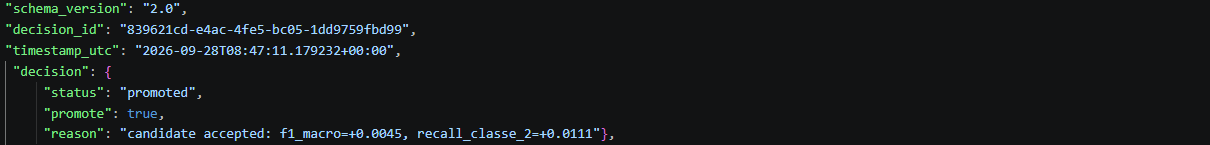

**candidate**       : model_name, model_version, model_type, artifact + artifact_sha256,
                  mlflow_experiment, mlflow_run_id, registry {name, alias, version, model_uri},
                  hyperparameters, training_rows, feedback_request_ids, feedbacks exclus

*extrait de reports/decisions_log.jsonl*
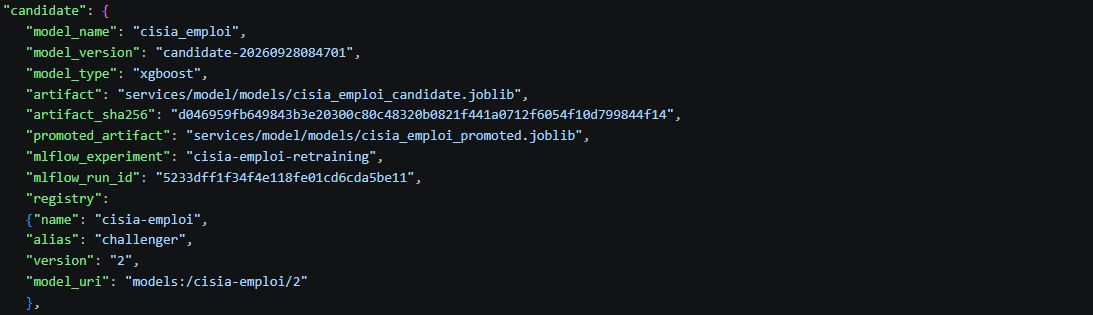

**production**      : model_name, model_version, scenario, config, artifact + artifact_sha256,
                  trained_on_dataset_sha256, mlflow_run_id, registry {name, alias, version}

*extrait de reports/decisions_log.jsonl*
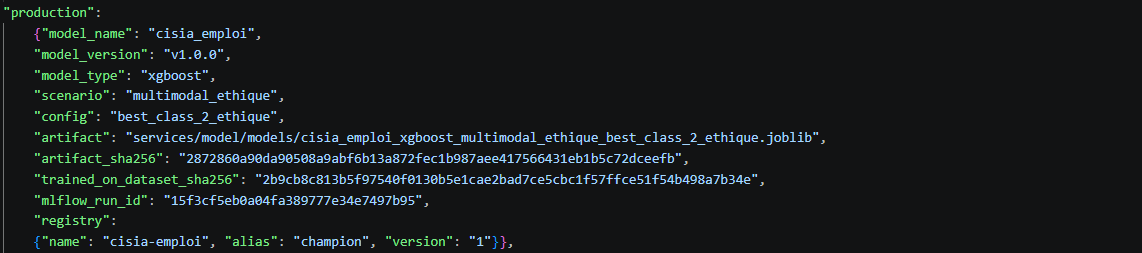

**data**            : reference_set + sha256, training_dataset + sha256, excluded_reference_rows

*extrait de reports/decisions_log.jsonl*
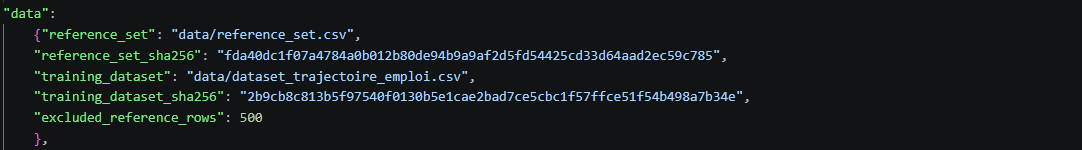

**metrics**         : candidate, production, delta_candidate_minus_production

*extrait de reports/decisions_log.jsonl*
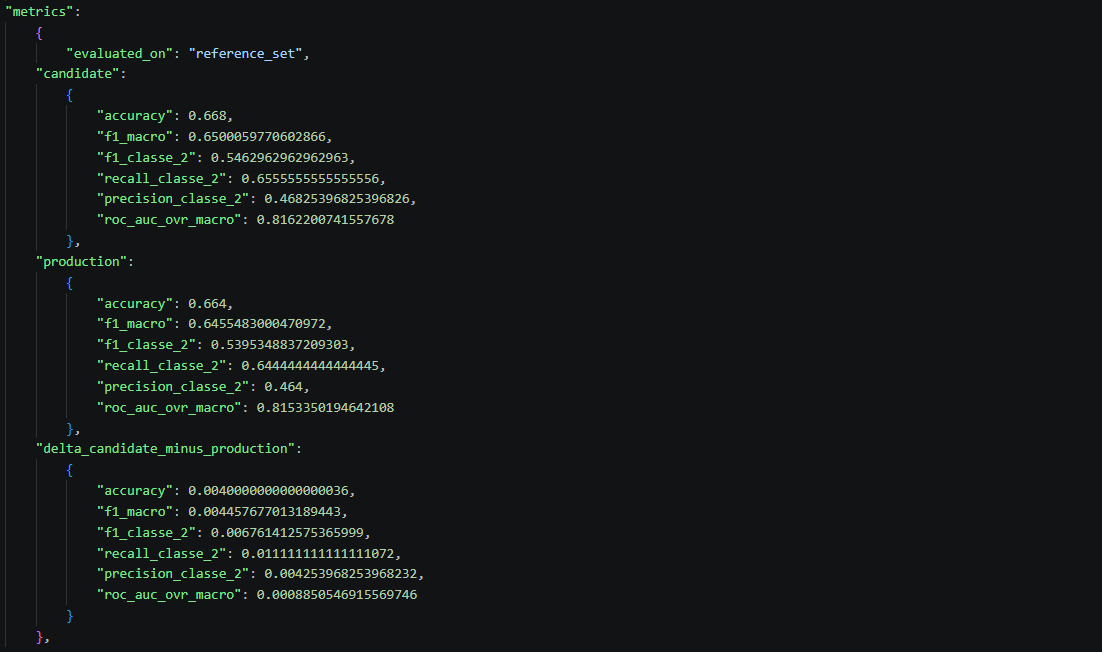
**quality_gate**    : status, passed, failed, rules[]  (rule, type, metric, value, comparison, threshold, status PASS/FAIL)

*extrait de reports/decisions_log.jsonl*
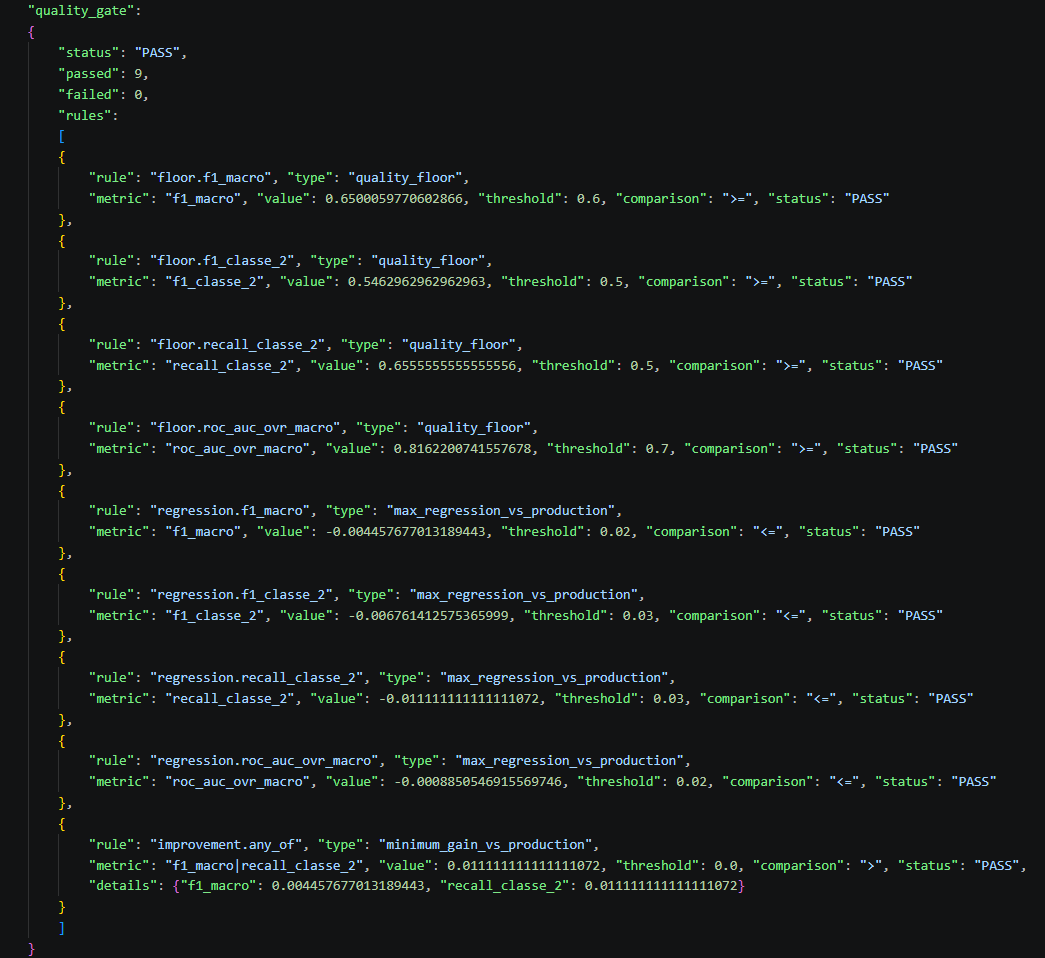

Ce journal permet de démontrer que la mise en production résulte d’une décision :
- mesurable ;
- explicable ;
- reproductible ;
- historisée ;
- auditable.

**Traçabilité MLflow**

L’interface MLflow est accessible à l’adresse suivante :

http://localhost:5000

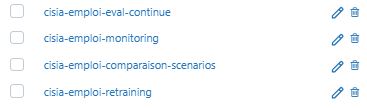


| Élément tracé | Expérience ou registre | Identifiant |
|---|---|---|
| Comparaison du modèle servi avec les autres scénarios | `cisia-emploi-comparaison-scenarios` | `0ea63cc417f84bb7ae4986387598263a` |
| Évaluation métier, calibration, équité et enregistrement du modèle | `cisia-emploi-monitoring` | `15f3cf5eb0a04fa389777e34e7497b95` |
| Modèle enregistré | `cisia-emploi`, version 1, alias `champion` | Lié au run `15f3cf5e…` |
| Quality gate nominal | `cisia-emploi-eval-continue` | `50baa55d…` |
| Quality gate dégradé et bloqué | `cisia-emploi-eval-continue` | `23629563…` |
| Dernier réentraînement et comparaison candidat contre production | `cisia-emploi-retraining` | `3c963de2631c4f3b870db7f2613848d6` |

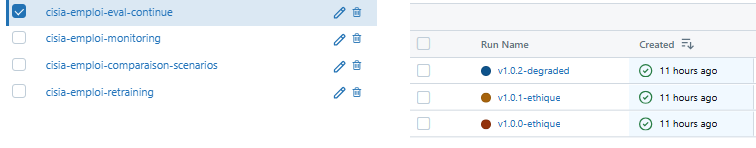
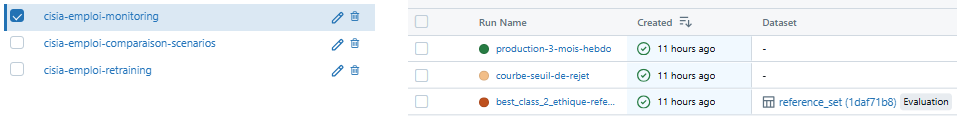
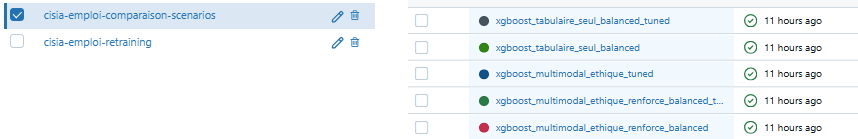
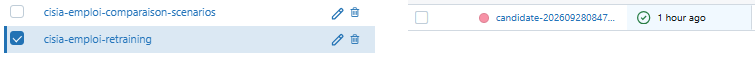

**Chaîne de traçabilité**

La chaîne de traçabilité peut être représentée de la manière suivante :

```text
Dataset identifié par son empreinte SHA-256
                    ↓
Indices du train, de la validation et du holdout conservés
                    ↓
Entraînement du pipeline complet
                    ↓
Paramètres, métriques et artefacts enregistrés dans MLflow
                    ↓
Création du modèle candidat
                    ↓
Comparaison avec le modèle de production
                    ↓
Application du quality gate
                    ↓
Décision enregistrée dans decisions_log.jsonl
                    ↓
Promotion éventuelle du candidat
                    ↓
Sélection de l’artefact par MODEL_ARTIFACT
                    ↓
Chargement du modèle par le service
                    ↓
Exposition de l’identité du modèle dans /info et Prometheus
                    ↓
Enregistrement des prédictions et des feedbacks
```

Cette chaîne permet de relier :
- les données d’entraînement ;
- le code et l’environnement ;
- le modèle entraîné ;
- les métriques obtenues ;
- la décision de promotion ;
- l’artefact déployé ;
- les prédictions produites en exploitation ;
- les feedbacks collectés après le déploiement.


**Observabilité du modèle servi**

L’observabilité permet de vérifier le fonctionnement du service et de suivre le comportement du modèle en exploitation.

L’endpoint `/info` et la métrique Prometheus `cisia_model_info` permettent d’identifier le modèle effectivement chargé.

Les métriques de surveillance peuvent être organisées selon plusieurs catégories.

**Surveillance du modèle**

| Type | Métrique | Seuil d’alerte | Source |
|---|---|---|---|
| Modèle | F1-score hebdomadaire | Inférieur à la baseline de plus de `0,05` | Logs de l’API |
| Données | PSI des variables clés | Supérieur à `0,2` | Batch journalier |
| Système | Latence p95 | Supérieure à `500 ms` | Prometheus |

D’autres métriques peuvent être suivies :

- taux de prédictions par classe ;
- rappel de la classe 2 ;
- nombre d’erreurs `2 → 0` ;
- taux d’erreurs `2 → 0` ;
- taux d’abstention ;
- accuracy sur les prédictions acceptées ;
- distribution de la probabilité maximale ;
- fréquence des corrections par les conseillers ;
- taux d’erreur du service ;
- volume de prédictions ;
- proportion de valeurs manquantes ;
- apparition de catégories inconnues.

**Synthèse**

Le dispositif mis en place couvre les principales dimensions d’une démarche MLOps :

- **reproductibilité**, grâce aux métadonnées, au hash du dataset et aux indices du holdout ;
- **traçabilité**, grâce aux runs MLflow, au registre et au journal des décisions ;
- **maîtrise du risque**, grâce au quality gate ;
- **séparation des responsabilités**, grâce aux statuts `candidate`, `promoted` et stable ;
- **réversibilité**, grâce à la sélection explicite de l’artefact avec `MODEL_ARTIFACT` ;
- **observabilité**, grâce à `/info`, à Prometheus et aux métriques de suivi ;
- **persistance**, grâce aux volumes Docker et au stockage sur l’hôte ;

Le principe central est qu’un modèle réentraîné n’est jamais automatiquement mis en production.

Il est d’abord :

1. identifié ;
2. évalué ;
3. comparé au modèle actuellement servi ;
4. soumis à un quality gate ;
5. promu uniquement si les critères sont respectés ;
6. sélectionné explicitement pour le déploiement ;
7. contrôlé après son chargement par le service ;
8. surveillé pendant son exploitation.

> **Message clé :** le système ne se limite pas à produire un modèle performant. Il permet également de savoir quel modèle est utilisé, comment il a été entraîné, sur quelles données il a été évalué, pourquoi il a été promu, comment il est surveillé et comment revenir à une version stable en cas de dégradation.

### 8.2 API de service

**Repo associé** : `<lien GitHub>` — dossier `api/`
*[Inclure ici 1 capture Swagger ou un schéma de l'API.]*

```mermaid
flowchart LR
    Client["Navigateur"]
    Frontend["Frontend Nginx :8088"]
    Backend["Backend FastAPI :8001"]
    Model["Model FastAPI :8000"]
    Registry["Référentiel usagers<br/>(optionnel)"]
    DB[("SQLite<br/>prédictions et feedbacks")]
    Prometheus["Prometheus :9090"]
    Grafana["Grafana :3001"]

    Client -->|"GET /"| Frontend
    Client -->|"POST /api/score<br/>GET /api/history<br/>POST /api/feedback"| Frontend
    Frontend -->|"Proxy /api/* vers le backend"| Backend

    Backend -->|"POST /predict"| Model
    Backend -.->|"GET /users/{usager_id}<br/>si configuré"| Registry
    Backend -->|"Enregistre prédictions et feedbacks"| DB
    Backend -.->|"POST /train<br/>proxy contrôlé"| Model

    Model -->|"Tracking lors d'un entraînement autorisé"| MLflow["MLflow :5000"]

    Prometheus -->|"scrape /metrics"| Backend
    Prometheus -->|"scrape /metrics"| Model
    Grafana -->|"requêtes"| Prometheus

    Backend -.->|"GET /health"| Ops["Healthchecks"]
    Model -.->|"GET /health et /info"| Ops
```

Le navigateur appelle le frontend Nginx (port `8088`), qui transmet les requêtes `/api/*` au backend. Le backend appelle ensuite le service model en interne. Les deux services FastAPI exposent une documentation Swagger sur `/docs`. Les routes `/metrics` et `/drift-metrics` n'y apparaissent pas, car elles sont exclues du schéma OpenAPI.

| Route | Méthode | Service | Rôle | Validation / sécurité |
|---|---|---|---|---|
| `/health` | GET | model / backend | Vérifier la santé du service | Model : `503` si l'artefact n'est pas chargé. Backend : liveness seule, sans interroger le model |
| `/info` | GET | model | Retourner le nom, la version, le scénario, les métriques et la provenance du modèle | Lecture des métadonnées JSON de l'artefact chargé |
| `/predict` | POST | model | Effectuer une prédiction unitaire | Schéma Pydantic : diplôme parmi les valeurs autorisées, ancienneté ≥ 0. Réponse : classe 0, 1 ou 2 et trois probabilités. `500` si la prédiction échoue |
| `/score` | POST | backend | Orchestrer la requête du frontend vers le model et enregistrer la prédiction | Pydantic, propagation de `request_id`, `usager_id`, `session_id`. `503` si le model est injoignable, `502` si le model répond en erreur |
| `/history` | GET | backend | Consulter les inférences d'une session ou d'un usager, avec les entrées saisies et le feedback éventuel | Filtres `session_id` / `usager_id`, limite 1-200 |
| `/feedback` | POST | backend | Enregistrer le résultat réel observé par le conseiller | `request_id` connu (`404`), prédiction cohérente et pas d'annotation contradictoire (`409`), `true_label` entre 0 et 2 (`422`), rejeu identique idempotent |
| `/feedback/count` | GET | backend | Compter les feedbacks, au total et non encore consommés, pour déclencher le retraining | Lecture SQLite |
| `/train` | POST | model / backend | Réentraînement contrôlé, pour les tests ou un environnement autorisé | Model : Pydantic, token `X-Train-Token` (`403` si invalide et `TRAIN_API_TOKEN` défini), `ALLOW_DIRECT_TRAIN=false` par défaut (`409`). Backend : proxy qui transmet le token, et renvoie `503` si le model est injoignable ou `502` si le model est en erreur |
| `/metrics` | GET | model / backend | Exposer les métriques Prometheus | Format Prometheus, hors Swagger |
| `/drift-metrics` | GET | backend | Publier le dernier rapport de drift batch | Format Prometheus, fichier défini par `DRIFT_METRICS_FILE` (par défaut `/app/reports/drift.prom`), hors Swagger |

Les erreurs:
| Code | Description | Routes / cas |
|---|---|---|
| **403 Forbidden** | Jeton d’entraînement absent ou invalide lorsque l’authentification est configurée. | Modèle : `POST /train` |
| **404 Not Found** | Le `request_id` transmis ne correspond à aucune prédiction enregistrée. | Backend : `POST /feedback` |
| **409 Conflict** | Entraînement direct désactivé, ou feedback déjà enregistré avec une étiquette différente. | Modèle : `POST /train`; backend : `POST /feedback` |
| **422 Unprocessable Entity** | Corps ou paramètres invalides : ancienneté négative, âge hors de `[16, 100]`, diplôme hors liste, `usager_id` vide, `true_label` hors de `[0, 2]`, `limit` hors de `[1, 200]`, ou moins de 10 dossiers pour un entraînement. | Modèle : `POST /predict`, `POST /train`; backend : `POST /score`, `POST /feedback`, `POST /train`, `GET /history` |
| **500 Internal Server Error** | Échec interne pendant la prédiction ou pendant l’entraînement du modèle. | Modèle : `POST /predict`, `POST /train` |
| **502 Bad Gateway** | Le backend ne peut pas exploiter la réponse du modèle : celui-ci répond en erreur, renvoie un JSON invalide ou une réponse incompatible avec le schéma attendu. | Backend : `POST /score`, `POST /train` |
| **503 Service Unavailable** | Dépendance indisponible : modèle non chargé ou inaccessible, ou référentiel usagers indisponible / usager inconnu. | Modèle : `GET /health`; backend : `POST /score`, `POST /train` |

Aucun `400 Bad Request` n’est explicitement renvoyé par ces routes : les entrées rejetées par la validation Pydantic renvoient `422`.

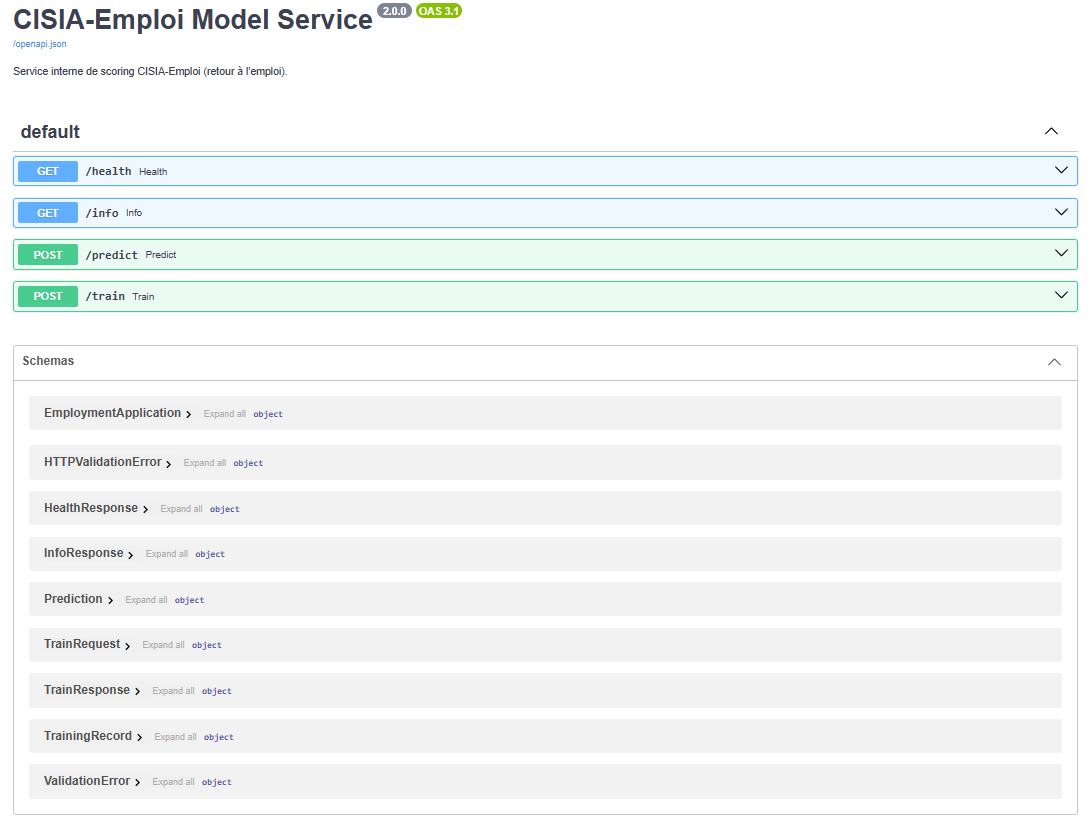

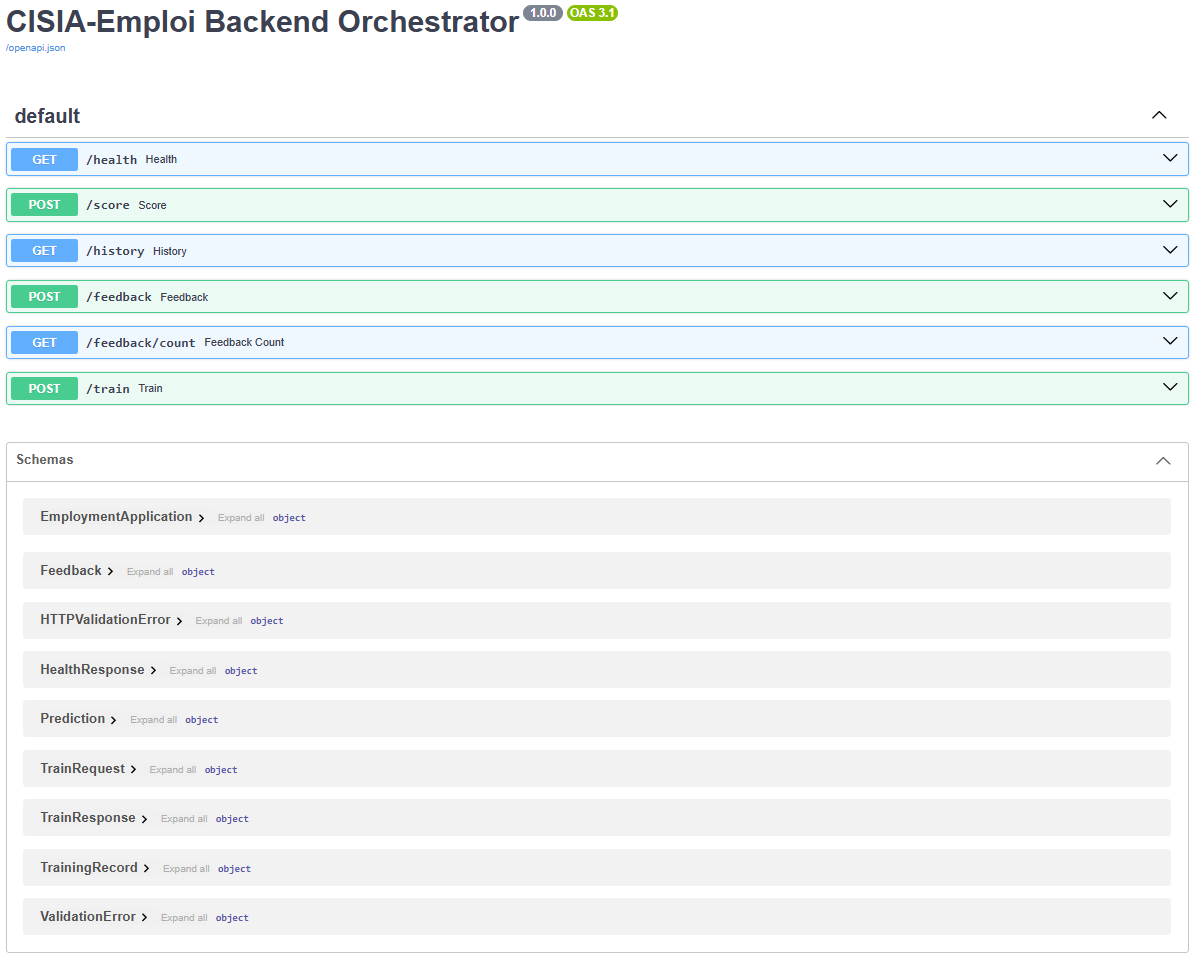

### 8.3 Interface utilisateur

*[Streamlit / Gradio / autre. Capture dans `docs/`.]*

Cette page est un formulaire intitulé « Orientation vers le retour à l'emploi », destiné à évaluer le délai probable de retour à l'emploi d'un usager.
L'interface HTML permet au conseiller de renseigner l'identifiant usager, les variables de situation ainsi que la synthèse d'entretien, puis d'appuyer sur le bouton « Évaluer le retour à l'emploi ». 
Un message affiche alors la classe prédite, les probabilités, la version du modèle et le REQ-ID

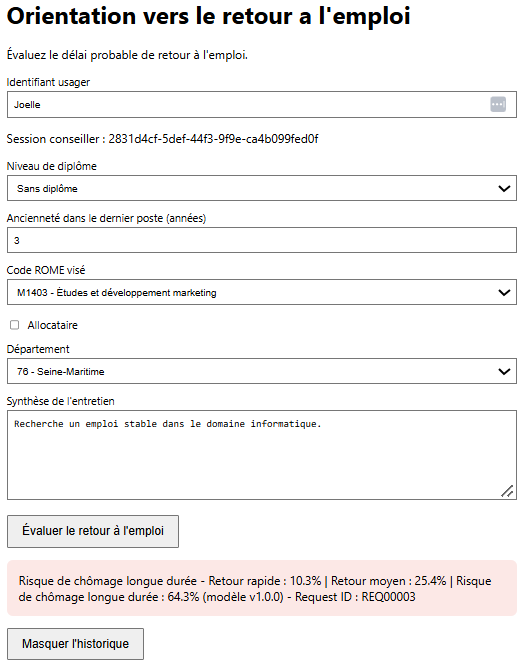

Après chaque scoring, l'interface recharge l'historique de la session avec `GET /api/history?session_id=...`.

Sur la même page, le conseiller peut consulter l'historique horodaté de sa session ou de toutes les sessions.

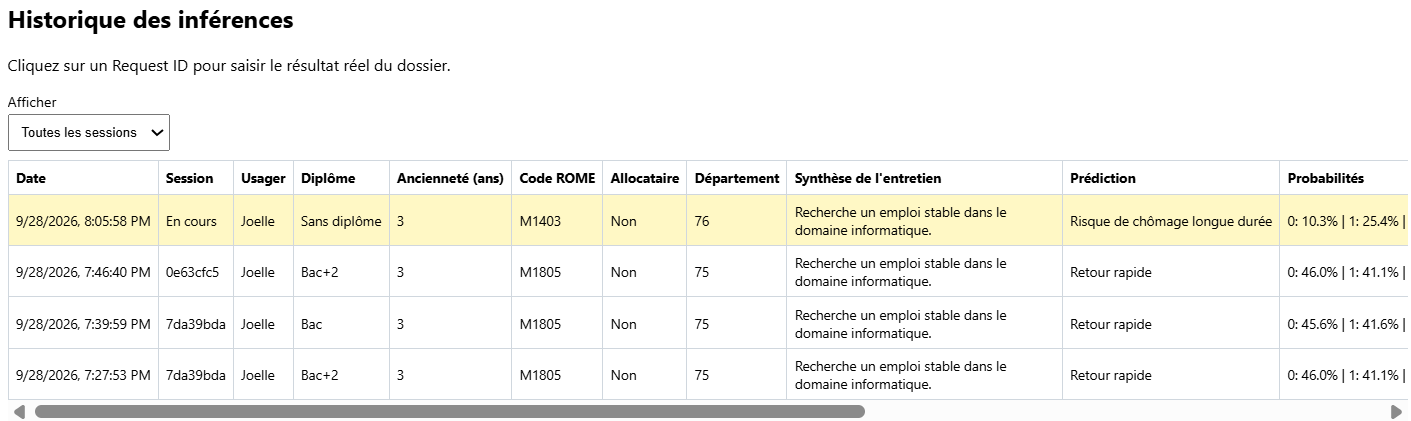

Il pourra aussi, en cliquant sur le REQ-ID dans l'historique, enregistrer le résultat réel et un commentaire via /api/feedback. Une fenêtre pop-up apparaîtra alors, permettant de renseigner le feedback du conseiller.
    
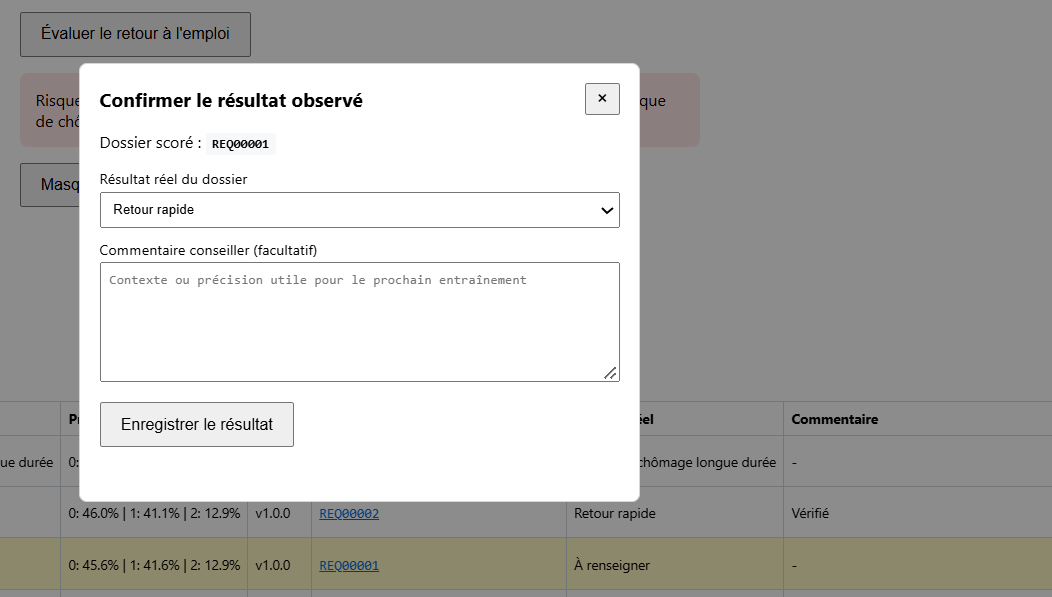

### 8.4 Schéma d'architecture

*[1 schéma simple : sources données → préprocessing → modèle → API → UI → monitoring.  
Tu peux utiliser un bloc Mermaid (rendu natif sur GitHub et Jupyter récents) :]*



```mermaid
flowchart TB
    conseiller["Conseiller"] --> navigateur["Navigateur"]

    subgraph production["Application en production - Docker Compose"]
        frontend["Frontend statique<br/>Nginx :80 dans le conteneur<br/>localhost:8088"]
        backend["Backend FastAPI<br/>:8001<br/>/score · /feedback · /history"]
        ledger[("SQLite persistant<br/>prédictions et retours")]
        model["Service modèle FastAPI<br/>:8000<br/>/predict · /metrics"]
        artifact[("Pipeline entraîné<br/>fichier .joblib + métadonnées")]

        navigateur --> frontend
        frontend -->|"/api/*, reverse proxy"| backend
        backend -->|"/predict, appel interne"| model
        model -->|"classe, probabilités, version"| backend
        backend -->|"résultat de scoring"| frontend
        backend -->|"journalise les prédictions<br/>et les retours validés"| ledger
        ledger -->|"/history"| backend
        artifact -->|"chargé au démarrage"| model

        userRegistry["Référentiel usagers<br/>optionnel"]
        backend -.->|"vérification de l'usager<br/>si USER_REGISTRY_URL configurée"| userRegistry
    end

    subgraph retraining["Réentraînement - lancement optionnel"]
        trigger["Lancement du retrainer<br/>profil Compose ou script"]
        trainingData[("Dataset historique<br/>+ retours étiquetés")]
        reference[("Jeu de référence figé")]
        candidate["Entraînement du candidat<br/>prétraitement + XGBoost"]
        gate{"Évaluation comparative<br/>et seuils de promotion"}
        candidateArtifact[("Artefact candidat")]
        promotedArtifact[("Artefact promu")]
        decisionLog["Journal de décision"]

        trigger -->|"lit les retours non consommés"| ledger
        trainingData --> candidate
        candidate --> gate
        reference -->|"évalue candidat et production"| gate
        gate -->|"conserve le candidat"| candidateArtifact
        gate -->|"si les seuils passent"| promotedArtifact
        gate --> decisionLog
    end

    subgraph tracking["Suivi des expériences"]
        mlflow["MLflow :5000<br/>tracking et registre de modèles"]
        mlflowStore[("Volumes persistants<br/>backend SQLite et artefacts MLflow")]
        mlflow --> mlflowStore
    end

    candidate -->|"paramètres, métriques,<br/>candidat enregistré"| mlflow
    trigger -->|"journalise le run"| mlflow

    deploy["Déploiement explicite<br/>configuration MODEL_ARTIFACT<br/>puis redémarrage du service modèle"]
    promotedArtifact --> deploy
    deploy -.->|"charge le modèle promu"| model

    subgraph monitoring["Monitoring"]
        prometheus["Prometheus :9090"]
        grafana["Grafana :3001"]
        driftJob["Analyse batch du drift"]
        driftFile[("reports/drift.prom")]

        prometheus -->|"requêtes de visualisation"| grafana
        driftJob -->|"génère le rapport"| driftFile
    end

    prometheus -->|"scrape /metrics"| model
    prometheus -->|"scrape /metrics"| backend
    driftFile -->|"servi par /drift-metrics"| backend
    prometheus -->|"scrape /drift-metrics"| backend

### 8.5 Conteneurisation & CI/CD


**Pipeline complet réussi : lint, tests, entraînement, déploiement**

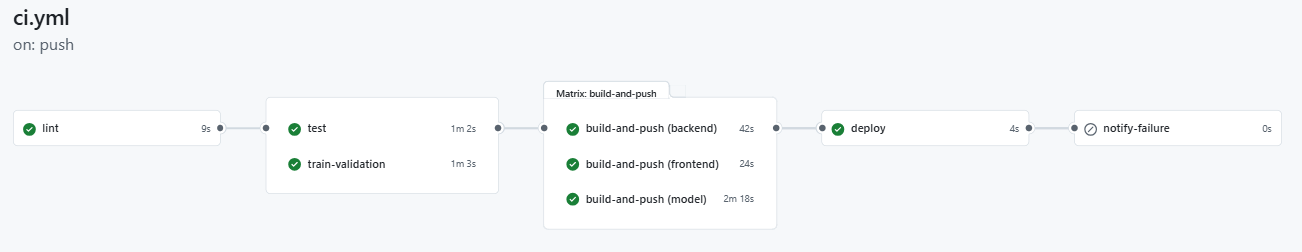

**Tester un échec de modèle dégradé, avec notification via un canal Discord (Quality Gate)**

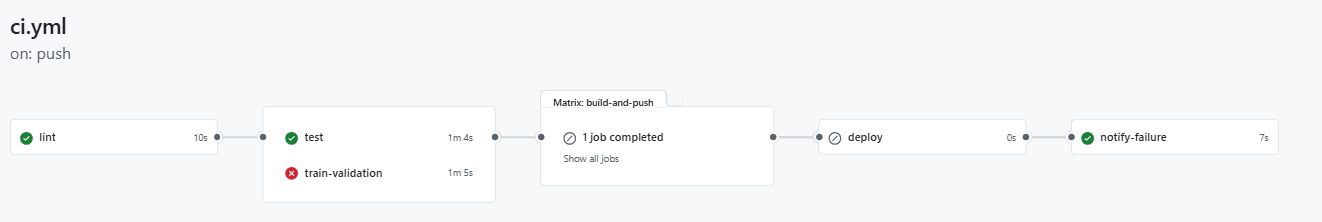

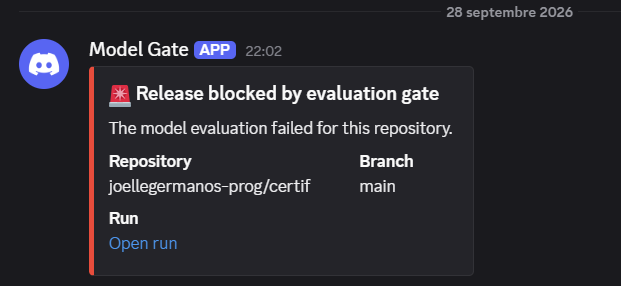

lien vers le run github: https://github.com/joellegermanos-prog/certif/actions/runs/36477045394

>*Alertes en production : le webhook Discord couvre les échecs CI. Il ne constitue pas à lui seul une alerte sur les incidents runtime ou les seuils de drift; ces alertes et leur prise en charge restent à préciser.*

**Déclencheurs (`on:`)**

- **`workflow_dispatch`** : lancement manuel.
- **`push`** : vers `main` ou vers un tag `v*`.
- **`pull_request`** : vers `main`.

**Chaîne des jobs**

**1. `lint`**
Installe Ruff et vérifie `services`, `scripts`, `tests`.

**2. `test` *(après `lint`)***
Installe les dépendances model + backend, puis lance :
- les tests API du modèle (santé, prédiction valide/invalide, `/metrics`) ;
- les tests API du backend (`/score`, validation du nombre minimal d'enregistrements).

**3. `train-validation` *(après `lint`, en parallèle de `test`)***
Installe les dépendances d'entraînement et d'évaluation, puis exécute dans l'ordre :
1. tests d'entraînement (seuil minimal, token invalide, run MLflow) ;
2. test de contrat du modèle ;
3. tests d'évaluation ;
4. **quality gate** `scripts/evaluate_model.py --release-tag`.

Le résultat est capturé dans `evaluation-result.json` (`set -o pipefail` pour ne pas masquer un échec derrière `tee`) et publié dans le résumé du run (`GITHUB_STEP_SUMMARY`), visible dans tous les cas (`if: always()`).

**4. `build-and-push` *(après `test` ET `train-validation`)***
Job matriciel (`fail-fast: false`) qui build en parallèle les trois services : `model`, `backend`, `frontend`. Pour chacun :
- calcule le nom d'image en minuscule (`ghcr.io/<repo>/<service>`) ;
- se connecte à GHCR uniquement sur push vers `main` ou tag `v*` ;
- génère les tags via `docker/metadata-action` (SHA, branche, tag, `latest` conditionnel) ;
- build et push (le push n'a lieu que sur push vers `main` ou tag `v*` — sur une PR, l'image est construite mais pas publiée).

**5. `deploy` *(après `build-and-push`, uniquement sur push vers `main`)***
Se connecte en SSH via `appleboy/ssh-action`, se logue à GHCR sur le serveur cible, tire les nouvelles images (`docker compose pull`) et redémarre les conteneurs `model`, `backend`, `frontend` (`up -d --no-build --force-recreate`), puis affiche leur état. Ne s'exécute que si `DEPLOY_HOST` est configuré.

**6. `notify-failure` *(après tous les jobs précédents)***
S'exécute toujours (`always()`) mais seulement si l'un des six jobs précédents (`lint`, `test`, `train-validation`, `build-and-push`, `deploy`) a échoué. Valide d'abord le format du webhook Discord, puis envoie une alerte (embed rouge) avec dépôt, branche et lien vers le run.

**Logique d'exécution selon le contexte**

| Événement | lint / test / train-validation | build-and-push | push image | deploy |
|---|---|---|---|---|
| PR vers `main` | ✅ | ✅ (build) | ❌ | ❌ |
| push vers `main` | ✅ | ✅ | ✅ | ✅ |
| push tag `v*` | ✅ | ✅ | ✅ | ❌ (skipped, ref ≠ main) |


### 8.6 📝 Synthèse industrialisation

*[Pile retenue, choix d'architecture, points encore ouverts.]*

**Pile technique retenue**

| Composant | Choix | Rôle |
|---|---|---|
| Interface conseiller | Nginx, exposé sur `localhost:8088` | Sert l’interface statique et relaie les appels `/api/` vers le backend. |
| Backend | FastAPI, port `8001` | Orchestre le scoring; gère `/score`, `/feedback`, `/feedback/count`, `/history`, `/health`, `/metrics` et `/drift-metrics`. |
| Service modèle | FastAPI, port `8000` | Charge le modèle et ses métadonnées au démarrage; expose `/predict`, `/train`, `/health`, `/info` et `/metrics`. |
| Validation des entrées | Pydantic | Valide les requêtes côté API. Les schémas des deux services doivent rester cohérents et sont contrôlés par les tests de contrat. |
| Préparation des données | Fonctions du module de prétraitement du modèle | `create_features()` et le préprocesseur sont utilisés par l’inférence et les scripts d’entraînement pour limiter les écarts entre ces étapes. |
| Modèle | XGBoost multiclasses | Produit une classe parmi `0`, `1` et `2`, avec les probabilités associées. Le service charge un artefact `.joblib` accompagné de ses métadonnées JSON. |
| Historique et feedbacks | SQLite, volume Docker persistant | Conserve les prédictions et les retours conseillers, liés par un `request_id`. |
| Suivi des expériences | MLflow | Trace les runs, paramètres, métriques et artefacts; son registre de modèles suit notamment les candidats. |
| Registre d’images | GitHub Container Registry (GHCR) | Stocke les images Docker `model`, `backend` et `frontend`. À distinguer du registre de modèles MLflow. |
| CI/CD | GitHub Actions | Exécute Ruff, les tests ciblés, le test de contrat et l’évaluation qualité, puis construit les images en matrice. Les images sont publiées sur GHCR sur `main` ou lors d’un tag `v*`; le déploiement distant concerne `main` si les secrets sont configurés. |
| Monitoring | Prometheus et Grafana | Prometheus collecte les métriques du backend et du modèle; Grafana les visualise. Le drift est calculé par batch puis exposé au format Prometheus (§9.) |


**Choix d’architecture**

- **Séparation des responsabilités** : le navigateur appelle le backend via le reverse proxy Nginx. Le backend orchestre la requête et appelle le service modèle par HTTP; il ne charge pas directement le pipeline XGBoost.
- **Validation et prétraitement cohérents** : Pydantic contrôle le format des entrées. Les transformations métier sont centralisées dans le prétraitement du modèle et réutilisées dans les parcours d’inférence et d’entraînement.
- **Traçabilité des prédictions** : le backend enregistre la prédiction, les probabilités, la version du modèle et les informations nécessaires à l’historique. Le feedback est rattaché au `request_id`; une annotation inconnue ou contradictoire est rejetée.
- **Promotion contrôlée** : le réentraînement crée un candidat distinct du modèle servi. Il est comparé au modèle de production sur un jeu de référence figé; la promotion produit un artefact, mais son activation dans l’API modèle reste une étape de déploiement.
- **Barrière qualité dans la CI** : les tests et le quality gate d’évaluation doivent réussir avant la construction des images. Une dégradation au regard des seuils bloque la suite de la chaîne.
- **Publication conditionnelle** : la matrice construit une image par service. Les pull requests vérifient le build sans publier; les pushes admissibles publient les images sur GHCR. Le déploiement on-prem est conditionné à la configuration des secrets requis.
- **Observabilité séparée du contrôle de disponibilité** : `/health` et les healthchecks Docker vérifient l’état des services. Prometheus collecte les métriques opérationnelles et métier; Grafana les présente. L’analyse de drift est batch et dépend de la génération du rapport correspondant.

## 9. Suivi en production & amélioration continue

### 9.1 Métriques à surveiller


Le tableau suit une progression :

préventive → détective → opérationnelle :

- **Release :** empêcher un mauvais modèle d'entrer en production.
- **Risque métier :** surveiller l'impact réel, directement lié à la performance du modèle et la priorité de la classe 2.
- **Dérives :** signaux précoces (sans labels) puis confirmation (avec labels).
- **Système :** garantir que le service fonctionne, indépendamment du modèle.

| Axe | Métrique et fenêtre | Seuil d’alerte | Source / état | Action |
|------|--------------------|----------------|---------------|--------|
| **Gate de release – qualité globale** | F1 macro sur le jeu de référence gelé, comparé au golden run | Échec si `F1 < 0,60` **ou** si la baisse dépasse `0,04` | `scripts/evaluate_model.py`, MLflow et statut PASS/FAIL Grafana • **En place** | Bloquer la release si le seuil est franchi |
| **Gate de release – risque classe 2** | F1 et recall de la classe 2 sur le même jeu de référence | F1 `< 0,50` ou baisse `> 0,05` ; recall `< 0,59` ou baisse `> 0,06` | `scripts/evaluate_model.py` et golden run • **En place** | Bloquer la release si l’un des seuils échoue |
| **Gate de release – discrimination** | ROC AUC OVR macro sur le jeu de référence | `< 0,70` ou baisse `> 0,04` par rapport au golden run | `scripts/evaluate_model.py` et MLflow • **En place** | Bloquer la release |
| **Risque métier – erreur critique 2→0** | Dossiers réellement classe 2 prédits classe 0, sur feedbacks confirmés et labels mûrs ; revue hebdomadaire | `> 8,5 %` (seuil métier retenu en §7.2.2) | Table `feedback`, calcul batch • **À automatiser** | Alerter et analyser les cas ; ne pas attendre la prochaine gate |
| **Fausses alertes 0→2** | Dossiers réellement classe 0 prédits classe 2 ; comparaison avec le modèle validé | Hausse relative `> 25 %` | Table `feedback`, calcul batch • **À automatiser** | Vérifier l’impact opérationnel et la charge de revue |
| **Abstention / escalade** | Dossiers orientés en revue humaine ÷ dossiers scorés ; fenêtre Grafana | `< 5 %` ou `≥ 35 %` | Compteur `backend_abstentions_total` et `/metrics` • **En place** | Vérifier l’absence de déclenchements ou une surcharge des revues humaines |
| **Dérive des entrées – Data Drift** | PSI entre référence et fenêtre courante | `< 0,10` stable ; `0,10–0,25` à surveiller ;`≥ 0,25` forte | `scripts/drift_analysis.py`, rapport batch `/drift-metrics` • **En place**. | Investiguer la période, la qualité et la population avant toute action sur le modèle |
| **Dérive des classes – Label Shift** | Distribution des **labels réels confirmés** comparée à la référence via un test χ² sur fenêtre glissante | `p < 0,05` avec effectif suffisant | Table `feedback`, calcul batch mensuel • **À automatiser** | Examiner l’évolution de la population ; ce signal seul ne prouve pas un concept drift |
| **Concept Drift** | F1 macro, recall classe 2 et erreur critique 2→0 sur labels confirmés, comparés à la période de référence | Baisse de F1 macro `> 0,03` à investiguer | Feedbacks confirmés, calcul batch • **À automatiser** ; politique définie dans `src/recommendations.py` | Procédure `src/recommendations.py` |
| **Système – latence** | p95 des requêtes de prédiction sur 5 minutes | `> 300 ms` | Prometheus `/metrics` • **Mesuré** | Alerter l’équipe si le dépassement persiste |
| **Système – erreurs serveur** | Réponses 5xx ÷ réponses totales sur une heure glissante | `> 1 %` | Compteurs HTTP Prometheus `/metrics` • **Mesuré** | Investiguer le service concerné et les erreurs upstream |

**⚠️ MODE DÉMONSTRATION :**
Les données affichées sur ce tableau de bord Grafana proviennent d'une simulation de test générée artificiellement pour valider le fonctionnement et le comportement des graphiques, ainsi que des seuils MLOps et la bonne lecture des données.

**Infrastructure & Performance Technique**
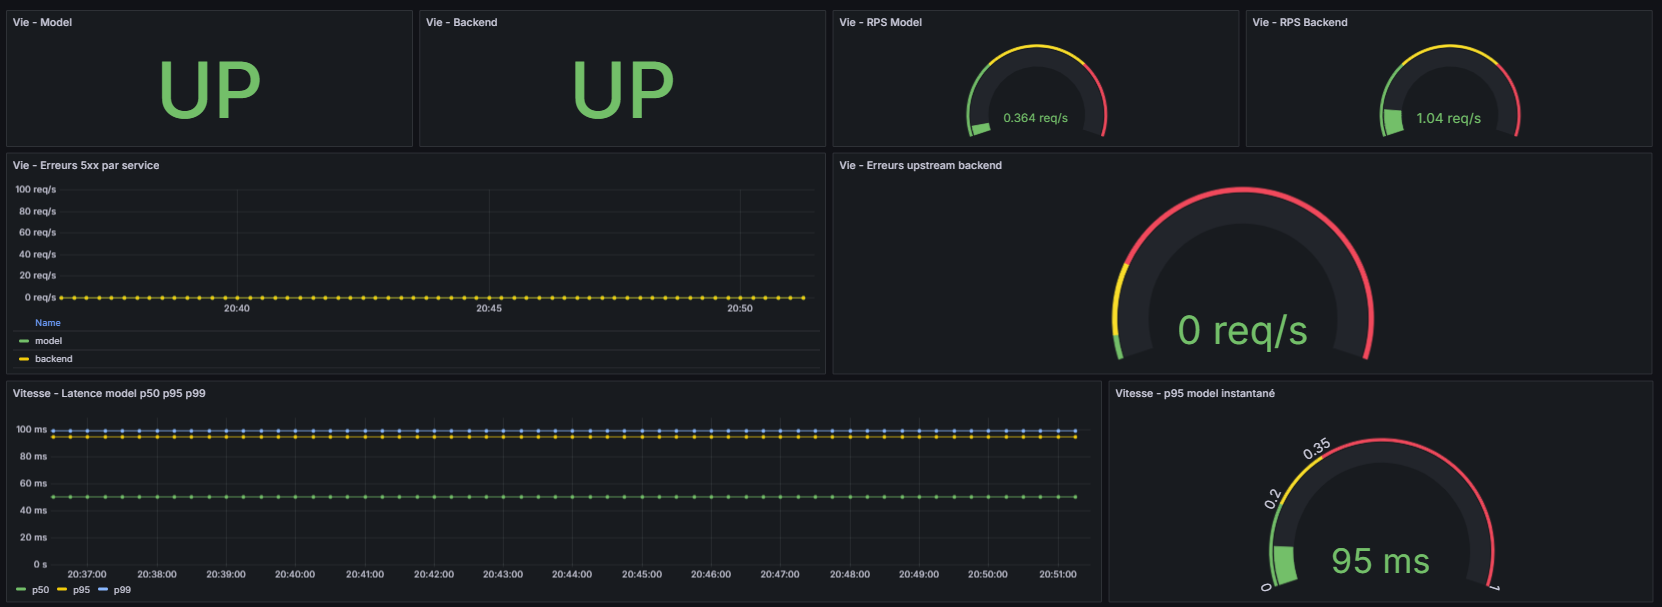

1. **Vie – Model / Backend** : `UP`  
   Prometheus parvient à joindre les endpoints de santé du modèle et du backend, ce qui confirme que les deux services sont opérationnels.

2. **Vie – RPS Model / Backend**  
   Nombre de requêtes HTTP par seconde observées :

   - **Modèle :** `0,364 req/s`
   - **Backend :** `1,04 req/s`

   Ces compteurs incluent les appels applicatifs mais également les requêtes de monitoring et de vérification d’état (health checks).

3. **Vie – Erreurs 5xx par service**  
   Mesure du taux d’erreurs serveur pour le modèle et le backend.

   - **Valeur observée :** `0 req/s`
   - **Interprétation :** aucune erreur HTTP 5xx n’a été détectée sur la période mesurée.

4. **Vie – Erreurs upstream backend**  
   Cet indicateur mesure les erreurs rencontrées lorsque le backend communique avec le modèle.

   - **Valeur observée :** `0 req/s`
   - **Interprétation :** aucun échec d’appel entre le backend et le modèle n’a été enregistré.

5. **Vitesse – Latence modèle (p50 / p95 / p99)**  
   Mesure des temps de réponse du modèle :

   - **p50 (médiane) :** `50 ms`
   - **p95 :** `95 ms`
   - **p99 :** `99 ms`

   Le percentile **p95 à 95 ms** signifie que 95 % des requêtes traitées ont obtenu une réponse en **95 ms ou moins**.

6. **Vitesse – p95 modèle instantané**  
   Indicateur du percentile p95 le plus récent.

   - **Valeur observée :** `95 ms`
   - **Statut :** dans la zone verte définie par le seuil de latence du tableau de bord, indiquant un niveau de performance satisfaisant.

**Gouvernance, Cycle de Vie & CI/CD (Model Lifecycle)**

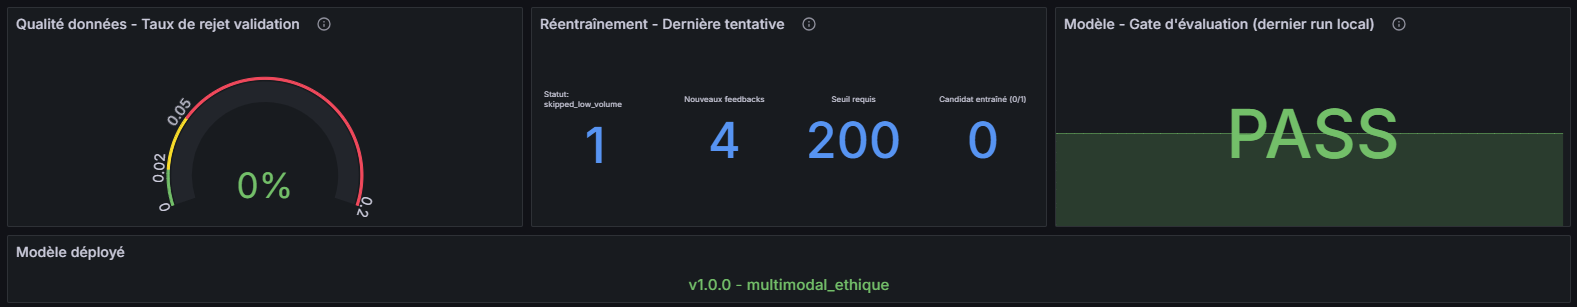

1. **Qualité des données – Taux de rejet de validation (à gauche)**  
   Le taux est de **0 %**, ce qui signifie que les requêtes entrantes respectent parfaitement le schéma attendu.

2. **Réentraînement – Dernière tentative (au centre)**  
   Ce panneau fournit un diagnostic détaillé du pipeline de réentraînement :

   - **Statut :** `skipped_low_volume`  
     Le réentraînement a été ignoré car le volume de données disponible n'est pas suffisant.

   - **Nouveaux feedbacks :** `4`  
     Seuls 4 nouveaux retours (labels) ont été collectés.

   - **Seuil requis :** `200`  
     Un minimum de 200 observations est nécessaire pour déclencher un réentraînement pertinent, afin d'éviter le surapprentissage sur un échantillon trop faible.

   - **Candidat entraîné :** `0/1`

3. **Modèle – Gate d'évaluation (à droite)**  
   Le statut affiché est **PASS** (en vert), indiquant que la dernière évaluation locale de la passerelle de validation s'est déroulée avec succès.

4. **Modèle déployé (en bas)**  
   La version actuellement déployée est :

   ```text
   v1.0.0 - multimodal_ethique


**Analyse des prédictions du modèle**
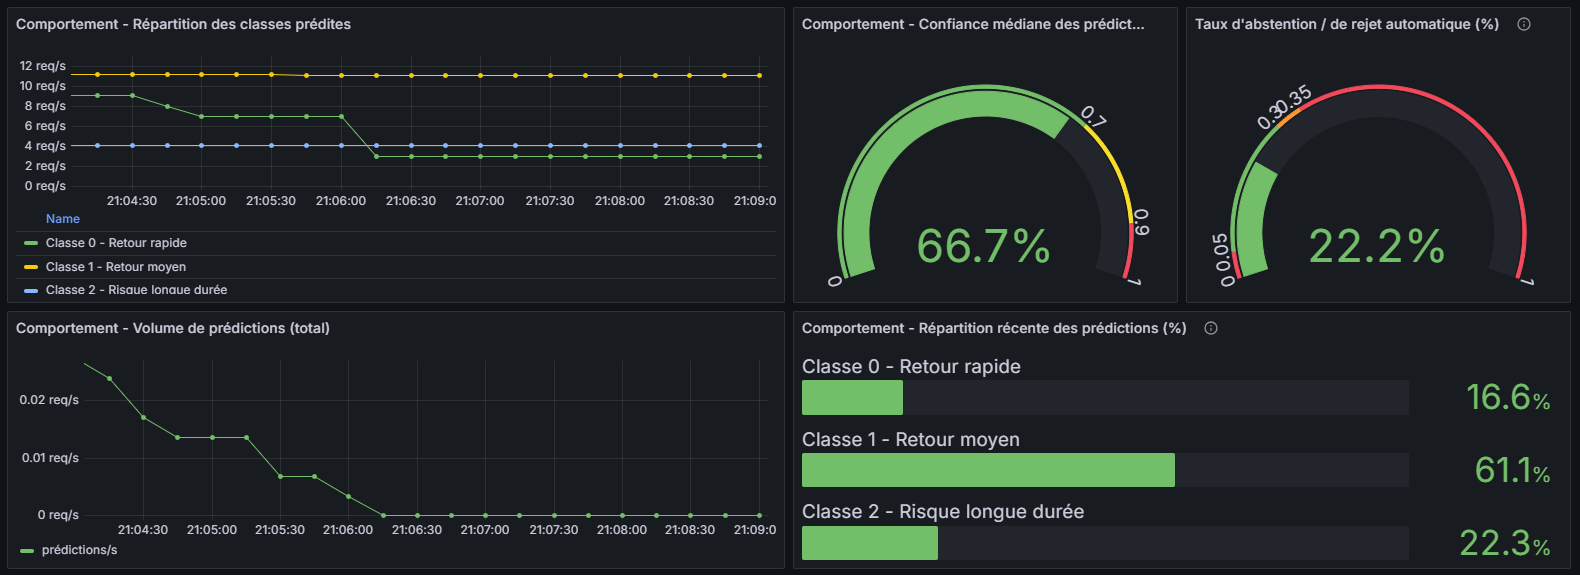
- **Répartition des classes prédites**  
  Sur la fenêtre observée, la **classe 1** (« Retour moyen ») est la plus représentée, suivie de la **classe 0** puis de la **classe 2**.

- **Confiance médiane** : `66,7 %`  
  Cette métrique correspond à la médiane de la probabilité associée à la classe retenue par le modèle. Elle ne doit pas être interprétée comme un taux de réussite ou de précision du modèle.

- **Taux d’abstention / de rejet automatique** : `22.2 %`   
  La valeur est sous le seuil d’alerte fixé à `35 %`.
  Cela signifie que, sur la période observée, 22.2 % des dossiers ont été redirigés vers une **revue humaine** plutôt que traités automatiquement par le modèle. 

- **Volume de prédictions**  
  Nombre de prédictions par seconde.

- **Écart à la baseline**  
  Elles représentent la **répartition récente des prédictions entre les différentes classes**.

**Analyse du drift des données et des prédictions**
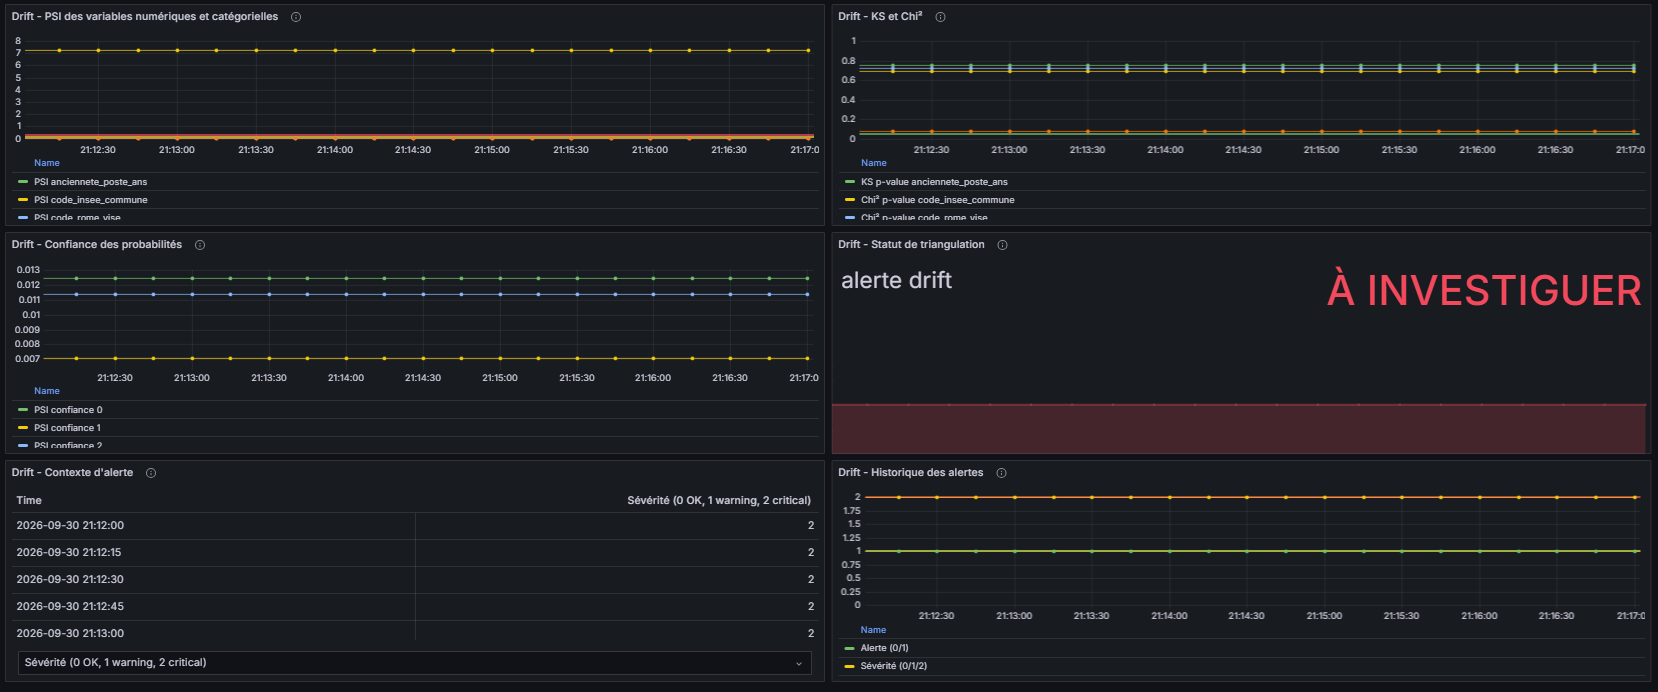

> Ces panneaux affichent le **dernier rapport de drift batch**. Ils comparent une fenêtre de référence à une fenêtre courante et ne recalculent pas le drift à chaque prédiction. Les courbes quasi horizontales correspondent simplement au même rapport Prometheus réexposé lors de plusieurs scrapes successifs.

**1. Drift – PSI des variables**

Le **PSI (Population Stability Index)** mesure l'ampleur du changement de distribution d'une variable.

**Repères d'interprétation :**
- `PSI < 0,10` : distribution stable
- `0,10 ≤ PSI < 0,25` : surveillance recommandée
- `PSI ≥ 0,25` : dérive très forte

**Valeurs observées :**

| Variable | PSI | Interprétation |
|-----------|------:|---------------|
| `code_insee_commune` | **7,26** | 🔴 Dérive très forte |
| `anciennete` | 0,020 | ✅ Stable |
| `code_rome` | 0,058 | ✅ Stable |
| `diplome` | 0,009 | ✅ Stable |

Le PSI de `code_insee_commune` est largement supérieur au seuil d'alerte de `0,25`, ce qui justifie une investigation approfondie.

**2. Drift – Tests KS et Chi²**

Ces tests statistiques évaluent si les distributions de référence et courantes sont significativement différentes.

**Seuil d'alerte :**
- `p-value < 0,05` → dérive statistiquement significative

**Résultats observés :**

| Test | Variable | p-value | Interprétation |
|--------|------------|---------:|---------------|
| KS | `anciennete` | 0,752 | ✅ Non significatif |
| Chi² | `diplome` | 0,082 | ✅ Non significatif |
| Chi² | `code_rome` | 0,728 | ✅ Non significatif |
| Chi² | `code_insee_commune` | 0,694 | ✅ Non significatif |

Aucune des p-values observées ne franchit le seuil de `0,05`. Les tests statistiques ne mettent donc pas en évidence de dérive significative.

**3. Drift – Confiance des probabilit**

Ce panneau mesure le PSI appliqué aux probabilités produites par le modèle pour chaque classe.

| Classe | PSI |
|----------|------:|
| Classe 0 | 0,012 |
| Classe 1 | 0,007 |
| Classe 2 | 0,011 |

L'ensemble des valeurs reste très faible (`< 0,10`), ce qui indique une **stabilité de la distribution des probabilités prédites**.

**4. Statut de triangulation**

- **Statut :** **À INVESTIGUER**
- **Sévérité :** `2`

Ce statut est déclenché par le PSI particulièrement élevé observé sur la variable `code_insee_commune`, dont la valeur dépasse largement le seuil d'alerte de `0,25`.

**5. Contexte et historique**

Les panneaux de contexte rappellent :

- le niveau de sévérité du dernier rapport ;
- l'état du dernier diagnostic de drift ;
- l'évolution apparente du rapport au fil des scrapes Prometheus.


### 9.2 Boucle de rétroaction

*[Comment les retours utilisateurs / annotations correctives reviennent dans les données d'entraînement ?]*

Après chaque prédiction, le conseiller peut renseigner le résultat réellement
observé. Le formulaire transmet au backend :

- le `request_id` ;
- la classe prédite ;
- l'étiquette réelle ;
- un commentaire optionnel.

Le backend vérifie que la prédiction existe et que la classe prédite
correspond à celle enregistrée. Le feedback est stocké dans SQLite :

- les doublons identiques sont traités de manière idempotente ;
- les feedbacks contradictoires sont refusés.

**Éligibilité des feedbacks**

Un feedback n'est utilisé (entraînement ou mesure) que s'il est **mûr** :

- **Maturité** : le résultat observé est renseigné après un délai minimal
  de N jours depuis la prédiction (à définir avec le métier, car le retour à
  l'emploi se mesure dans la durée).
- **Unicité** : les dossiers sont dédoublonnés par identifiant de dossier ou
  de personne, pas seulement par `request_id`, afin d'éviter toute fuite
  vers le jeu de référence gelé.
- **Couverture** : le taux de couverture (feedbacks ÷ prédictions) et la
  distribution des classes des feedbacks, comparée à celle des prédictions,
  sont suivis. Le renseignement étant facultatif, l'échantillon n'est pas
  supposé représentatif.

**Retour dans les données d'entraînement**

Les feedbacks éligibles et non consommés sont lus par `scripts/retrain.py`
et ajoutés à l'historique d'entraînement. Le jeu de référence gelé n'est
jamais utilisé pour l'apprentissage.

Deux états sont distingués :

- **consommé pour l'entraînement** : posé après la décision de promotion ou
  de rejet, pour ne pas réutiliser deux fois le même feedback à l'entraînement ;
- **disponible pour la mesure** : la table conserve tous les feedbacks. Les
  métriques de confirmation (erreur 2→0, concept drift, label shift) sont
  calculées sur des feedbacks **postérieurs à l'entraînement du modèle
  évalué**, ou absents de son jeu d'entraînement, pour éviter des résultats
  optimistes.

Limite connue : les conseillers peuvent être influencés par la prédiction du
modèle, ce qui peut contaminer partiellement les labels. Ce risque est
documenté ; un échantillon de contrôle peut être envisagé.

Le déclenchement, la validation du candidat et la promotion sont décrits en
section 9.3.

```mermaid
flowchart TD

    A[Demande de scoring] --> B[Backend]
    B --> C[Génération du request_id]
    C --> D[Prédiction du modèle]
    D --> E[(Table predictions)]

    E --> E1[Variables d'entrée]
    E --> E2[Classe prédite]
    E --> E3[Probabilités]
    E --> E4[Version du modèle]

    D --> F[Résultat affiché au conseiller]

    F --> G[Observation du résultat réel]
    G --> H[Saisie du feedback]

    H --> H1[Classe réelle 0 / 1 / 2]
    H --> H2[Commentaire optionnel]

    H --> I[POST /feedback]

    I --> J{Contrôles backend}

    J -->|request_id inconnu| K[404 Not Found]
    J -->|Conflit annotation ou prédiction| L[409 Conflict]
    J -->|Label invalide| M[422 Unprocessable Entity]

    J -->|Feedback valide| N[(Table feedbacks)]

    N --> N1[used_for_training = 0]

    N --> O[Service de retraining]

    E --> O

    O --> P[Jointure predictions + feedbacks]

    P --> Q[Filtrage des feedbacks non consommés]

    Q --> R{Seuil minimum atteint ?}

    R -->|Non| S[Attente de nouveaux feedbacks]

    R -->|Oui| T[Construction du dataset candidat]

    T --> U[Ajout des données annotées]

    U --> V[Entraînement du modèle candidat]

    V --> W[Validation et comparaison à la baseline]

    W --> X{Promotion ?}

    X -->|Non| Y[Run MLflow conservé]
    
    X -->|Oui| Z[Nouvelle version du modèle]

    Z --> AA[Mise à jour du manifeste]
    AA --> AB[Chargement du nouveau modèle]

    Z --> AC[Marquage des feedbacks utilisés]
    AC --> AD[used_for_training = 1]

    subgraph Référentiel de validation
        REF[Jeu indépendant]
    end

    REF -. Jamais utilisé pour l'entraînement .-> V

    subgraph Stockage persistant
        E
        N
    end

    subgraph Volume Docker
        VOL[feedback_data]
    end

    N --- VOL
```

### 9.3 Plan de réentraînement

*[Trigger (calendaire ? performance ? volume nouvelles données ?), automatisation, validation avant mise en prod.]*

**Déclenchement du workflow**

Le workflow GitHub Actions peut être exécuté :

- manuellement ;
- automatiquement toutes les **6 heures**.

Cette planification déclenche uniquement une **vérification des conditions de réentraînement** et non un entraînement systématique.

**Condition minimale de déclenchement**

Le processus de réentraînement exige un volume minimal de :

- **200 feedbacks validés et non consommés** (valeur par défaut).

Si ce seuil n'est pas atteint :

- aucun modèle candidat n'est entraîné ;
- le statut `skipped_low_volume` est enregistré ;
- les feedbacks sont conservés pour une exécution ultérieure.

> Les alertes de performance ou de drift ne déclenchent pas automatiquement un réentraînement. Elles servent uniquement à identifier des situations nécessitant une investigation.

**Entraînement d'un modèle candidat**

Lorsque le seuil de feedbacks est atteint :

1. Les nouveaux feedbacks sont ajoutés à l'historique d'entraînement.
2. Le jeu de référence gelé est exclu de l'apprentissage.
3. Un modèle candidat est entraîné.
4. Le candidat et le modèle actuellement en production sont évalués sur le même jeu de référence.
5. Les résultats sont comparés selon les critères de validation définis par la gate de release.

**Critères de promotion**

La promotion d'un modèle candidat n'est autorisée que si les conditions suivantes sont réunies :

- respect des seuils minimaux de qualité ;
- absence de régression supérieure aux tolérances définies ;
- amélioration du **F1 macro** ou du **recall de la classe 2**
  
Si l'un de ces critères n'est pas satisfait :

- le modèle candidat est rejeté ;
- le modèle actuellement en production reste inchangé.

**Traçabilité et auditabilité**

Chaque exécution enregistre :

- les métriques d'évaluation ;
- les artefacts générés ;
- les paramètres utilisés ;
- la décision de promotion ou de rejet.

Ces informations sont historisées dans :

- **MLflow** ;
- le **journal des décisions**.

**Déploiement et rollback**

Avant toute promotion :

1. Le modèle candidat et sa configuration sont sauvegardés.
2. La validation de la gate est exécutée.
3. Le déploiement est réalisé uniquement après validation complète.

En cas de problème après déploiement :

- une procédure de **rollback manuel** permet de revenir à la version précédemment validée.

### Synthèse du processus

```text
Workflow GitHub Actions (toutes les 6 h)
                 │
                 ▼
Vérification du nombre de feedbacks
                 │
        ┌────────┴────────┐
        │                 │
   < 200 feedbacks    ≥ 200 feedbacks
        │                 │
        ▼                 ▼
skipped_low_volume   Entraînement candidat
        │                 │
        │                 ▼
        │        Évaluation sur le jeu de référence
        │                 │
        │                 ▼
        │           Gate de validation
        │                 │
        │        ┌────────┴────────┐
        │        │                 │
        │     Échec            Succès
        │        │                 │
        ▼        ▼                 ▼
Conservation   Rejet du      Promotion du
des feedbacks  candidat      modèle candidat
             

### 9.4 Robustesse en exploitation

La robustesse en exploitation surveille les conditions de défaillance après la mise en production. Elle complète les stratégies de fallback conçues en §7.2 : §7.2 définit la décision et le parcours de revue ; cette section précise comment mesurer leur déclenchement et quand investiguer.

| Axe | Métrique opérationnelle | Seuil et action | État dans le projet |
|------|-------------------------|-----------------|---------------------|
| **OOD — entrée hors distribution** | Score OOD par dossier, par exemple Isolation Forest sur les variables tabulaires ; taux de dossiers signalés par fenêtre. Le PSI/KS batch suit les changements globaux, mais ne remplace pas un score OOD individuel. | Si le score dépasse un seuil calibré sur la référence, journaliser le `request_id` et le score, puis appliquer le fallback prévu en §7.2. Ne pas enregistrer le contenu brut du dossier dans les métriques. | **À implémenter** : aucun détecteur OOD individuel n’est branché à l’inférence. Le PSI/KS batch existe déjà. |
| **Drift du seuil de rejet** | Taux de revues humaines et part des prédictions sous le seuil de confiance, rapportés au nombre de dossiers scorés ; comparaison à une référence sur une fenêtre glissante de quatre semaines. | Si le taux s’écarte de plus de **20 % en relatif** de la référence et que le volume est suffisant, déclencher une alerte et faire revoir le seuil. Ne pas le modifier automatiquement. | **Partiel** : les règles de revue sont mesurées par `backend_abstentions_total` et le taux apparaît dans Grafana. La comparaison relative sur quatre semaines et son alerte restent à automatiser. |
| **Calibration** | Brier score et courbe de calibration par classe, calculés périodiquement sur des labels confirmés et suffisamment mûrs ; suivre également l’ECE. | Si la calibration se dégrade de façon persistante sur un échantillon suffisant, alerter et évaluer Platt ou isotonic sur un jeu de calibration distinct. Déployer le calibrateur seulement après validation ; ne pas réentraîner tout le modèle si seule la calibration dérive. | **Partiel** : `src/calibration.py` calcule une table de fiabilité et l’ECE binaire. Le Brier score et le suivi mensuel automatisé ne sont pas encore implémentés. |

Le fallback actuellement codé en §7.2 envoie un dossier en revue humaine si la confiance maximale est **inférieure à 0,55**, ou si la classe prédite est 0 avec `P(classe 2) ≥ 0,04`. Le backend compte ces revues ; toutefois, ces seuils ont été déterminés avec des probabilités calibrées alors que l’artefact actuellement servi est un pipeline non calibré. Leur pertinence opérationnelle doit donc être confirmée après calibration de l’artefact déployé.

Les panneaux Grafana rendent les signaux visibles. Les alertes Prometheus/Grafana et leur destinataire doivent être définis explicitement. Ne pas utiliser `request_id` ou un identifiant usager comme label Prometheus : les conserver, si nécessaire, dans les logs corrélés.

> **La chaîne conception → exploitation doit rester explicite** :
>
> - §7.2 définit le filet de sécurité et les mécanismes de fallback ;
> - §9.4 mesure leur utilisation et leur efficacité en production.
>
> Un fallback conçu mais jamais mesuré peut sembler disponible alors qu’il ne se déclenche pas. À l’inverse, un signal mesuré sans seuil, sans alerte ni responsable identifié ne déclenche aucune action opérationnelle.

### 9.5 📝 Synthèse amélioration continue

*[Cadence de surveillance, déclencheurs de réentraînement, plan de remédiation en cas de dérive.]*

**Cadence de surveillance**

| Couche | Fréquence | État |
|---|---|---|
| Supervision de service (disponibilité, erreurs HTTP, latence) | Scrape 5 s, dashboard 30 s | En place, alertes à configurer |
| Comportement du modèle (classes prédites, confiance, taux de revue humaine) | Temps réel, observation seule | En place |
| Dérive des entrées (PSI / KS / χ²) | Batch `scripts/drift_analysis.py` | Exécution quotidienne et notifications non configurées |
| Non-régression du modèle sur jeu gelé | À chaque exécution du workflow (6 h) | En place ; détecte une régression du modèle ou du code, pas une dérive de production |
| Performance sur labels confirmés (erreur 2→0, concept drift, label shift) | Mensuelle, fenêtre cumulée | À automatiser |

**Déclencheurs de réentraînement**

- **Périodique, guidé par le volume** : au moins 200 nouveaux feedbacks validés (détail en 9.3).
- **Hors calendrier, après investigation** : dégradation confirmée sur labels mûrs, avec effectif suffisant.
- Une alerte de drift seule ne déclenche jamais de réentraînement.

**Plan de remédiation**

| Situation | Action | Responsable |
|---|---|---|
| Dérive des entrées sans baisse de performance | Continuer la surveillance, documenter la cause | ML Platform |
| Dérive des entrées et performance en baisse | Investigation prioritaire, réentraînement envisagé | ML Platform + métier |
| Performance en baisse sans dérive (concept drift possible) | Investigation immédiate | ML Platform + métier |
| Incident de service | Runbook d'exploitation | SRE |
| Régression après promotion | Rollback manuel vers la version validée | ML Platform |

**Procédure d'investigation**

1. vérifier la période analysée ;
2. contrôler la qualité des données ;
3. vérifier la maturité et la couverture des feedbacks ;
4. examiner les performances (recall et précision classe 2, erreur 2→0) ;
5. contrôler la calibration ;
6. décider du réentraînement selon les critères ci-dessus.

**Améliorations restantes**

- exécution quotidienne du drift et notifications ;
- alertes automatiques (service, drift, performance) ;
- détecteur OOD individuel ;
- suivi de la calibration multiclasses ;
- suivi des erreurs métier à partir des feedbacks confirmés.

Seuils et escalade : voir §7.2.

---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*

### C. Décisions techniques détaillées

*[Justifications longues qu'on ne met pas dans le corps du notebook pour le garder lisible.]*

### D. Journal de bord

**Pendant la formation**, le journal de bord est tenu **séparément** dans `journal-de-bord.ipynb` (plus pratique pour le rythme journalier).

⚠️ **Pour la certification**, les deux fichiers doivent être **fusionnés en un seul notebook** (cf. fiche descriptive Atlas IA — un cahier électronique unique).

#### Méthode 1 — Script de fusion (recommandée, ~30 secondes)

Un script est fourni à la racine du repo formation : `scripts/merge_for_certif.py`.

```bash
python scripts/merge_for_certif.py mon_notebook.ipynb journal-de-bord.ipynb rendu_certif.ipynb
```

Le script localise automatiquement le titre « D. Journal de bord » dans le notebook principal et y insère les cellules du journal dans l'ordre. Il produit un nouveau fichier sans modifier les sources.

#### Méthode 2 — Fusion manuelle dans JupyterLab (~5 min)

1. Ouvrir les **deux notebooks** côte à côte dans JupyterLab (drag-and-drop dans deux colonnes).
2. Dans le journal : cliquer sur la première cellule « Jour 1 », puis **Maj-clic** sur la dernière pour tout sélectionner sauf l'intro.
3. **Edit > Copy Cells** (`Ctrl/Cmd + Shift + C`).
4. Dans le notebook principal : cliquer sous le titre « D. Journal de bord ».
5. **Edit > Paste Cells Below** (`Ctrl/Cmd + Shift + V`).
6. Vérifier l'ordre chronologique.
7. **Kernel > Restart & Run All** : aucune cellule ne doit casser.
8. Sauvegarder sous un **nouveau nom** (ex : `<prenom>_certif_v1.ipynb`) — ne pas écraser les sources.

#### Vérification finale (les deux méthodes)

- [ ] Le notebook fusionné s'exécute de bout en bout sans erreur.
- [ ] Toutes les images du journal s'affichent (sinon : passer en chemins absolus ou inliner).
- [ ] Aucune référence à des fichiers externes hors du repo (ou alors les inclure dans le ZIP de rendu).
- [ ] Une seule version finale, datée, dans le ZIP envoyé au jury.

⚠️ **Tester la fusion 2-3 jours avant le rendu**, pas le jour J.

#### Export PDF (optionnel, pour la soutenance)

```bash
jupyter nbconvert --to pdf rendu_certif.ipynb
```